In [348]:
import WOMqc

import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
from math import factorial, ceil
from scipy.special import factorial, erf
from datetime import datetime, timedelta

importlib.reload(WOMqc) 
WOMqc = WOMqc.WOMqc

### Compare uncoated to no WOM to coated WOM

In [349]:
WOM_uncoated = WOMqc.load("20260813_WOM_FreiburgXT2mm_uncoated")
WOM_uncoated_180 = WOMqc.load("20260813_WOM_FreiburgXT2mm_uncoated_180")
no_WOM_1 = WOMqc.load("20260807_wo_WOM")
no_WOM_2 = WOMqc.load("20260812_wo_WOM")
testbeam_WOM16 = WOMqc.load("20260813_testbeam_WOM_16_FreiburgXT2mm")

In [354]:
QC = [WOM_uncoated, WOM_uncoated_180, no_WOM_1, no_WOM_2, testbeam_WOM16]
for qc in QC:
    apply_sipm_corrections(qc)
    qc.calculate_eventwise_ratios()

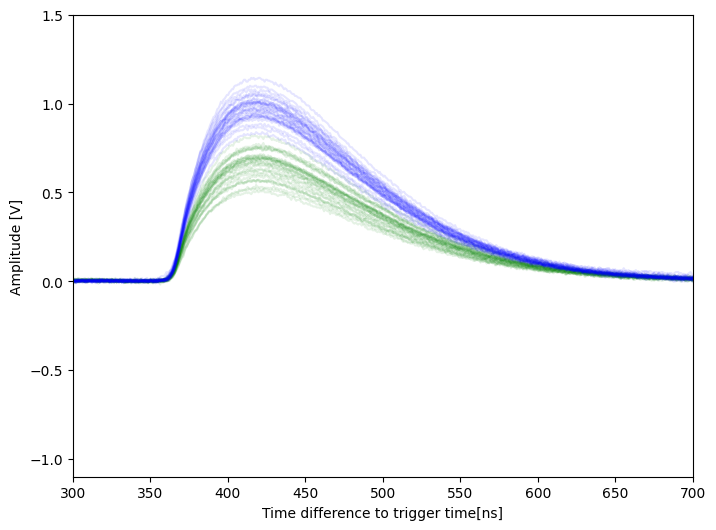

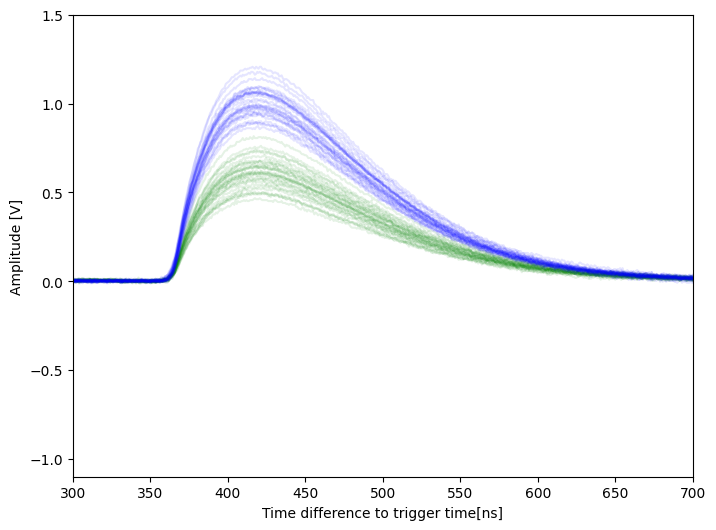

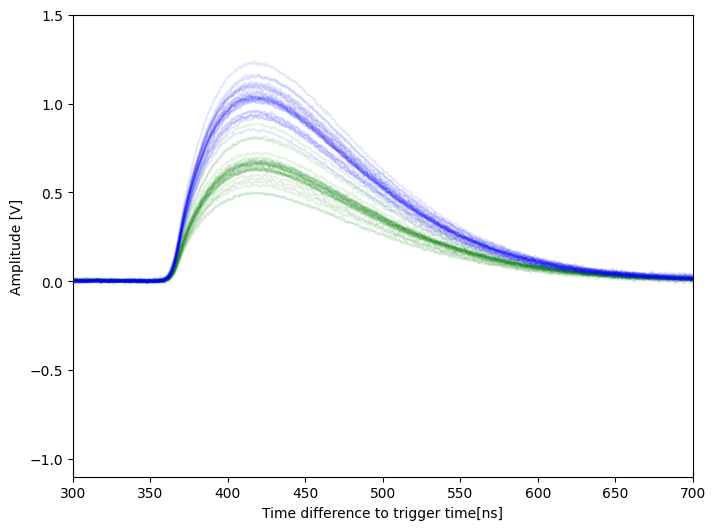

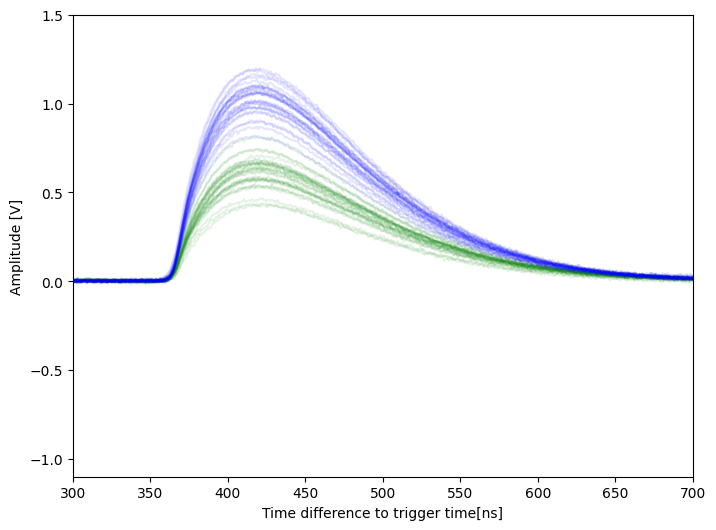

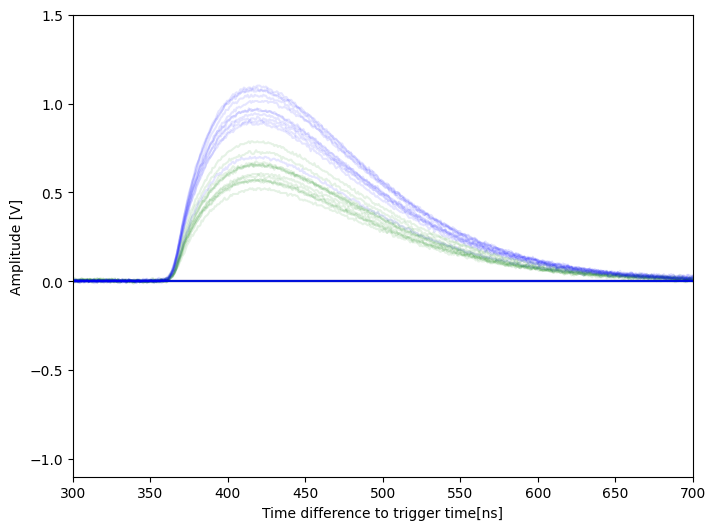

In [327]:
for qc in QC:
    qc.plot_waveforms_position(i = 999, j = 999, PM=["SiPMin_in", "SiPMout_in"], baseline_corrected = True, reps = 30, plot_mean = False, plot_integration_window = False, legend = False)

In [357]:
qc.baseline_integrated_data_eventwise["PMT_in_ref"]

array([[[611.8003531320069],
        [764.7615321113243],
        [805.7290914708844],
        ...,
        [nan],
        [nan],
        [1340.8857157263137]],

       [[2.1104993615719527e-09],
        [1.6257734109466695e-09],
        [1.4414661419105032e-09],
        ...,
        [1.6926629195460817e-09],
        [1.7276179974351454e-09],
        [1.3418759035050228e-09]],

       [[4.0016141291310375e-09],
        [3.6004201162552988e-09],
        [3.1060599562478804e-09],
        ...,
        [3.876121230976494e-09],
        [3.5965294423293205e-09],
        [4.627389419362675e-09]],

       ...,

       [[4.0383631025013076e-09],
        [5.0014040134871536e-09],
        [4.152019059766917e-09],
        ...,
        [4.464311843388495e-09],
        [4.758983120225854e-09],
        [3.5590324809755575e-09]],

       [[3.9880506835215815e-09],
        [3.216032290544314e-09],
        [4.02686190837114e-09],
        ...,
        [6.179137066566097e-09],
        [3.511802070641806e-

In [358]:
# Define headers for 9 metrics
columns = [
    "Temperature",
    "Gain",
    "Meas Above Transmission",
    "Meas Above Reference",
    "PMT",
    "Transmission",
    "Reference",
    "Norm PMT",
    "Norm Transmission",
]

QC = [WOM_uncoated, WOM_uncoated_180, no_WOM_1, no_WOM_2, testbeam_WOM16]
QClabels = ["WOM_uncoated", "WOM_uncoated_180", "no_WOM_1", "no_WOM_2", "testbeam_WOM16"]

# Initialize DataFrames
df_inner = pd.DataFrame(index=QClabels, columns=columns, dtype=np.float64)
df_outer = pd.DataFrame(index=QClabels, columns=columns, dtype=np.float64)

# Helper function to convert data slice to array, ignore 0/NaNs, and calculate mean
def get_mean(data_slice):
    arr = np.array(data_slice, dtype=float)
    return arr[arr!=0].mean()

# Populate both Inner and Outer DataFrames
for qc, label in zip(QC, QClabels):
    base_data = qc.baseline_integrated_data
    event_data = qc.baseline_integrated_data_eventwise

    # --- Inner LED ---
    df_inner.loc[label] = [
        get_mean(base_data["temp_in"]),
        get_mean(base_data["gain_in"]),
        get_mean(event_data["SiPMout_in"][0]),
        get_mean(event_data["SiPMin_in"][0]),
        get_mean(event_data["PMT_in"][1:]),
        get_mean(event_data["SiPMout_in"][1:]),
        get_mean(event_data["SiPMin_in"][1:]),
        get_mean(event_data["PMT_in_ref"][1:]),
        get_mean(event_data["SiPMout_in_gain_ref"][1:]),
    ]

    # --- Outer LED ---
    df_outer.loc[label] = [
        get_mean(base_data["temp_out"]),
        get_mean(base_data["gain_out"]),
        get_mean(event_data["SiPMin_out"][0]),
        get_mean(event_data["SiPMout_out"][0]),
        get_mean(event_data["PMT_out"][1:]),
        get_mean(event_data["SiPMout_out"][1:]),
        get_mean(event_data["SiPMin_out"][1:]),
        get_mean(event_data["PMT_out_ref"][1:]),
        get_mean(event_data["SiPMin_out_gain_ref"][1:]),
    ]

# Display or copy Markdown output directly
print("### Inner LED Data\n", df_inner.to_markdown())
print("\n### Outer LED Data\n", df_outer.to_markdown())

### Inner LED Data
 |                  |   Temperature |        Gain |   Meas Above Transmission |   Meas Above Reference |         PMT |   Transmission |   Reference |    Norm PMT |   Norm Transmission |
|:-----------------|--------------:|------------:|--------------------------:|-----------------------:|------------:|---------------:|------------:|------------:|--------------------:|
| WOM_uncoated     |       33.8271 | 1.29562e+06 |               1.29554e-07 |            8.87329e-08 | 1.68793e-10 |    1.41886e-07 | 8.7307e-08  | 1.75087e-10 |            1.1452   |
| WOM_uncoated_180 |       34.0111 | 1.29077e+06 |               1.33681e-07 |            8.2757e-08  | 1.65725e-10 |    1.41295e-07 | 8.65901e-08 | 1.61654e-10 |            1.04035  |
| no_WOM_1         |       36.5669 | 1.22334e+06 |               1.36167e-07 |            8.74748e-08 | 2.69551e-10 |    1.31467e-07 | 8.86364e-08 | 2.71715e-10 |            0.967843 |
| no_WOM_2         |       34.5013 | 1.27783e+06 |     

### Inner LED Data
 |                  |   Temperature |        Gain |   Meas Above Transmission |   Meas Above Reference |         PMT |   Transmission |   Reference |   Norm PMT |   Norm Transmission |
|:-----------------|--------------:|------------:|--------------------------:|-----------------------:|------------:|---------------:|------------:|-----------:|--------------------:|
| WOM_uncoated     |       33.8271 | 1.29562e+06 |               1.29554e-07 |            8.87329e-08 | 1.68793e-10 |    1.41886e-07 | 8.7307e-08  | 0.00197118 |            1.65244  |
| WOM_uncoated_180 |       34.0111 | 1.29077e+06 |               1.33681e-07 |            8.2757e-08  | 1.65725e-10 |    1.41295e-07 | 8.65901e-08 | 0.00195393 |            1.66025  |
| no_WOM_1         |       36.5669 | 1.22334e+06 |               1.36167e-07 |            8.74748e-08 | 2.69551e-10 |    1.31467e-07 | 8.86364e-08 | 0.00310206 |            1.50666  |
| no_WOM_2         |       34.5013 | 1.27783e+06 |               1.36246e-07 |            8.27268e-08 | 2.33707e-10 |    1.34035e-07 | 8.69152e-08 | 0.00274467 |            1.56835  |
| testbeam_WOM16   |       34.1234 | 1.28781e+06 |               1.28092e-07 |            8.4694e-08  | 3.63157e-09 |    8.00245e-08 | 8.29229e-08 | 0.0445943  |            0.982873 |

### Outer LED Data
 |                  |   Temperature |        Gain |   Meas Above Transmission |   Meas Above Reference |         PMT |   Transmission |   Reference |   Norm PMT |   Norm Transmission |
|:-----------------|--------------:|------------:|--------------------------:|-----------------------:|------------:|---------------:|------------:|-----------:|--------------------:|
| WOM_uncoated     |       34.766  | 1.27085e+06 |               9.75414e-08 |            7.46686e-08 | 1.3936e-10  |    7.33951e-08 | 1.03284e-07 | 0.00193933 |             1.43814 |
| WOM_uncoated_180 |       34.9739 | 1.26537e+06 |               1.02324e-07 |            6.93619e-08 | 1.38295e-10 |    7.34027e-08 | 1.03437e-07 | 0.00192308 |             1.44063 |
| no_WOM_1         |       37.0656 | 1.21018e+06 |               1.0375e-07  |            7.72921e-08 | 2.71728e-10 |    7.80068e-08 | 1.06218e-07 | 0.00354953 |             1.38827 |
| no_WOM_2         |       34.9392 | 1.26628e+06 |               1.06204e-07 |            7.57006e-08 | 2.36663e-10 |    7.52634e-08 | 1.04605e-07 | 0.00321562 |             1.41987 |
| testbeam_WOM16   |       34.9917 | 1.2649e+06  |               9.87135e-08 |            7.18869e-08 | 2.82241e-09 |    7.17993e-08 | 5.83419e-08 | 0.0402274  |             0.83119 |

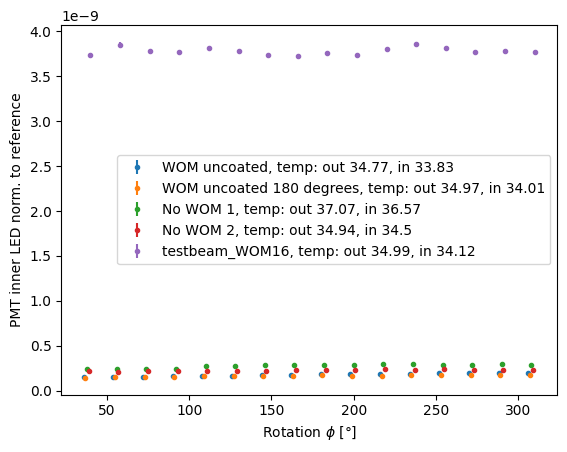

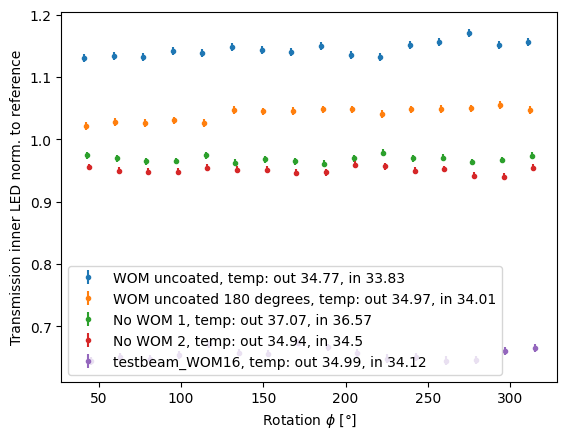

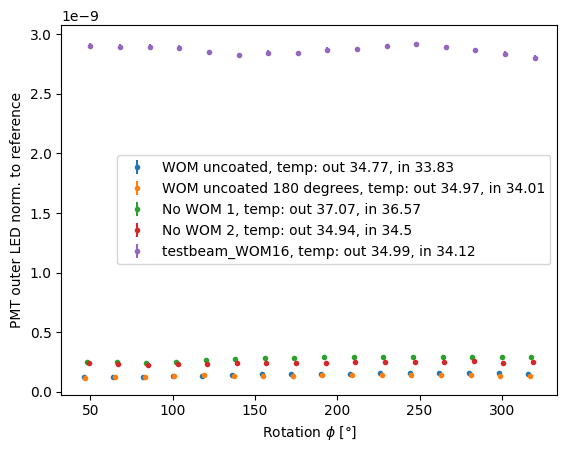

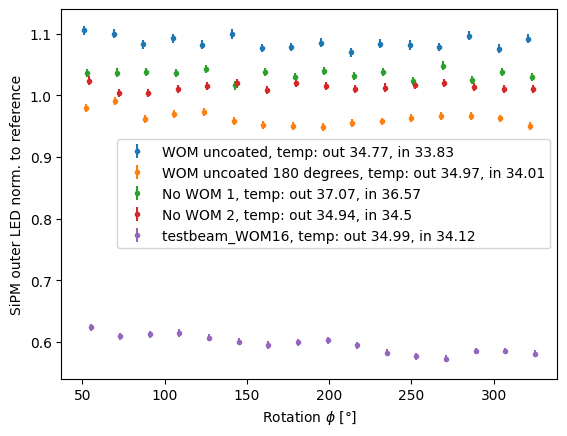

In [282]:
#QC = [qc11_wo1, qc11_wo2, qc11_wo3]#[qc11, qc11_2, qc11_3, qc11_wo, qc6, qc16, qc16_2, qc7, qc7_2, qc7_3]#,qc0, qc90, qc180, qc270]# qcthin]#, qc1, qc2, qc3] qc11, qc11_2, WOM 11", "WOM 11 2", 
QC = [WOM_uncoated, WOM_uncoated_180, no_WOM_1, no_WOM_2, testbeam_WOM16]
labels = ["WOM uncoated", "WOM uncoated 180 degrees", "No WOM 1", "No WOM 2", "testbeam_WOM16"]#["WOM11 without optical coupling","WOM11 without optical coupling 2", "WOM11 without optical coupling 3"]#["WOM 11 0degrees", "WOM 11 90degrees", "WOM 11 180degrees","WOM 11 270degrees"]#["WOM11", "WOM11 2", "WOM11 3", "WOM11 wo optical coupling", "WOM 6", "WOM 16","WOM 16 2", "WOM 7" ,"WOM 7 2","WOM 7 3", "WOM thin coating", "Bleached WOM 1", "Bleached WOM 2", "Bleached WOM 3"]
PM_ref = ["PMT_in_ref", "SiPMout_in_ref", "PMT_out_ref", "SiPMin_out_ref"]#["PMT_in", "SiPMout_in", "SiPMin_in", "PMT_out", "SiPMin_out", "SiPMout_out"]#
YLABELS = ["PMT inner LED norm. to reference", "Transmission inner LED norm. to reference", "PMT outer LED norm. to reference", "SiPM outer LED norm. to reference"]
#YLABELS = ["PMT inner LED", "Transmission inner LED", "Reference inner LED", "PMT outer LED", "Transmission outer LED", "Reference outer LED"]
#colors = ["green", "red", "blue", "orange"]  #"darkgreen", "green", "pink",darkblue", "orange", "darkorange", "brown"]
#marks = [".", "v", "*", ".", ".", ".", "v", ".", "v", "*"]

a = 0

group_col="j"

for ylabel, pm in zip(YLABELS, PM_ref):
    for qc in QC:
        x, groups, mean, std, err = qc.grouped_mean_std(
            value_col=pm,
            group_col=group_col,
        )
        plt.errorbar(x[2:-3]+a, mean[2:-3], yerr=err[2:-3], fmt = ".", label=f"{labels[QC.index(qc)]}, temp: out {round(np.mean(qc.integrated_data["temp_out"]), 2)}, in {round(np.mean(qc.integrated_data["temp_in"]), 2)}")#, fmt= marks[QC.index(qc)], color = colors[QC.index(qc)],label=f"{labels[QC.index(qc)]}, {np.mean(qc.integrated_data["temp_out"])}")
        a += 1
    plt.legend() 
    if group_col == "i":
        plt.xlabel("Distance LED to PMT (mm)")
    else:        
        plt.xlabel(r"Rotation $\phi$ [°]")
    plt.ylabel(f"{ylabel}")# normalized to reference [a.u.]
    
    plt.show()

### Quick check if a scan on a WOM would work in theory with this class (in dry-run-mode)

In [ ]:
qc_wo_WOM = WOMqc.load("20260807_wo_WOM")


Baseline data not found. Generating...


In [15]:
qc_wo_WOM.baseline_integrated_data

,i,j,time,temp_in,temp_out,PMT_in,PMT_in_std,SiPMin_in,SiPMin_in_std,SiPMout_in,...,SiPMout_out,SiPMout_out_std,PMT_in_ref,PMT_in_ref_std,SiPMout_in_ref,SiPMout_in_ref_std,PMT_out_ref,PMT_out_ref_std,SiPMin_out_ref,SiPMin_out_ref_std
0,999,999,12:44:06,36.63,37.13,8.787942e-12,1.454168e-11,8.747480e-08,1.070628e-08,1.361674e-07,...,7.729212e-08,9.382491e-09,0.000101,0.000170,1.577896,0.215925,0.000072,0.000172,1.363348,0.239184
1,0,0,12:44:16,36.63,37.13,3.759399e-11,2.675720e-11,8.930437e-08,7.535607e-09,1.334066e-07,...,7.772487e-08,1.203377e-08,0.000420,0.000298,1.503339,0.185406,0.000453,0.000484,1.399193,0.326171
2,1,0,12:44:25,36.63,37.13,3.223336e-11,2.532328e-11,8.606962e-08,1.305809e-08,1.300000e-07,...,7.669632e-08,8.906700e-09,0.000367,0.000290,1.538835,0.257400,0.000524,0.000272,1.346002,0.229287
3,2,0,12:44:34,36.50,37.13,4.257240e-11,3.341310e-11,8.963603e-08,9.646509e-09,1.325100e-07,...,7.572905e-08,1.045575e-08,0.000483,0.000381,1.493704,0.185552,0.000530,0.000302,1.394444,0.271703
4,3,0,12:44:43,36.63,37.13,4.214495e-11,2.893732e-11,9.041061e-08,1.118281e-08,1.301149e-07,...,7.311807e-08,9.284357e-09,0.000473,0.000320,1.460844,0.206891,0.000589,0.000351,1.467307,0.212262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
516,21,19,14:04:13,36.88,37.38,4.982602e-10,9.955472e-11,8.855180e-08,1.278994e-08,1.307490e-07,...,8.086327e-08,1.270883e-08,0.005702,0.001202,1.506938,0.232333,0.006402,0.001790,1.410762,0.337817
517,22,19,14:04:22,36.88,37.38,5.396686e-10,8.101450e-11,8.995656e-08,1.459145e-08,1.319889e-07,...,7.985659e-08,8.165717e-09,0.006135,0.001188,1.512229,0.322100,0.007306,0.001245,1.341499,0.168899
518,23,19,14:04:31,37.00,37.38,5.833925e-10,8.143532e-11,8.758145e-08,8.466307e-09,1.303374e-07,...,7.993358e-08,1.221329e-08,0.006686,0.000871,1.501673,0.188619,0.008627,0.001738,1.384983,0.273236
519,24,19,14:04:40,37.00,37.38,6.214335e-10,6.630932e-11,8.905054e-08,9.914696e-09,1.312299e-07,...,7.640783e-08,9.658727e-09,0.007087,0.001195,1.494280,0.245354,0.010269,0.001967,1.429787,0.217967


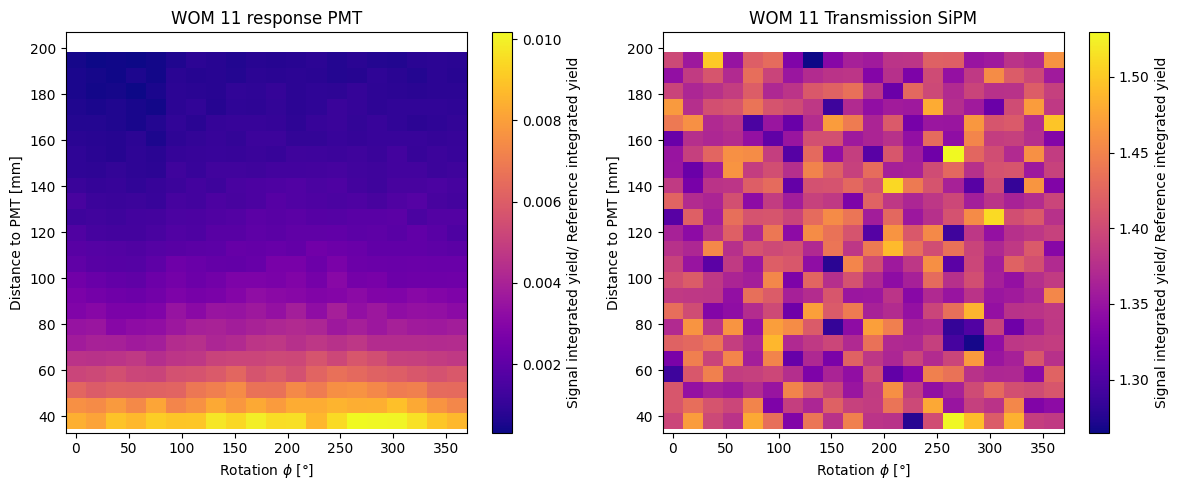

0

In [16]:
qc_wo_WOM.heatmap_WOM(ch1="PMT_out_ref", ch2="SiPMin_out_ref", baseline_subtract = True, remove_rows = [0,2], normalize = False, title = ["WOM 11 response PMT", "WOM 11 Transmission SiPM"], colorlabel = ["Signal integrated yield/ Reference integrated yield", "Signal integrated yield/ Reference integrated yield"]) #no rows removed

Check how the operation temperature depends on the room temperature

temp_in  = (1.0603 ± 0.0186) * T_room + (6.16 ± 0.49)
temp_out = (1.0898 ± 0.0186) * T_room + (5.76 ± 0.49)
temp_in after = (0.9190 ± 0.0188) * T_room + (10.07 ± 0.50)
temp_out after = (0.9117 ± 0.0188) * T_room + (11.33 ± 0.50)


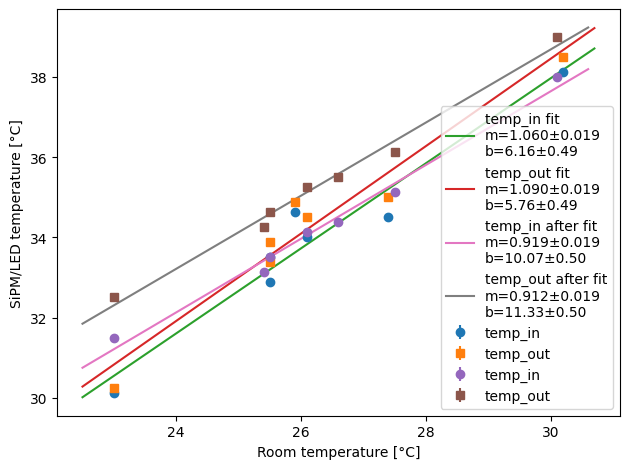

In [19]:
temp_in_after = np.array([ 38.0,  35.13,  34.13,
                     31.5,  34.38,  33.5,
                     33.13])

temp_in_before = np.array([38.13,  34.5, 34.63, 
                    30.12, 34.0,  33.5, 
                    32.88])


temp_out_after = np.array([ 39.0,  36.13,  35.25,
                      32.5,  35.5, 34.63,
                      34.25])

temp_out_before = np.array([38.5,  35.0, 34.88, 
                     30.25,  34.5,  33.88, 
                     33.38])                     

temp_room_after = np.array([ 30.1, 27.5, 26.1,
                       23.0,  26.6, 25.5,
                      25.4])

temp_room_before = np.array([30.2,  27.4,  25.9, 
                      23.0,  26.1,  25.5,
                      25.5])

sigma = np.full_like(temp_room_before, 0.1)

def linear(x, m, b):
    return m*x + b

# Fit temp_in
popt_in_b, pcov_in_b = curve_fit(
    linear, temp_room_before, temp_in_before,
    sigma=sigma, absolute_sigma=True
)
m_in_b, b_in_b = popt_in_b
dm_in_b, db_in_b = np.sqrt(np.diag(pcov_in_b))

# Fit temp_out
popt_out_b, pcov_out_b = curve_fit(
    linear, temp_room_before, temp_out_before,
    sigma=sigma, absolute_sigma=True
)
m_out_b, b_out_b = popt_out_b
dm_out_b, db_out_b = np.sqrt(np.diag(pcov_out_b))

print(f"temp_in  = ({m_in_b:.4f} ± {dm_in_b:.4f}) * T_room + ({b_in_b:.2f} ± {db_in_b:.2f})")
print(f"temp_out = ({m_out_b:.4f} ± {dm_out_b:.4f}) * T_room + ({b_out_b:.2f} ± {db_out_b:.2f})")

# Plot
xfit = np.linspace(temp_room_before.min()-0.5, temp_room_before.max()+0.5, 200)

plt.errorbar(temp_room_before, temp_in_before, yerr=0.1, fmt='o', label='temp_in')
plt.errorbar(temp_room_before, temp_out_before, yerr=0.1, fmt='s', label='temp_out')

plt.plot(xfit, linear(xfit, *popt_in_b),
         label=f"temp_in fit\nm={m_in_b:.3f}±{dm_in_b:.3f}\nb={b_in_b:.2f}±{db_in_b :.2f}")

plt.plot(xfit, linear(xfit, *popt_out_b),
         label=f"temp_out fit\nm={m_out_b:.3f}±{dm_out_b:.3f}\nb={b_out_b:.2f}±{db_out_b:.2f}")

# Fit temp_in
popt_in_a, pcov_in_a = curve_fit(
    linear, temp_room_after, temp_in_after,
    sigma=sigma, absolute_sigma=True
)
m_in_a, b_in_a = popt_in_a
dm_in_a, db_in_a = np.sqrt(np.diag(pcov_in_a))

# Fit temp_out
popt_out_a, pcov_out_a = curve_fit(
    linear, temp_room_after, temp_out_after,
    sigma=sigma, absolute_sigma=True
)
m_out_a, b_out_a = popt_out_a
dm_out_a, db_out_a = np.sqrt(np.diag(pcov_out_a))

print(f"temp_in after = ({m_in_a:.4f} ± {dm_in_a:.4f}) * T_room + ({b_in_a:.2f} ± {db_in_a:.2f})")
print(f"temp_out after = ({m_out_a:.4f} ± {dm_out_a:.4f}) * T_room + ({b_out_a:.2f} ± {db_out_a:.2f})")

# Plot
xfit = np.linspace(temp_room_after.min()-0.5, temp_room_after.max()+0.5, 200)

plt.errorbar(temp_room_after, temp_in_after, yerr=0.1, fmt='o', label='temp_in')
plt.errorbar(temp_room_after, temp_out_after, yerr=0.1, fmt='s', label='temp_out')

plt.plot(xfit, linear(xfit, *popt_in_a),
         label=f"temp_in after fit\nm={m_in_a:.3f}±{dm_in_a:.3f}\nb={b_in_a:.2f}±{db_in_a:.2f}")

plt.plot(xfit, linear(xfit, *popt_out_a),
         label=f"temp_out after fit\nm={m_out_a:.3f}±{dm_out_a:.3f}\nb={b_out_a:.2f}±{db_out_a:.2f}")

plt.xlabel("Room temperature [°C]")
plt.ylabel("SiPM/LED temperature [°C]")
plt.legend()
plt.tight_layout()
plt.show()

Text(0, 0.5, 'SiPM/LED temperature [°C]')

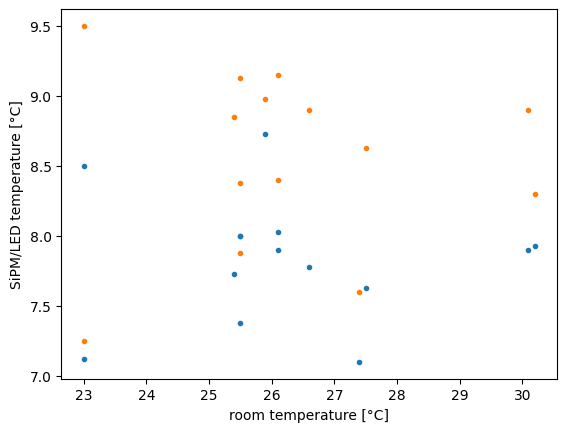

In [21]:
temp_in = np.array([38.13, 38.0, 34.5, 35.13, 34.63, 34.13, 30.12, 31.5, 34.0, 34.38, 33.5, 33.5, 32.88, 33.13])
temp_out = np.array([38.5, 39.0, 35.0, 36.13, 34.88, 35.25, 30.25, 32.5, 34.5, 35.5, 33.88, 34.63, 33.38, 34.25])
temp_room = np.array([30.2, 30.1, 27.4, 27.5, 25.9, 26.1, 23.0, 23.0, 26.1, 26.6, 25.5, 25.5, 25.5, 25.4])
plt.plot(temp_room, temp_in-temp_room,".", label = "temp_in")
plt.plot(temp_room, temp_out-temp_room,".", label = "temp_out")
plt.xlabel("room temperature [°C]")
plt.ylabel("SiPM/LED temperature [°C]")

### Load data

In [41]:
qc11_wo1 = WOMqc.load("20260610_testbeam_WOM_11_6_55mm_3_new_cover_wo_coupling_new")
qc11_wo2 = WOMqc.load("20260625_testbeam_WOM_11_6_55mm_new_cover_wo_coupling")
qc11_wo3 = WOMqc.load("20260629_testbeam_WOM_11_6_55mm_new_cover_wo_coupling_2")

In [44]:
qc11_wo1.calculate_eventwise_ratios()
qc11_wo2.calculate_eventwise_ratios()
qc11_wo3.calculate_eventwise_ratios()


In [42]:
qc11_wo1.integrated_data["gain_out"], qc11_wo1.integrated_data["dgain_out"] = gain(qc11_wo1.integrated_data["temp_out"])
qc11_wo1.integrated_data["gain_in"], qc11_wo1.integrated_data["dgain_in"] = gain(qc11_wo1.integrated_data["temp_in"])
qc11_wo2.integrated_data["gain_out"], qc11_wo2.integrated_data["dgain_out"] = gain(qc11_wo2.integrated_data["temp_out"])
qc11_wo2.integrated_data["gain_in"], qc11_wo2.integrated_data["dgain_in"] = gain(qc11_wo2.integrated_data["temp_in"])
qc11_wo3.integrated_data["gain_out"], qc11_wo3.integrated_data["dgain_out"] = gain(qc11_wo3.integrated_data["temp_out"])
qc11_wo3.integrated_data["gain_in"], qc11_wo3.integrated_data["dgain_in"] = gain(qc11_wo3.integrated_data["temp_in"])

In [77]:
PM = ["SiPMout_in", "SiPMin_in", "SiPMout_out", "SiPMin_out"]
Gain = ["gain_out", "gain_in", "gain_out", "gain_in"]
QC = [qc11_wo1, qc11_wo2, qc11_wo3]
for qc in QC:
    for pm, gain in zip(PM, Gain):      
        qc.integrated_data[f"{pm}_gain"] = qc.integrated_data[pm] / qc.integrated_data[gain]


In [86]:
PM = ["PMT_in", "SiPMout_in_gain", "PMT_out", "SiPMin_out_gain"]
REF = ["SiPMin_in_gain", "SiPMin_in_gain", "SiPMout_out_gain", "SiPMout_out_gain"]
QC = [qc11_wo1, qc11_wo2, qc11_wo3]
for qc in QC:
    for pm, ref in zip(PM, REF):  
        print(ref, np.mean(np.array(qc.integrated_data[f"{ref}"])))    
        qc.integrated_data[f"{pm}_ref"] = qc.integrated_data[pm] / qc.integrated_data[ref]

SiPMin_in_gain 1.082117138331985e-13
SiPMin_in_gain 1.082117138331985e-13
SiPMout_out_gain 1.2125930180669305e-13
SiPMout_out_gain 1.2125930180669305e-13
SiPMin_in_gain 1.0571928690372043e-13
SiPMin_in_gain 1.0571928690372043e-13
SiPMout_out_gain 1.1928844610696505e-13
SiPMout_out_gain 1.1928844610696505e-13
SiPMin_in_gain 9.452172279569903e-14
SiPMin_in_gain 9.452172279569903e-14
SiPMout_out_gain 1.0977064568823652e-13
SiPMout_out_gain 1.0977064568823652e-13


In [94]:
PM_ref = ["SiPMin_out_gain_ref", "PMT_out_ref", "SiPMout_in_gain_ref", "PMT_in_ref"]

for pm in PM_ref:
    for qc in QC:
        print(pm, np.mean(np.array(qc.integrated_data[f"{pm}"])))
        #qc.heatmap_WOM(ch1=f"{pm}", baseline_subtract = False, normalize = False, remove_rows = [1,2], vmin = [0.6], vmax = [0.78])#, normalize = False, title = [f"WOM 11 response {pm}"], colorlabel = ["Signal integrated yield/ Reference integrated yield"]) #no rows removed

SiPMin_out_gain_ref 0.7191655145748677
SiPMin_out_gain_ref 0.7289999549596838
SiPMin_out_gain_ref 0.7248757413504093
PMT_out_ref 159737.43182812643
PMT_out_ref 161096.99867262007
PMT_out_ref 180737.56328739072
SiPMout_in_gain_ref 1.044998136883668
SiPMout_in_gain_ref 1.045103104780226
SiPMout_in_gain_ref 1.1147709860367863
PMT_in_ref 198931.8411650171
PMT_in_ref 200011.72282601416
PMT_in_ref 234587.14090109497


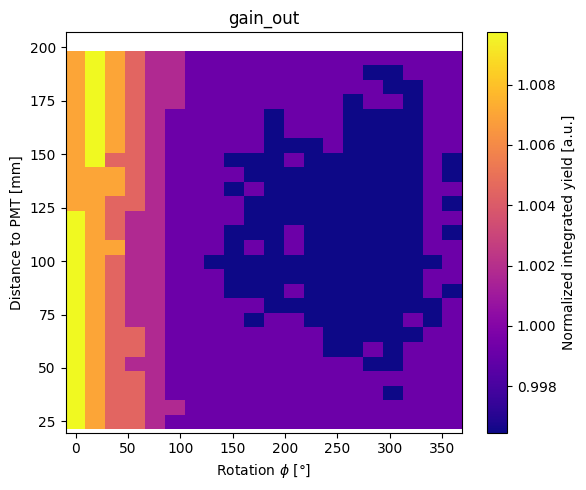

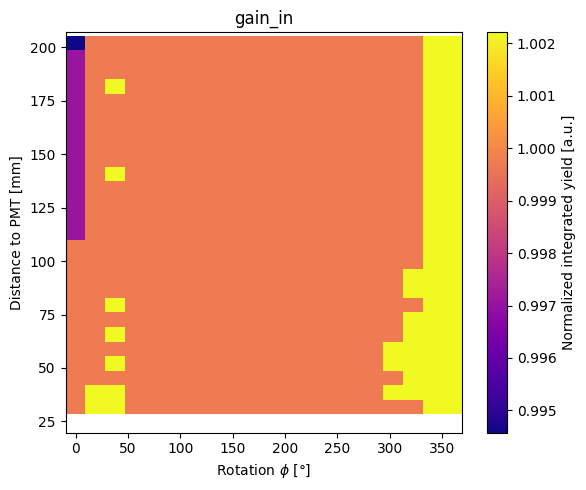

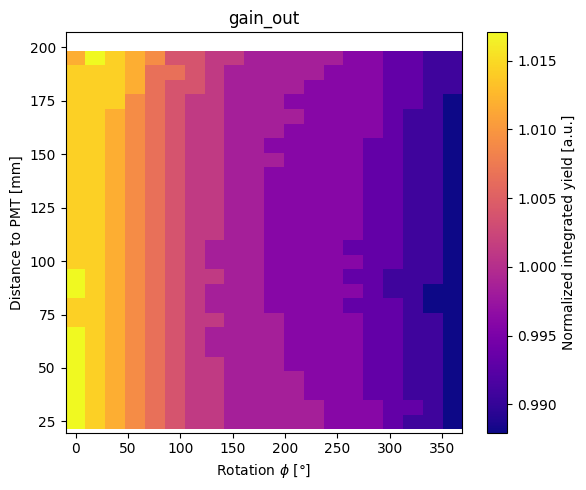

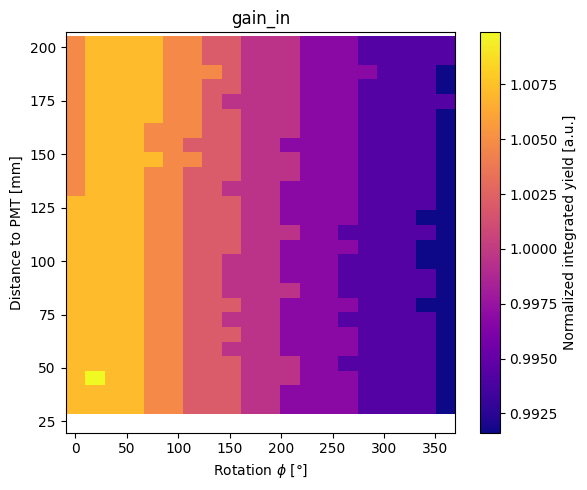

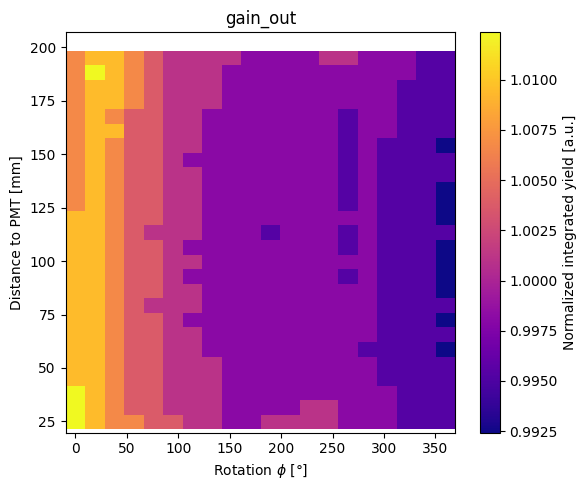

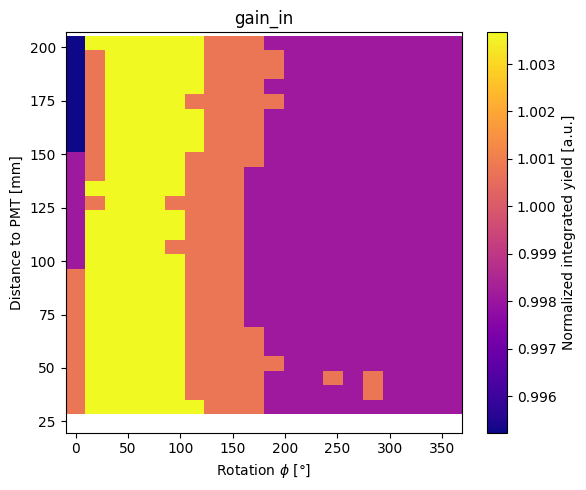

In [ ]:
Gain2 = ["gain_out", "gain_in"]
for qc in QC:
    for gain in Gain2:      
        qc.heatmap_WOM(ch1=f"{gain}", baseline_subtract = False, normalize = False)#, remove_rows = [0,2], normalize = False, title = [f"WOM 11 response {pm}"], colorlabel = ["Signal integrated yield/ Reference integrated yield"]) #no rows removed

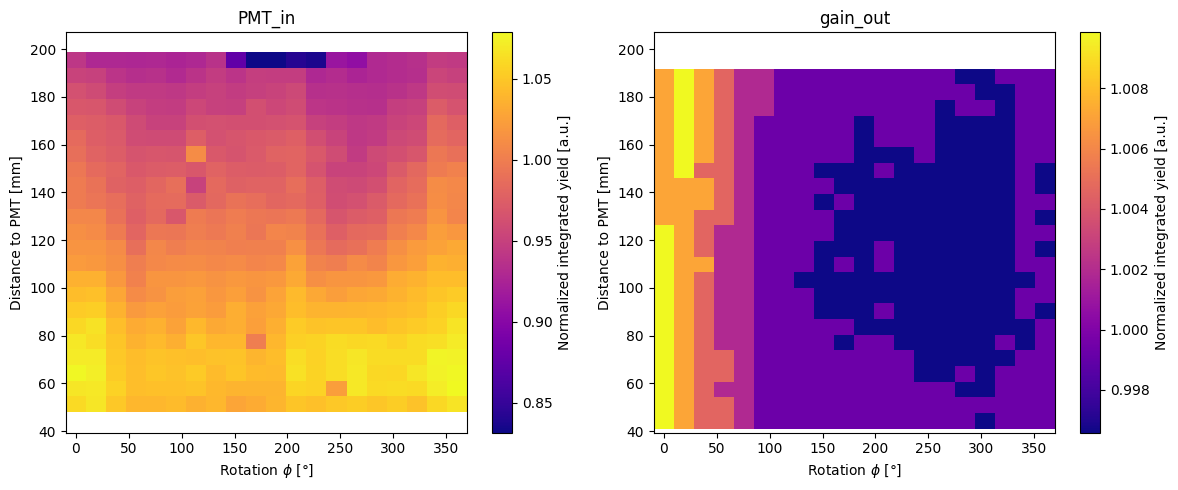

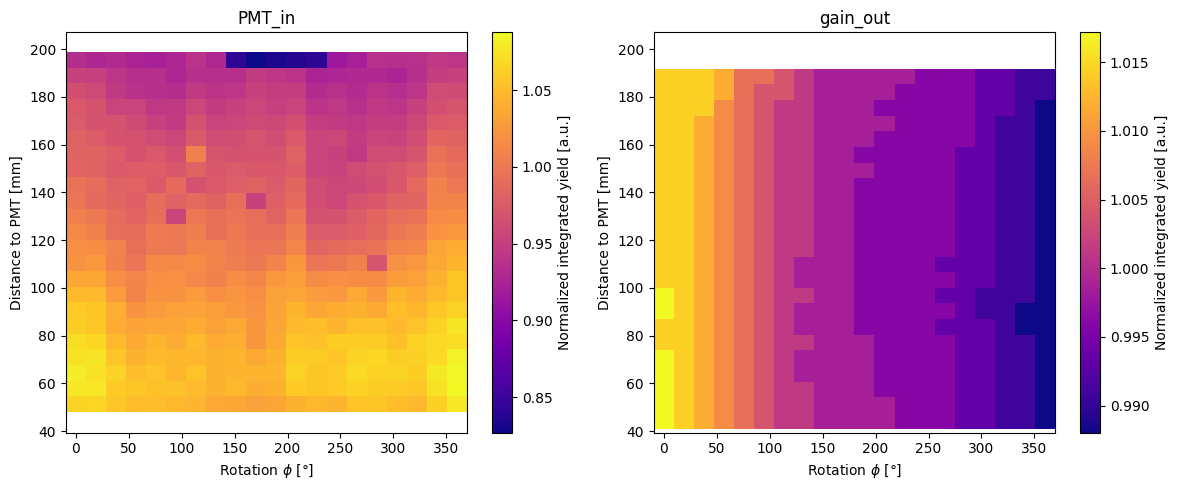

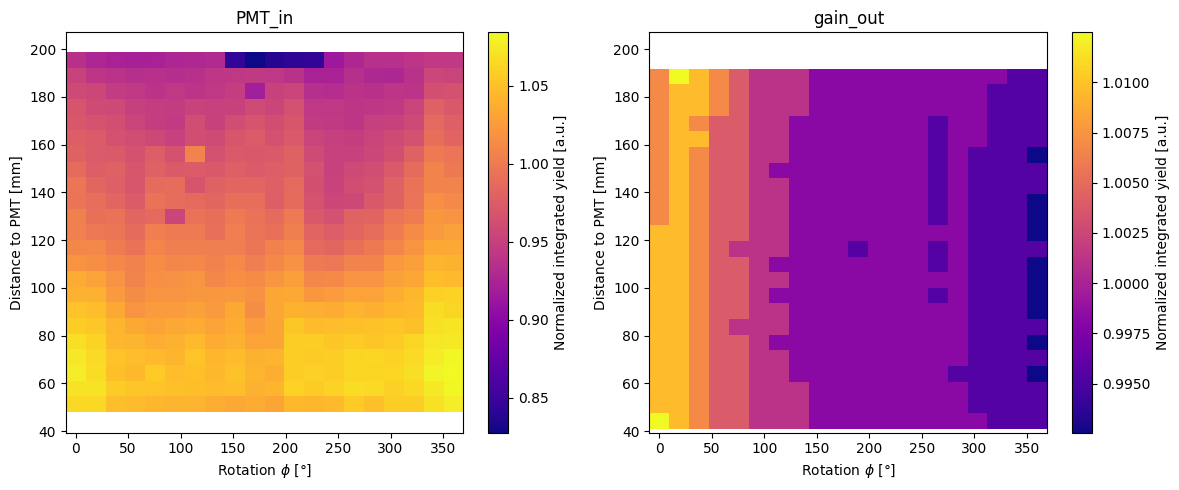

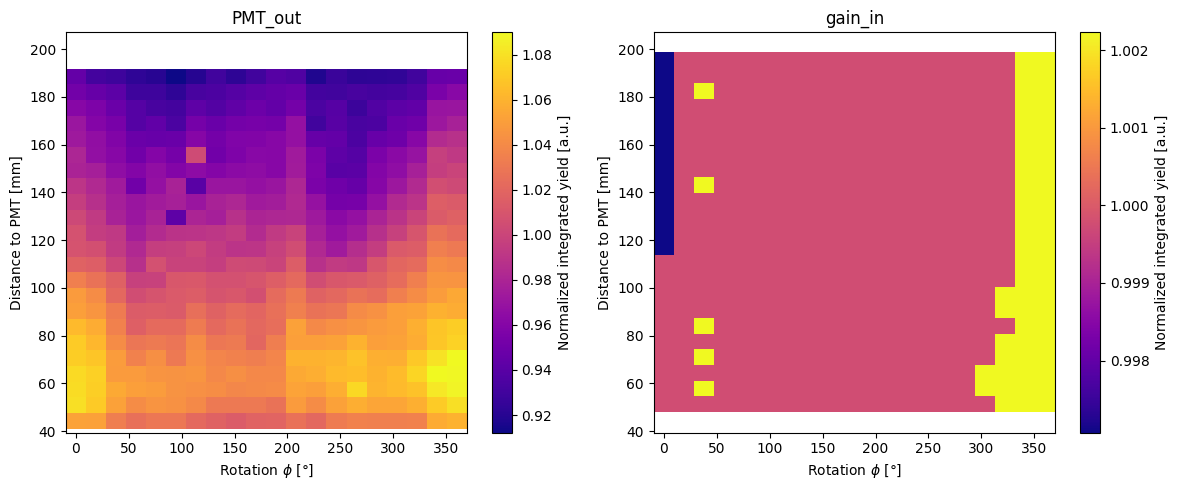

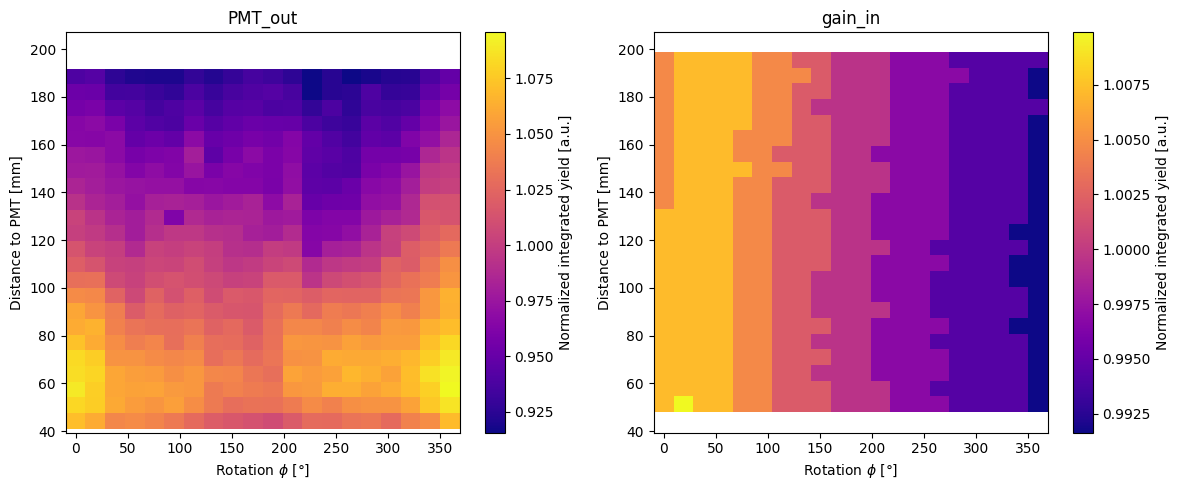

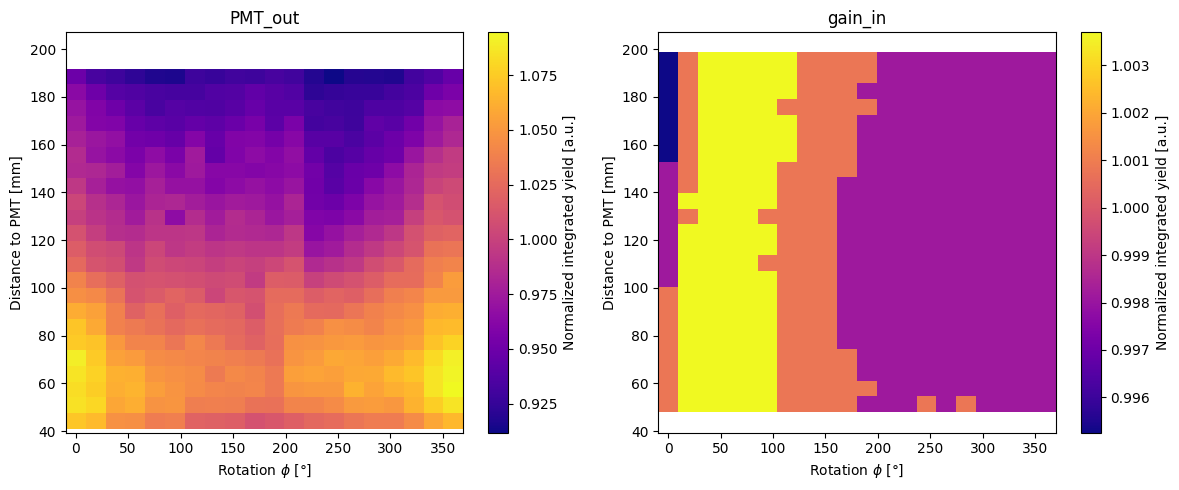

In [92]:
PM = ["PMT_in", "PMT_out"]
for pm, gain in zip(PM, Gain):  
    for qc in QC: 
        qc.heatmap_WOM(ch1=f"{pm}", ch2=f"{gain}", baseline_subtract = False, normalize = True, remove_rows = [1,2])#, title = [f"WOM 11 response {pm}"], colorlabel = ["Signal integrated yield/ Reference integrated yield"]) #no rows removed

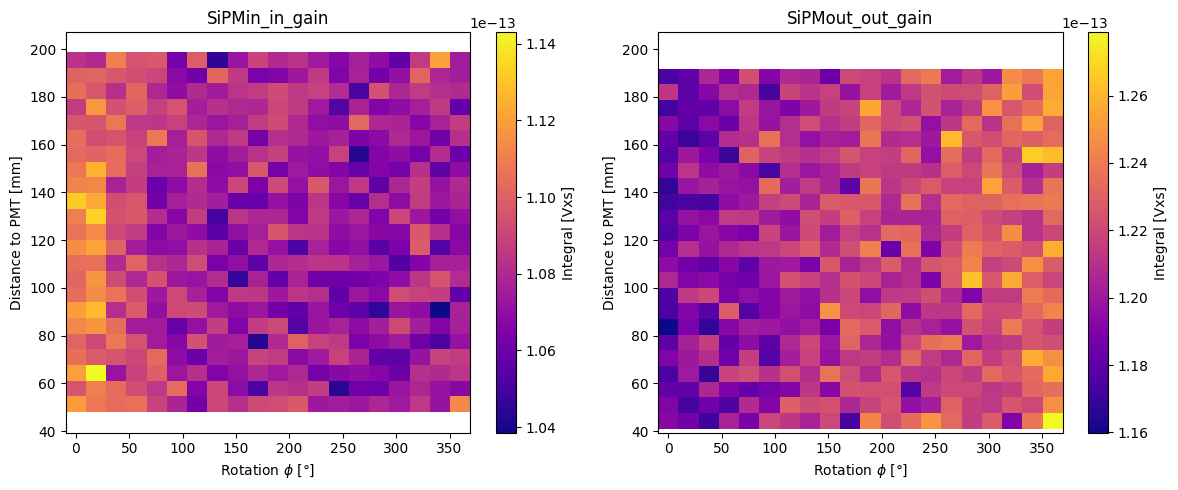

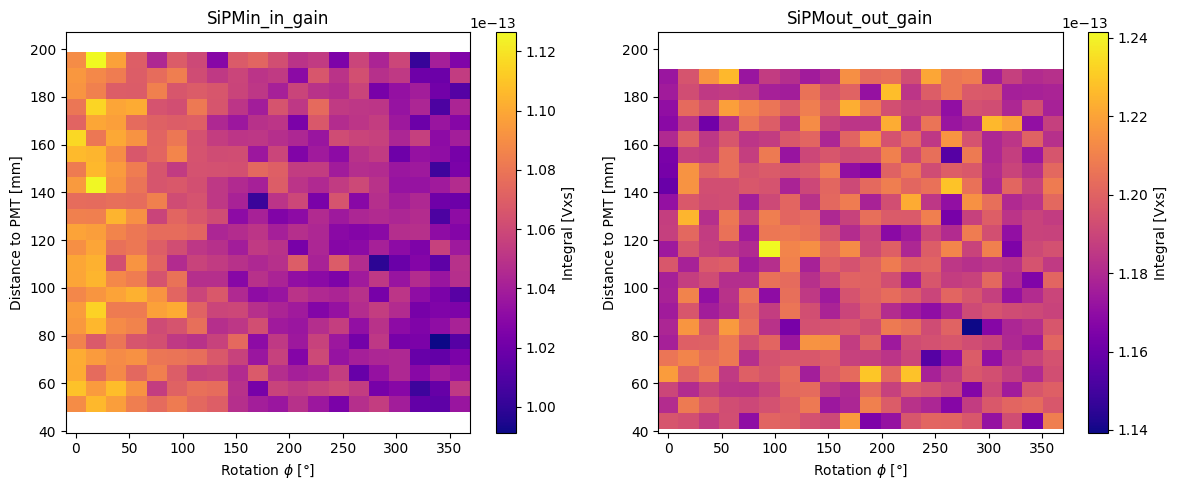

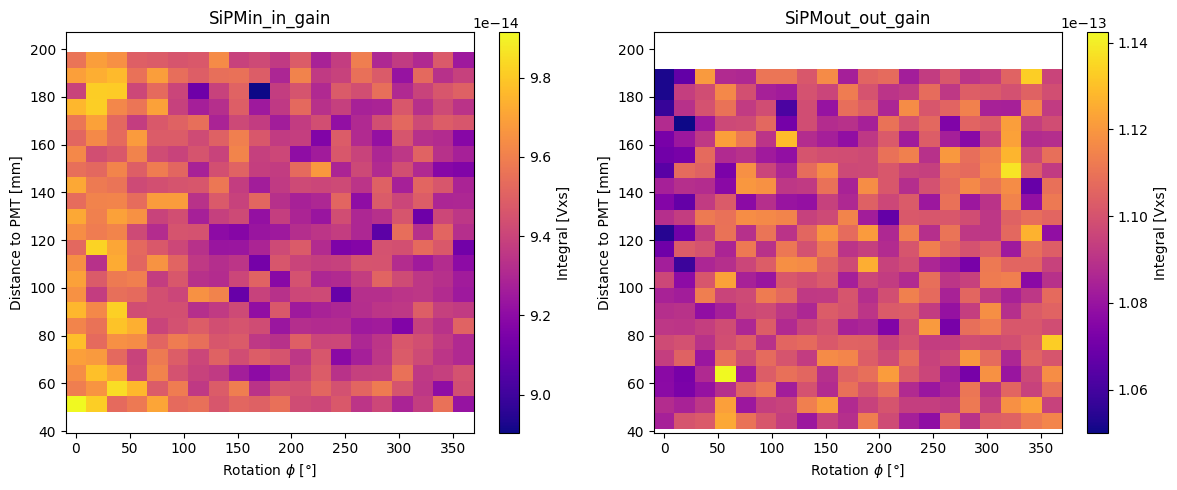

In [72]:
for qc in QC:   
    qc.heatmap_WOM(ch1="SiPMin_in_gain", ch2="SiPMout_out_gain", baseline_subtract = False, remove_rows = [1,2])#, title = [f"WOM 11 response {pm}"], colorlabel = ["Signal integrated yield/ Reference integrated yield"]) #no rows removed

In [ ]:
qc11 = WOMqc.load("20260611_testbeam_WOM_11_6_55mm_new_cover_0deg")
qc11_2 = WOMqc.load("20260617_testbeam_WOM_11_6_55mm_new_cover_0deg_2")
qc11_3 = WOMqc.load("20260617_testbeam_WOM_11_6_55mm_new_cover_0deg_3")

qc16 = WOMqc.load("20260617_testbeam_WOM_16_6_55mm_new_cover")#, redo=True)
qc16_2 = WOMqc.load("20260617_testbeam_WOM_16_6_55mm_new_cover_2")

qc6 = WOMqc.load("20260604_WOM_6_6_55mm_vertical_steps")

qc7 = WOMqc.load("20260616_testbeam_WOM_7_6_55mm_new_cover")#, redo=True)
qc7_2 = WOMqc.load("20260616_testbeam_WOM_7_6_55mm_new_cover_2")
qc7_3 = WOMqc.load("20260618_testbeam_WOM_7_6_55mm_new_cover_3")

qcthin = WOMqc.load("20260601_WOM_FreiburgXT2mm_6_55mm_old_reflector_thin_coating_4_covered_gab_ring")#, redo=True)

qc0 = qc11

qc11_wo1 = WOMqc.load("20260610_testbeam_WOM_11_6_55mm_3_new_cover_wo_coupling")
qc11_wo2 = WOMqc.load("20260625_testbeam_WOM_11_6_55mm_new_cover_wo_coupling")
qc11_wo3 = WOMqc.load("20260629_testbeam_WOM_11_6_55mm_new_cover_wo_coupling_2")

qc90 = WOMqc.load("20260611_testbeam_WOM_11_6_55mm_new_cover_90deg")

qc180 = WOMqc.load("20260611_testbeam_WOM_11_6_55mm_new_cover_180deg")

qc270 = WOMqc.load("20260612_testbeam_WOM_11_6_55mm_new_cover_270deg")


#qc = WOMqc.load("20260518_longterm_281_WOM_FreiburgXT2mm01_60000")#, redo=True)
qc1 = WOMqc.load("20260429_WOM_FreiburgXT2mm01_6_66mm_vertical_steps")#, redo=True)

qc2 = WOMqc.load("20260430_WOM_FreiburgXT2mm01_6_66mm_vertical_steps")#, redo=True)

qc3 = WOMqc.load("20260430_WOM_FreiburgXT2mm01_6_66mm_vertical_steps_2")#, redo=True)


In [6]:
PM_ref = ["SiPMin_out_ref", "PMT_out_ref", "SiPMout_in_ref", "PMT_in_ref"]
QC = [qc11, qc11_2, qc16, qc16_2, qc7, qc7_2, qcthin, qc0, qc90, qc180, qc270]
for qc in QC:
    for pm in PM_ref:
        qc.baseline_integrated_data[pm+"_err"] = qc.baseline_integrated_data[pm+"_std"]/np.sqrt(qc.rep)

### Preparing Plots for the 37th collaboration meeting
- WOM 11
	- [x] Trans/ Response example
	- [x] Ratio - PMT/Transmission 
	- [ ] Repeated Measurement Pull plot 
		- [ ] Histograms? 
	- [x] Rotation one WOM - 0, 90, 180, 270 - normalized?
- [ ] WOM response difference - over PMT distance and over transmission - Total light yield 

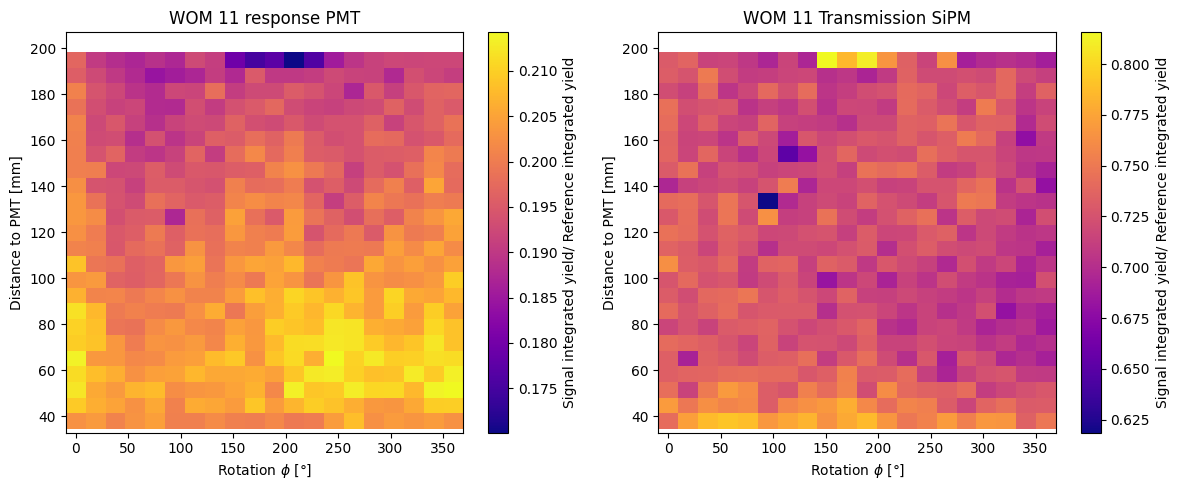

0

In [7]:
#qc11.heatmap_WOM(ch1="PMT_out_ref", ch2="SiPMin_out_ref", baseline_subtract = True, remove_rows = [0,2], normalize = False, vmin = [0.14, 0.4],  vmax = [ 0.20, 1.05], title = ["WOM 11 response PMT", "WOM 11 Transmission SiPM"], colorlabel = ["Signal integrated yield/ Reference integrated yield", "Signal integrated yield/ Reference integrated yield"]) #no rows removed
#qc11_2.heatmap_WOM(ch1="PMT_out_ref", ch2="SiPMin_out_ref", baseline_subtract = True, remove_rows = [0,2], normalize = False, vmin = [0.14, 0.4],  vmax = [ 0.20, 1.05], title = ["WOM 11 response PMT", "WOM 11 Transmission SiPM"], colorlabel = ["Signal integrated yield/ Reference integrated yield", "Signal integrated yield/ Reference integrated yield"]) #no rows removed
qc0.heatmap_WOM(ch1="PMT_out_ref", ch2="SiPMin_out_ref", baseline_subtract = True, remove_rows = [0,2], normalize = False, title = ["WOM 11 response PMT", "WOM 11 Transmission SiPM"], colorlabel = ["Signal integrated yield/ Reference integrated yield", "Signal integrated yield/ Reference integrated yield"]) #no rows removed
#qc0_wo.heatmap_WOM(ch1="PMT_out_ref", ch2="SiPMin_out_ref", baseline_subtract = True, remove_rows = [0,2], normalize = False, title = ["WOM 11 response PMT", "WOM 11 Transmission SiPM"], colorlabel = ["Signal integrated yield/ Reference integrated yield", "Signal integrated yield/ Reference integrated yield"]) #no rows removed

In [9]:
QC_rot = [qc0, qc90, qc180, qc270, qc11, qc11_2, qc7, qc7_2, qc16, qc16_2]
for qc in QC_rot:
    qc.baseline_integrated_data["Trans_over_Response_out"] = qc.baseline_integrated_data["SiPMin_out_ref"]/qc.baseline_integrated_data["PMT_out_ref"]
    qc.baseline_integrated_data["Trans_over_Response_in"] = qc.baseline_integrated_data["SiPMout_in_ref"]/qc.baseline_integrated_data["PMT_in_ref"]

In [10]:
QC_rot = [qc0, qc90, qc180, qc270, qc11, qc11_2, qc7, qc7_2, qc16, qc16_2]
for qc in QC_rot:
    qc.baseline_integrated_data["Trans_times_Response_out"] = qc.baseline_integrated_data["SiPMin_out_ref"]*qc.baseline_integrated_data["PMT_out_ref"]
    qc.baseline_integrated_data["Trans_times_Response_in"] = qc.baseline_integrated_data["SiPMout_in_ref"]*qc.baseline_integrated_data["PMT_in_ref"]

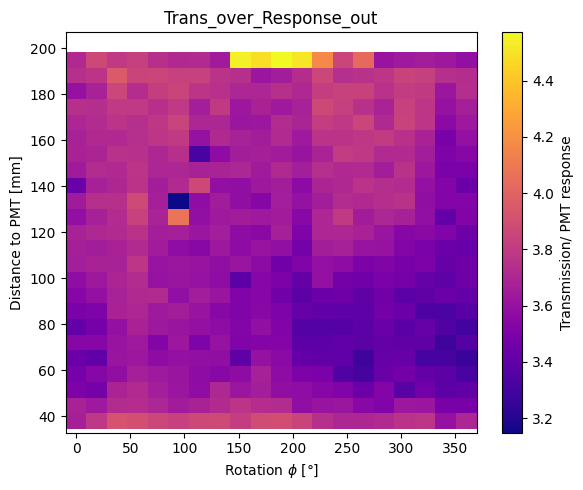

0

In [11]:
qc11.heatmap_WOM(ch1="Trans_over_Response_out", baseline_subtract = True, remove_rows = [0,2], normalize = False, colorlabel = ["Transmission/ PMT response"])  


In [8]:
PM_REF = PM_ref
PM_REF_ERR = [f"{pm}_err" for pm in PM_REF]
qcs1 = [qc11, qc7, qc16]
qcs2 = [qc11_2, qc7_2, qc11]
qcnames = ["1-2", "1-2", "1-2"]

for i in range(len(qcs1)):
    qc = qcs1[i]
    q = qcs2[i]
    for pm_ref, pm_ref_err in zip(PM_REF, PM_REF_ERR):
            qc.baseline_integrated_data[pm_ref + "_" + qcnames[i]] = qc.baseline_integrated_data[pm_ref] - q.baseline_integrated_data[pm_ref]
            qc.baseline_integrated_data[pm_ref_err + "_" + qcnames[i]] = np.sqrt((qc.baseline_integrated_data[pm_ref + "_std"]/np.sqrt(qc.rep))**2 + (q.baseline_integrated_data[pm_ref + "_std"]/np.sqrt(qc.rep))**2)

In [9]:
PM = ["PMT_in", "SiPMout_in", "PMT_out", "SiPMin_out"]
PM_PUll = [f"{pm}_ref_pull_{qcname}" for pm in PM for qcname in qcnames]

for pm_ref in PM_REF:
    for qc, qcname in zip(qcs1, qcnames):
        qc.baseline_integrated_data[f"{pm_ref}_pull_{qcname}"] = qc.baseline_integrated_data[pm_ref + "_1-2"] / qc.baseline_integrated_data[pm_ref + "_err_1-2"]

In [10]:
PM_REF = PM_ref
PM_REF_ERR = [f"{pm}_err" for pm in PM_REF]
qcs1 = [qc1, qc1, qc2]
qcs2 = [qc2, qc3, qc3]
qcnames = ["1-2", "1-3", "2-3"]

for i in range(len(qcs1)):
    qc = qcs1[i]
    q = qcs2[i]
    for pm_ref, pm_ref_err in zip(PM_REF, PM_REF_ERR):
            qc1.baseline_integrated_data[pm_ref + "_" + qcnames[i]] = qc.baseline_integrated_data[pm_ref] - q.baseline_integrated_data[pm_ref]
            qc1.baseline_integrated_data[pm_ref_err + "_" + qcnames[i]] = np.sqrt((qc.baseline_integrated_data[pm_ref + "_std"]/np.sqrt(qc.rep))**2 + (q.baseline_integrated_data[pm_ref + "_std"]/np.sqrt(qc.rep))**2)

PM = ["PMT_in", "SiPMout_in", "PMT_out", "SiPMin_out"]
PM_PUll = [f"{pm}_ref_pull_{qcname}" for pm in PM for qcname in qcnames]

for pm_ref in PM_REF:
    for qcname in qcnames:
        qc1.baseline_integrated_data[f"{pm_ref}_pull_{qcname}"] = qc.baseline_integrated_data[pm_ref + "_" + qcname] / qc.baseline_integrated_data[pm_ref + "_err_" + qcname]            

KeyError: 'SiPMin_out_ref_1-2'

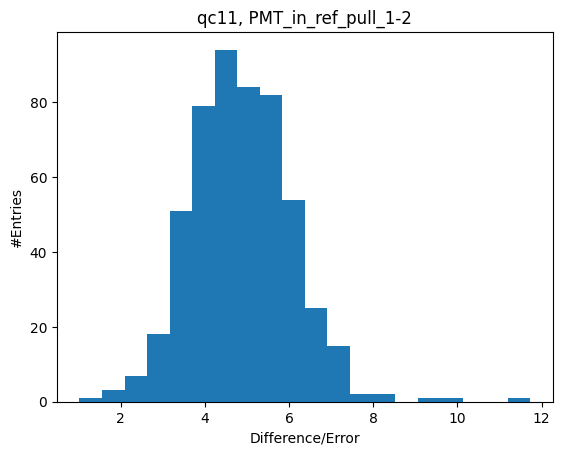

KeyError: 'PMT_in_ref_pull_1-3'

In [11]:
qcs1 = [qc11, qc7, qc16]
labels = ["qc11", "qc7", "qc16"]
for qc, label in zip(qcs1, labels):
    for pm_pull in PM_PUll:
        #print(qc1.integrated_data[pm_pull])
        plt.hist(qc.baseline_integrated_data[pm_pull], bins = 20)#, range=[-4,4])
        title = f"{label}, {pm_pull}"
        plt.title(title)
        plt.xlabel("Difference/Error")
        #plt.xlim(-4,4)
        plt.ylabel("#Entries")
        plt.show()


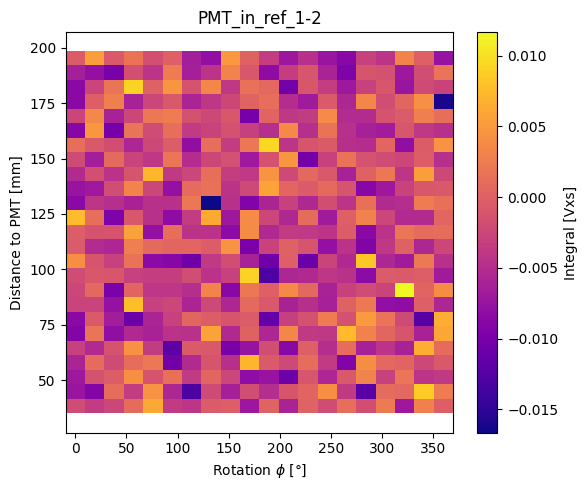

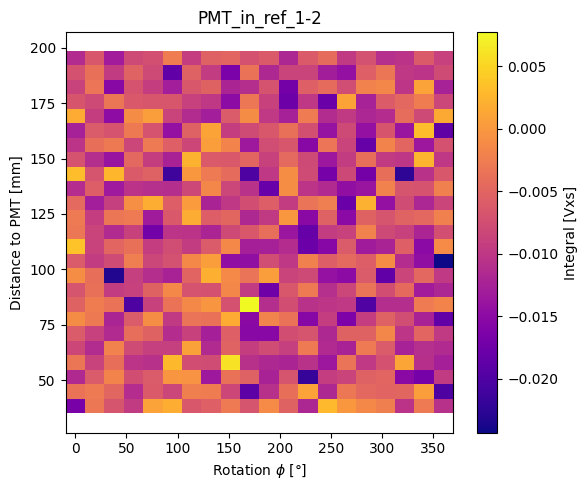

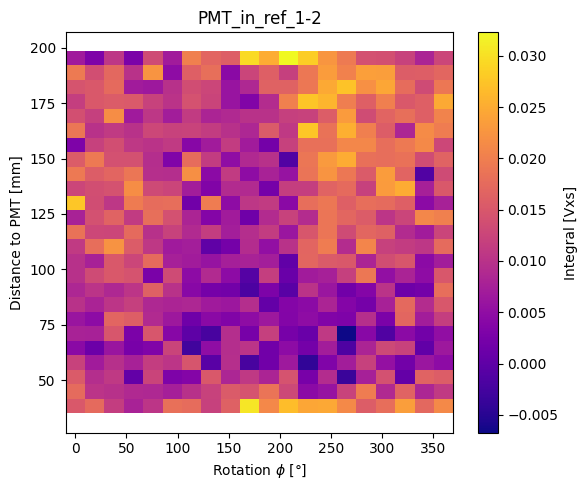

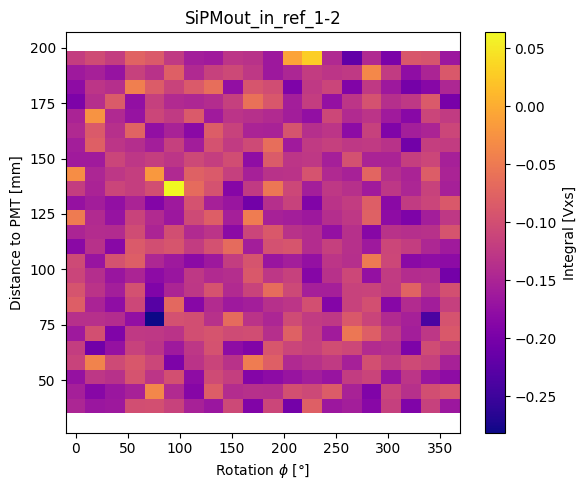

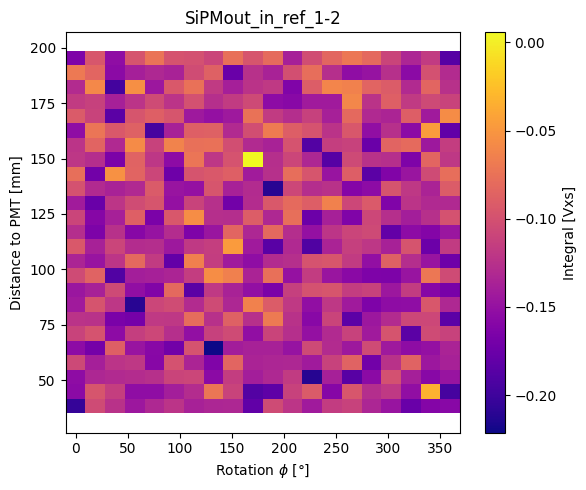

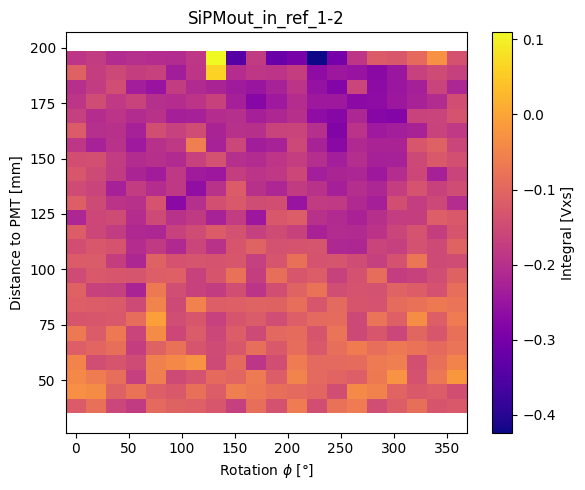

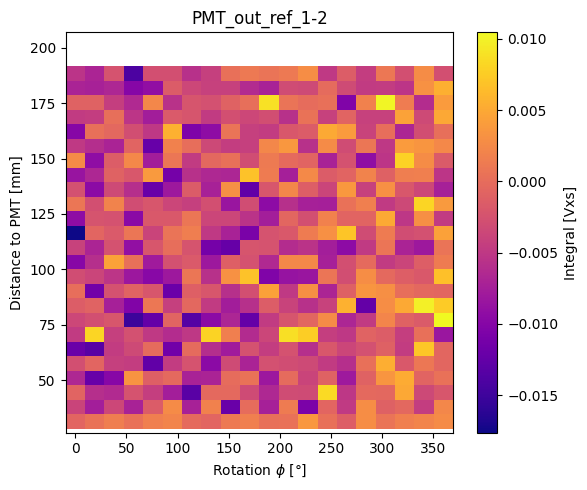

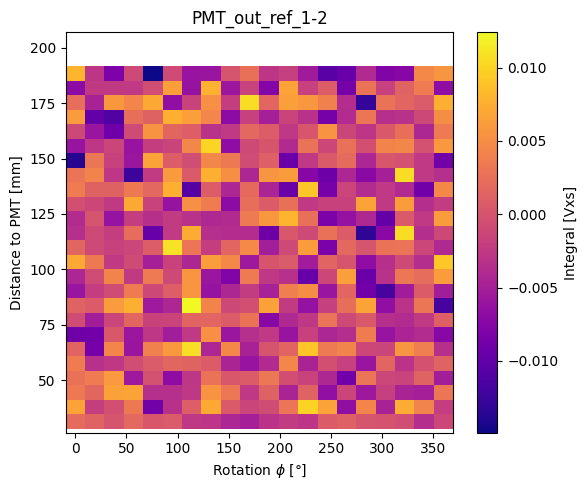

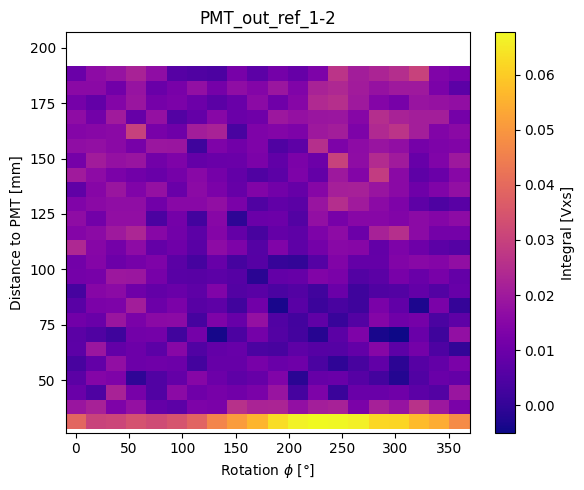

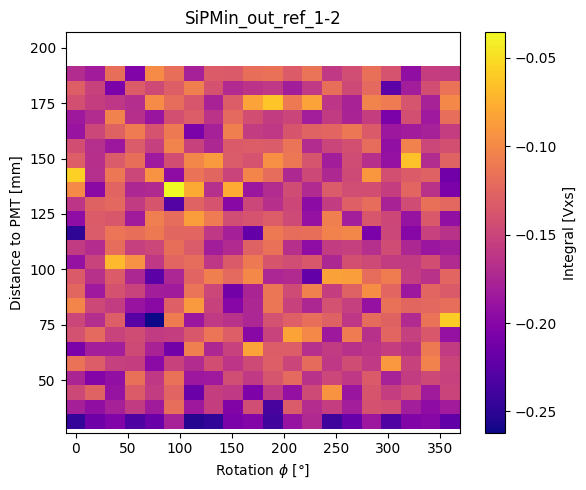

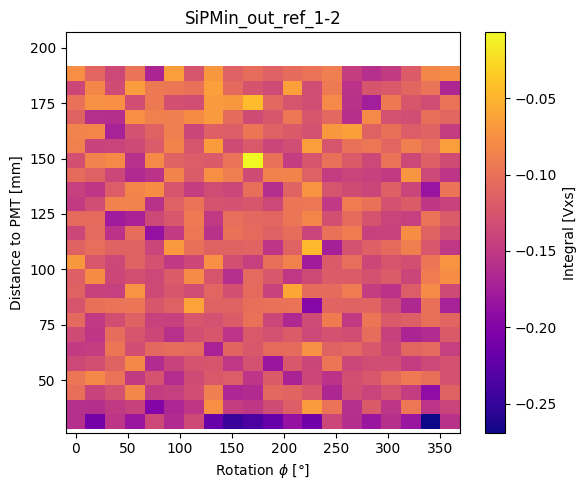

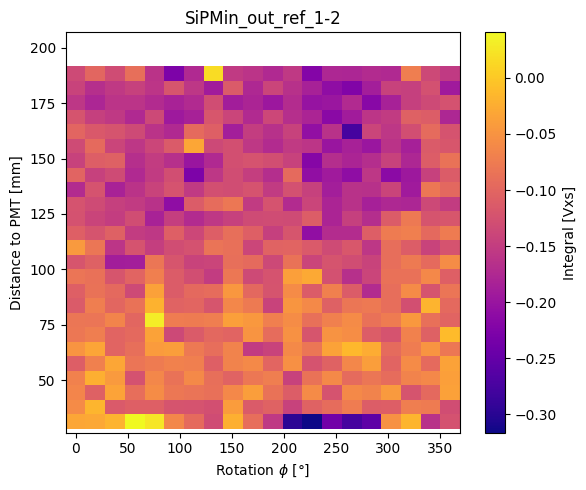

In [ ]:
for pm_ref in PM_REF:
    qc11.heatmap_WOM(ch1= pm_ref + "_1-2" , step_size = 6.55, remove_rows = [1,0])#, vmin = [-4], vmax = [4]) 
    qc7.heatmap_WOM(ch1= pm_ref + "_1-2" , step_size = 6.55, remove_rows = [1,0])#, vmin = [-4], vmax = [4]) 
    qc16.heatmap_WOM(ch1= pm_ref + "_1-2" , step_size = 6.55, remove_rows = [1,0])#, vmin = [-4], vmax = [4]) 



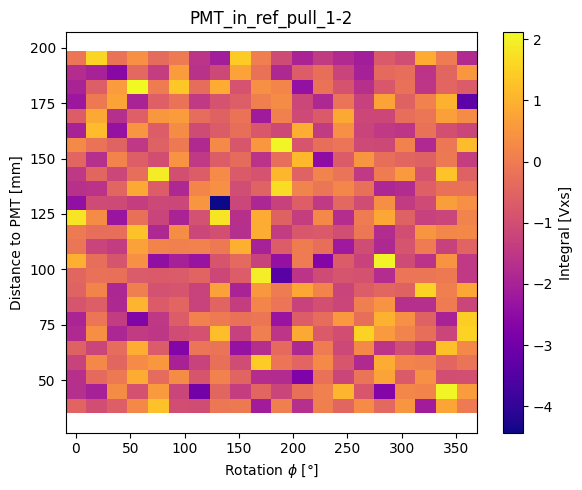

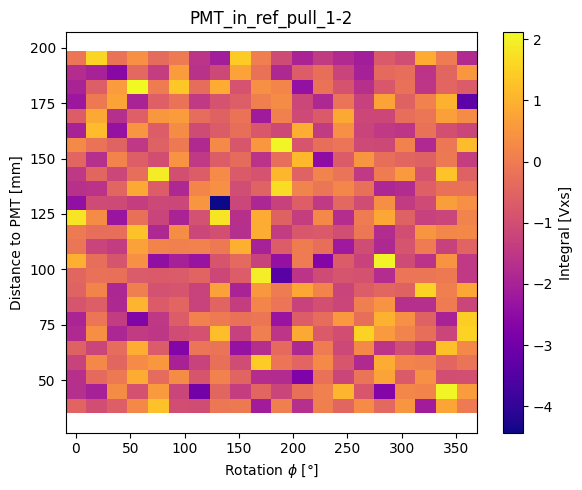

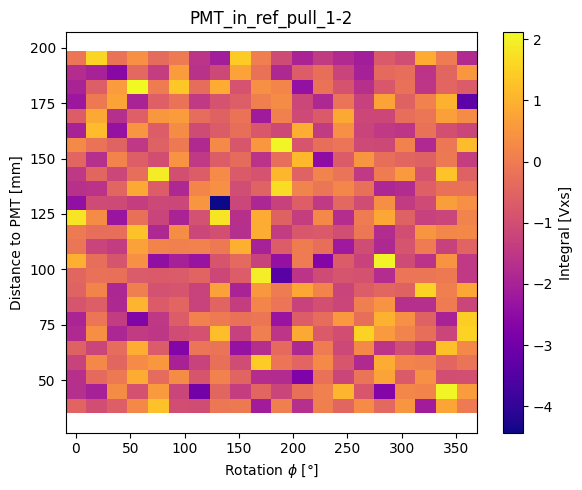

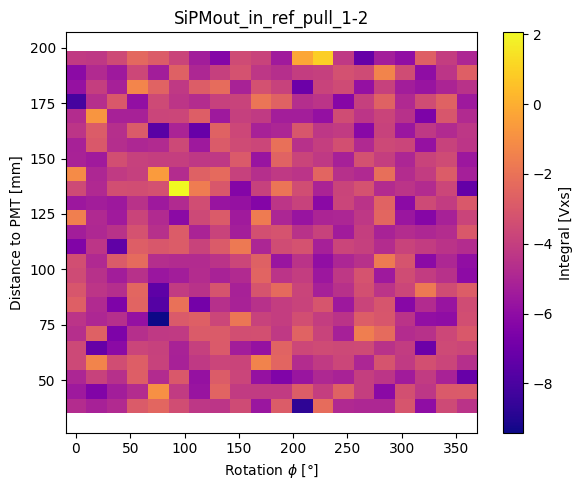

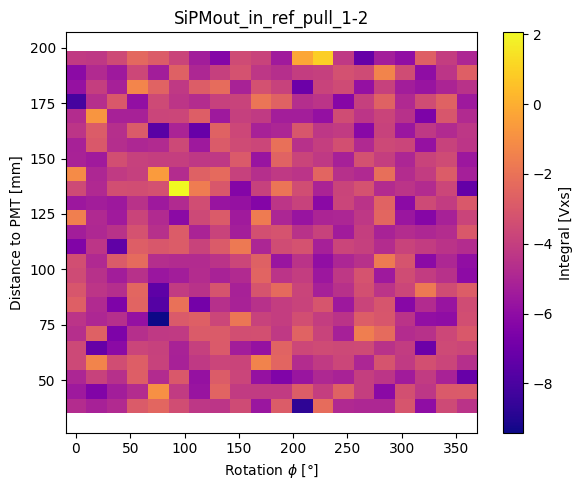

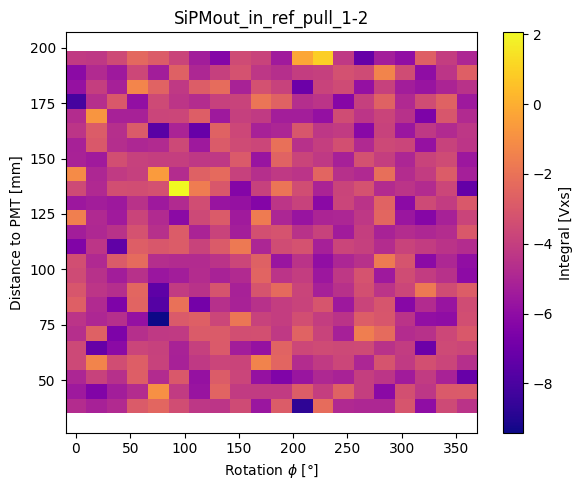

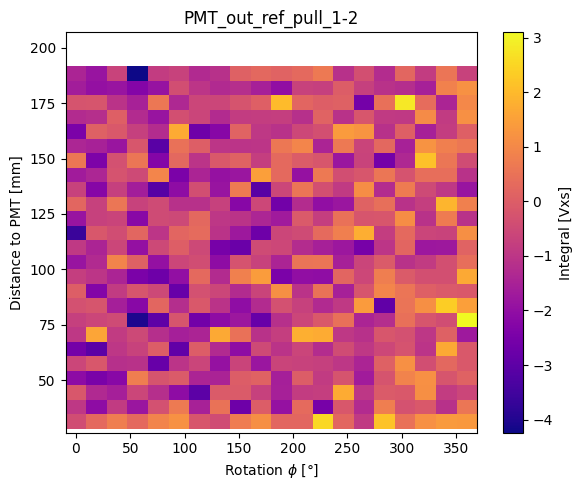

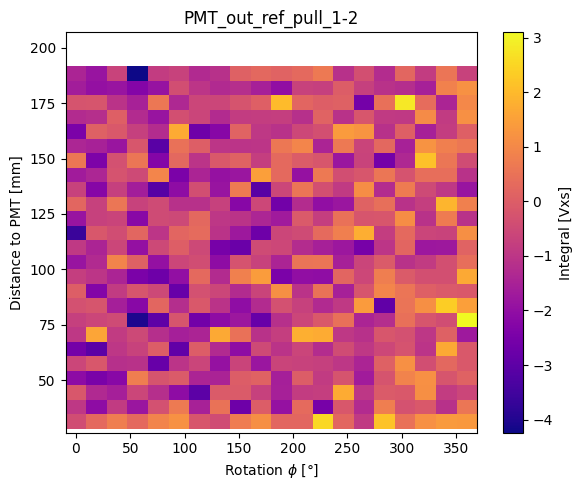

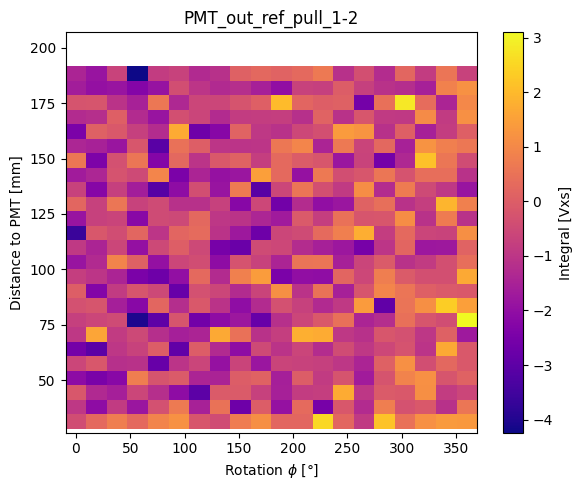

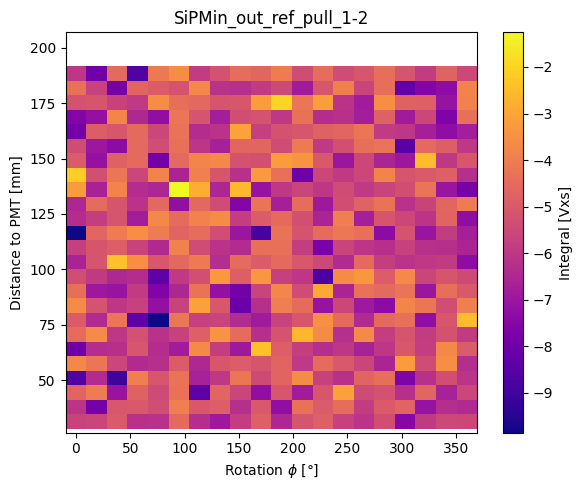

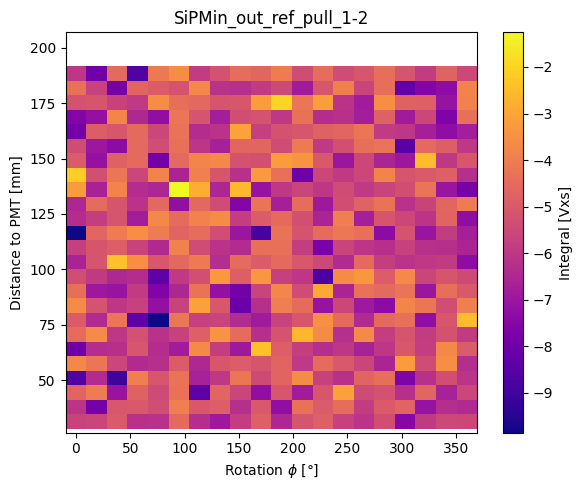

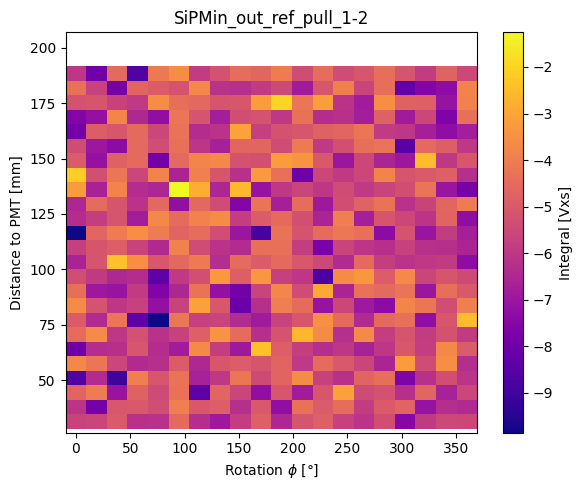

In [ ]:
for pm_pull in PM_PUll:
    qc11.heatmap_WOM(ch1= pm_pull , step_size = 6.55, remove_rows = [1,0])#, vmin = [-4], vmax = [4]) 

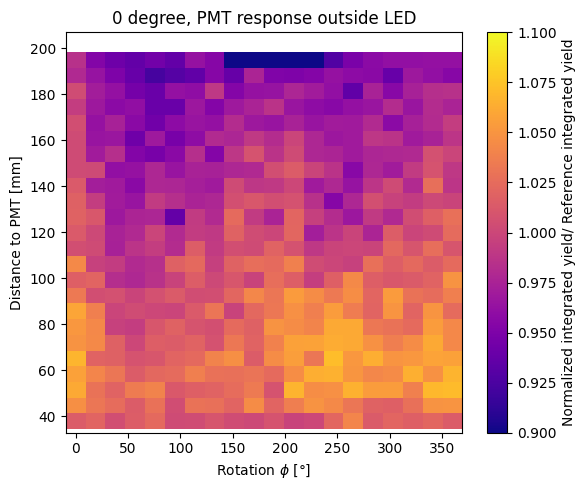

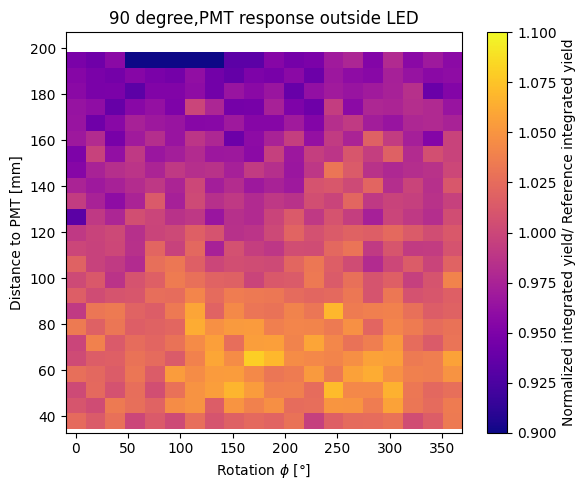

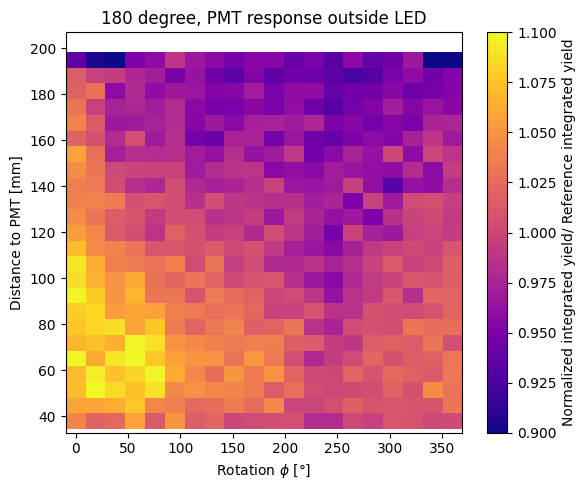

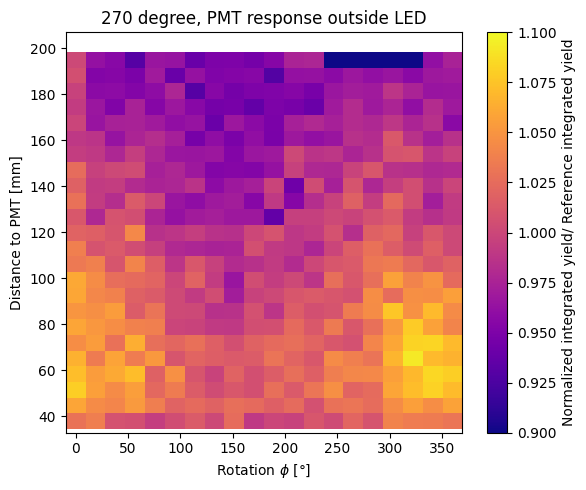

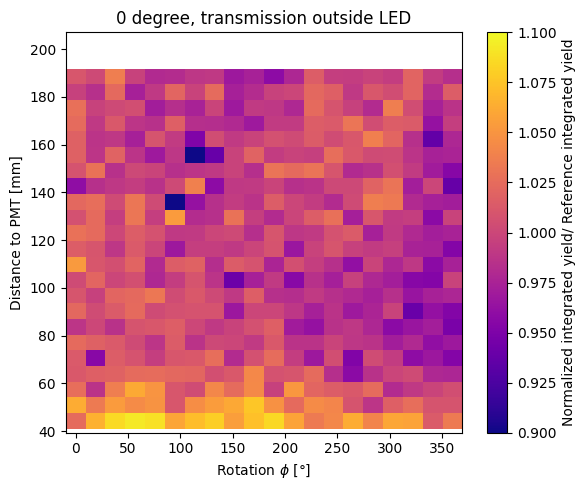

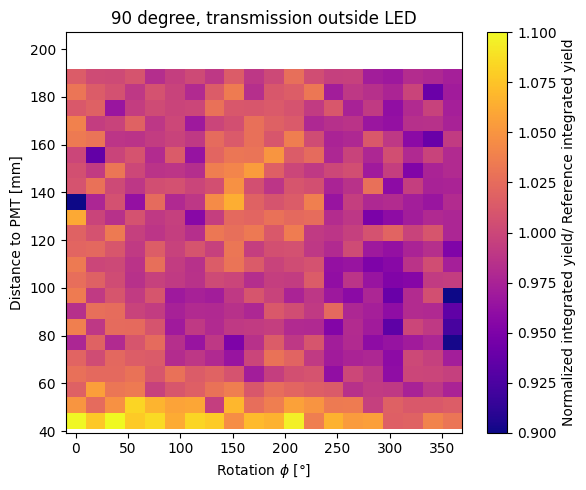

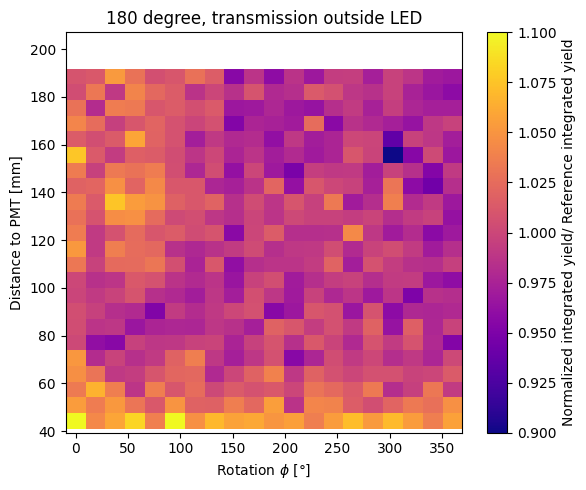

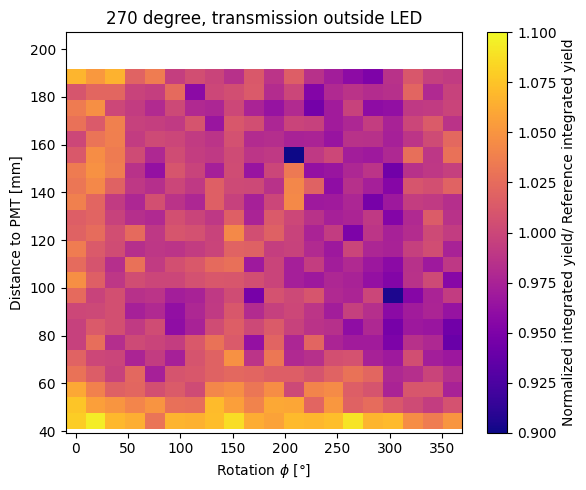

0

In [ ]:
vmin, vmax = 0.9, 1.1

qc0.heatmap_WOM(ch1="PMT_out_ref", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [0,2], normalize = True, title = ["0 degree, PMT response outside LED"], colorlabel = ["Normalized integrated yield/ Reference integrated yield"]) 
qc90.heatmap_WOM(ch1="PMT_out_ref", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [0,2], normalize = True, title = ["90 degree,PMT response outside LED"], colorlabel = ["Normalized integrated yield/ Reference integrated yield"]) 
qc180.heatmap_WOM(ch1="PMT_out_ref", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [0,2], normalize = True, title = ["180 degree, PMT response outside LED"], colorlabel = ["Normalized integrated yield/ Reference integrated yield"]) 
qc270.heatmap_WOM(ch1="PMT_out_ref", vmin = [vmin], vmax= [vmax],  baseline_subtract = True, remove_rows = [0,2], normalize = True, title = ["270 degree, PMT response outside LED"], colorlabel = ["Normalized integrated yield/ Reference integrated yield"]) 

qc0.heatmap_WOM(ch1 ="SiPMin_out_ref", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [1,2], normalize = True, title = ["0 degree, transmission outside LED"], colorlabel = ["Normalized integrated yield/ Reference integrated yield"]) 
qc90.heatmap_WOM(ch1="SiPMin_out_ref", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [1,2], normalize = True, title = ["90 degree, transmission outside LED"], colorlabel = ["Normalized integrated yield/ Reference integrated yield"]) 
qc180.heatmap_WOM(ch1="SiPMin_out_ref", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [1,2], normalize = True, title = ["180 degree, transmission outside LED"], colorlabel = ["Normalized integrated yield/ Reference integrated yield"]) 
qc270.heatmap_WOM(ch1="SiPMin_out_ref", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [1,2], normalize = True, title = ["270 degree, transmission outside LED"], colorlabel = ["Normalized integrated yield/ Reference integrated yield"]) 


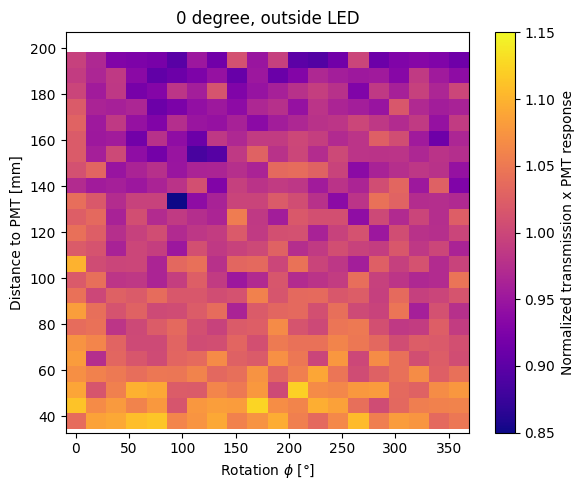

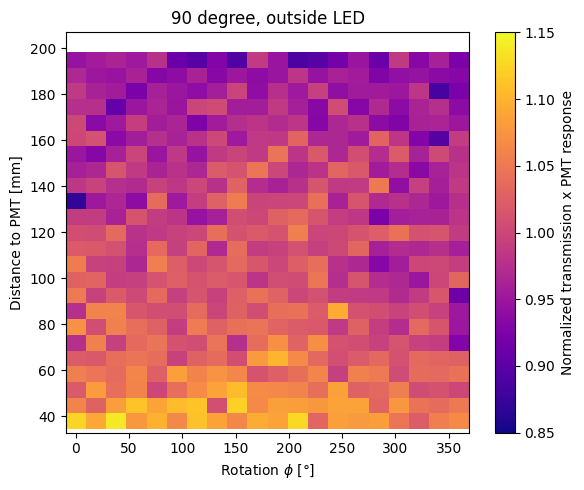

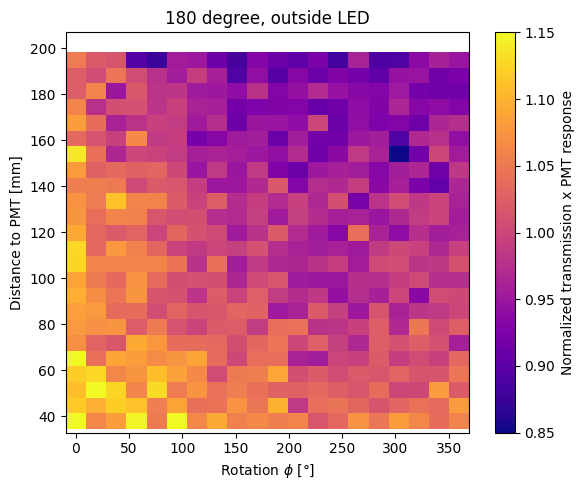

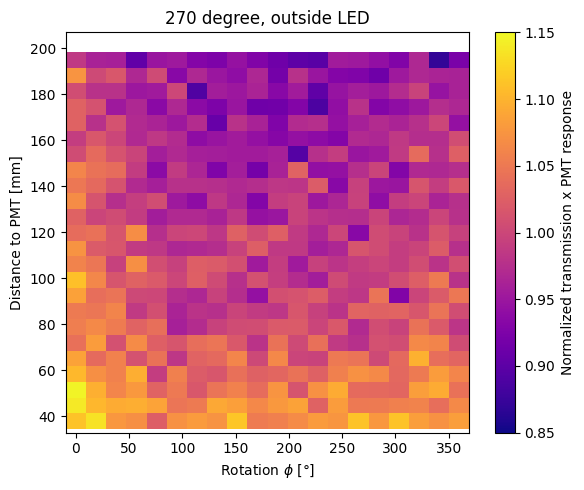

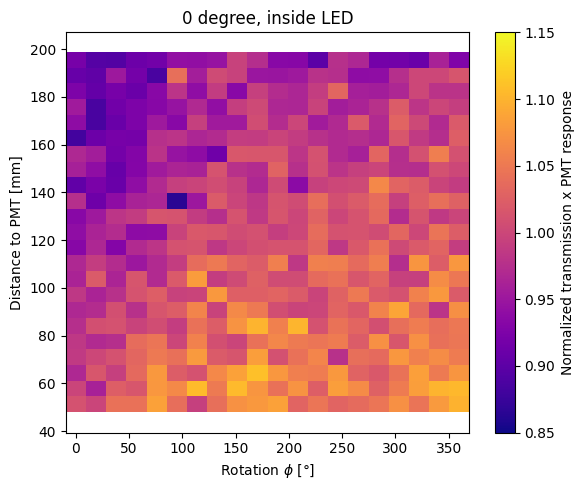

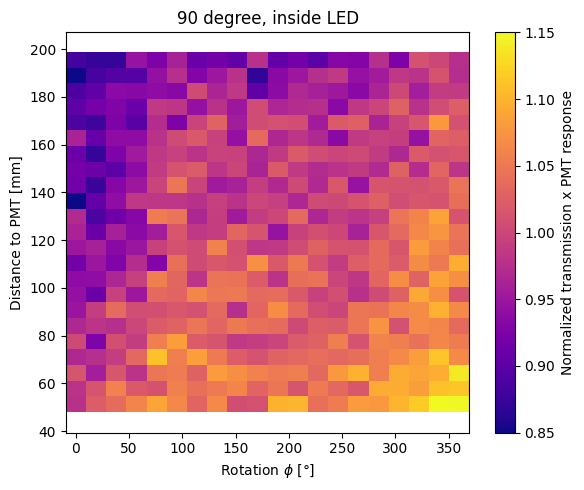

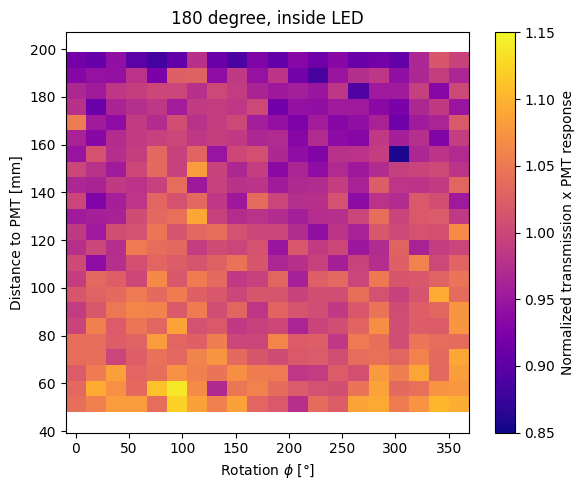

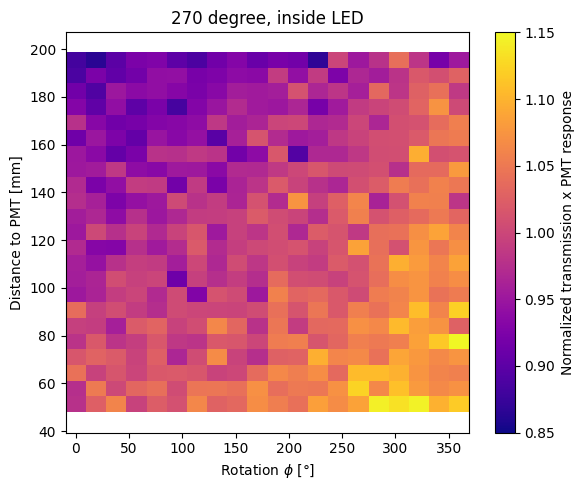

0

In [ ]:
vmin, vmax = 0.85, 1.15

qc0.heatmap_WOM(ch1="Trans_times_Response_out", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [0,2], normalize = True, title = ["0 degree, outside LED"], colorlabel = ["Normalized transmission x PMT response"]) 
qc90.heatmap_WOM(ch1="Trans_times_Response_out", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [0,2], normalize = True, title = ["90 degree, outside LED"], colorlabel = ["Normalized transmission x PMT response"]) 
qc180.heatmap_WOM(ch1="Trans_times_Response_out", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [0,2], normalize = True, title = ["180 degree, outside LED"], colorlabel = ["Normalized transmission x PMT response"]) 
qc270.heatmap_WOM(ch1="Trans_times_Response_out", vmin = [vmin], vmax= [vmax],  baseline_subtract = True, remove_rows = [0,2], normalize = True, title = ["270 degree, outside LED"], colorlabel = ["Normalized transmission x PMT response"])  

qc0.heatmap_WOM(ch1 ="Trans_times_Response_in", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [1,2], normalize = True, title = ["0 degree, inside LED"], colorlabel = ["Normalized transmission x PMT response"]) 
qc90.heatmap_WOM(ch1="Trans_times_Response_in", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [1,2], normalize = True, title = ["90 degree, inside LED"], colorlabel = ["Normalized transmission x PMT response"]) 
qc180.heatmap_WOM(ch1="Trans_times_Response_in", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [1,2], normalize = True, title = ["180 degree, inside LED"], colorlabel = ["Normalized transmission x PMT response"]) 
qc270.heatmap_WOM(ch1="Trans_times_Response_in", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [1,2], normalize = True, title = ["270 degree, inside LED"], colorlabel = ["Normalized transmission x PMT response"]) 

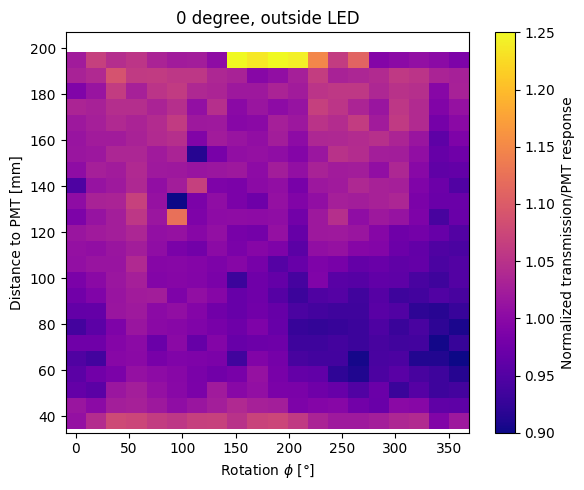

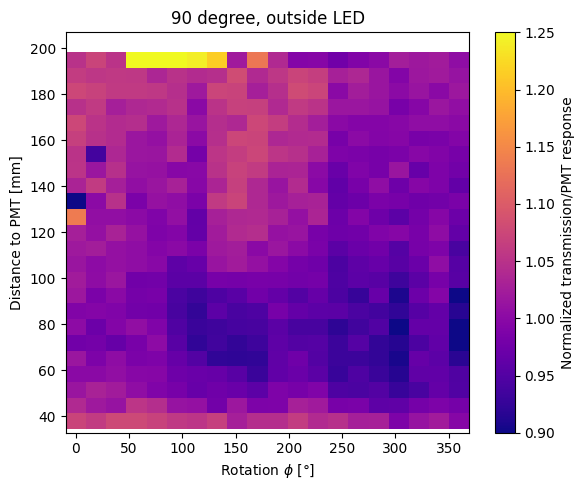

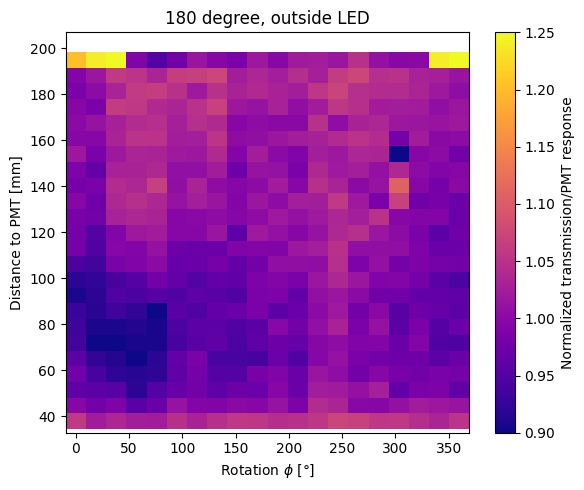

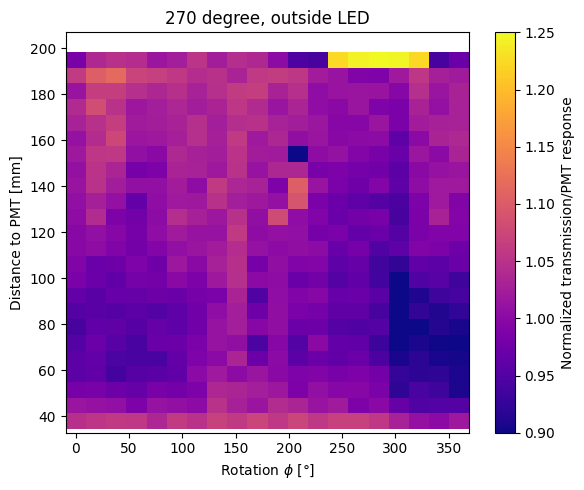

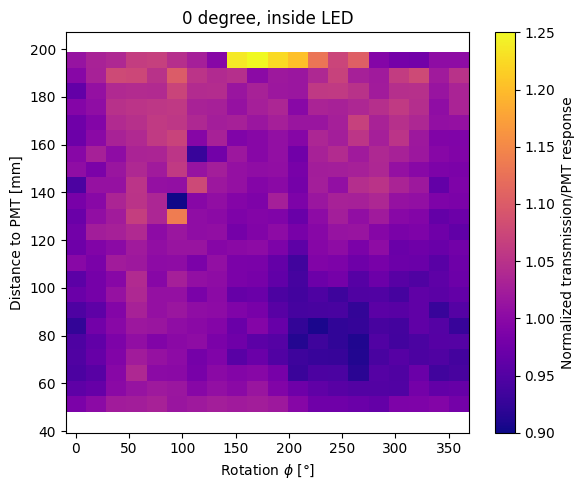

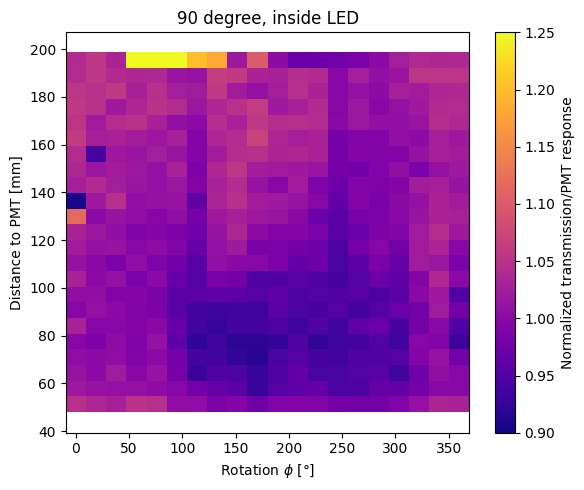

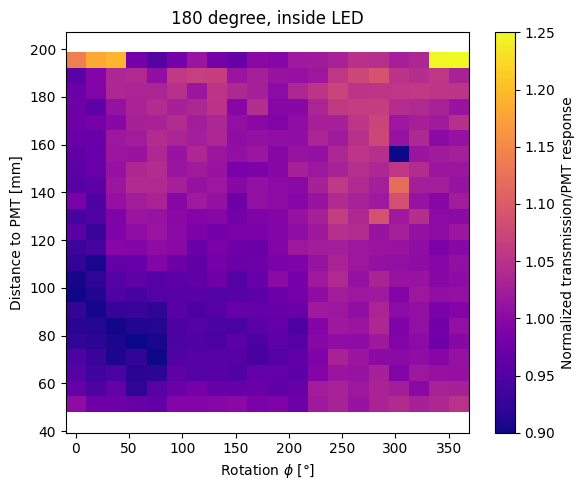

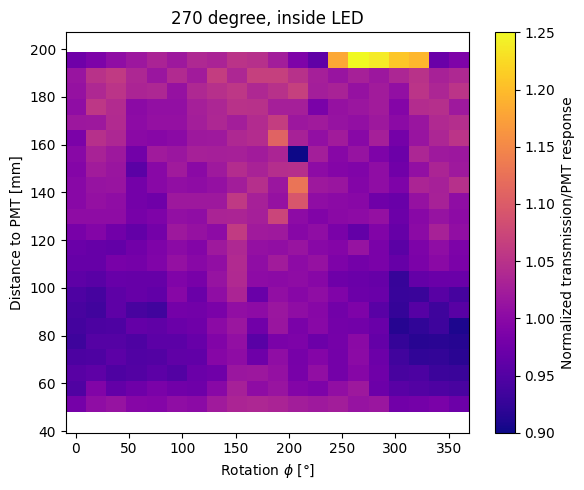

0

In [ ]:
vmin, vmax = 0.9, 1.25

qc0.heatmap_WOM(ch1="Trans_over_Response_out", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [0,2], normalize = True, title = ["0 degree, outside LED"], colorlabel = ["Normalized transmission/PMT response"]) 
qc90.heatmap_WOM(ch1="Trans_over_Response_out", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [0,2], normalize = True, title = ["90 degree, outside LED"], colorlabel = ["Normalized transmission/PMT response"]) 
qc180.heatmap_WOM(ch1="Trans_over_Response_out", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [0,2], normalize = True, title = ["180 degree, outside LED"], colorlabel = ["Normalized transmission/PMT response"]) 
qc270.heatmap_WOM(ch1="Trans_over_Response_out", vmin = [vmin], vmax= [vmax],  baseline_subtract = True, remove_rows = [0,2], normalize = True, title = ["270 degree, outside LED"], colorlabel = ["Normalized transmission/PMT response"])  

qc0.heatmap_WOM(ch1 ="Trans_over_Response_in", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [1,2], normalize = True, title = ["0 degree, inside LED"], colorlabel = ["Normalized transmission/PMT response"]) 
qc90.heatmap_WOM(ch1="Trans_over_Response_in", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [1,2], normalize = True, title = ["90 degree, inside LED"], colorlabel = ["Normalized transmission/PMT response"]) 
qc180.heatmap_WOM(ch1="Trans_over_Response_in", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [1,2], normalize = True, title = ["180 degree, inside LED"], colorlabel = ["Normalized transmission/PMT response"]) 
qc270.heatmap_WOM(ch1="Trans_over_Response_in", vmin = [vmin], vmax= [vmax], baseline_subtract = True, remove_rows = [1,2], normalize = True, title = ["270 degree, inside LED"], colorlabel = ["Normalized transmission/PMT response"])  


### How to plot waveforms from a specific position with plot_waveforms_position
- 'baseline_corrected = True' - if you want to use the waveforms with a corrected basline
- 'reps = 30, plot_mean = False', - how many events you want to see
- 'plot_integration_window = False', - if you want to plot the integration window
- 'legend = False' - if you want to se the legend

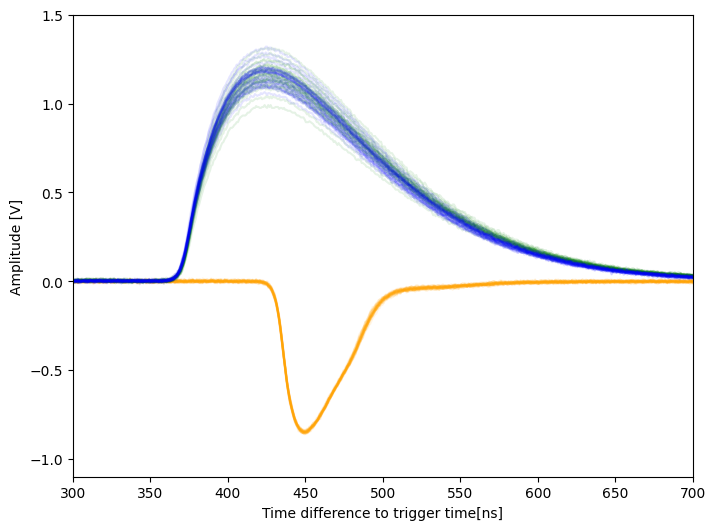

In [ ]:
qc7_2.plot_waveforms_position(i = 25, j = 1, PM=["PMT_in", "SiPMin_in", "SiPMout_in"], baseline_corrected = True, reps = 30, plot_mean = False, plot_integration_window = False, legend = False)

### How to plot the temperature over time

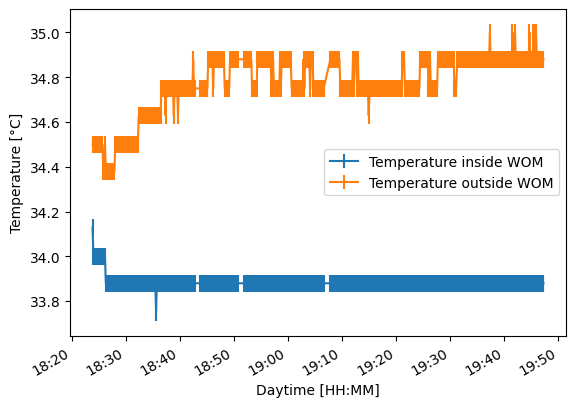

In [ ]:
qc11_2.plot_temperature_over_time()

### If you want to normalize heatmaps and/or cut rows out of the display and calulation: 

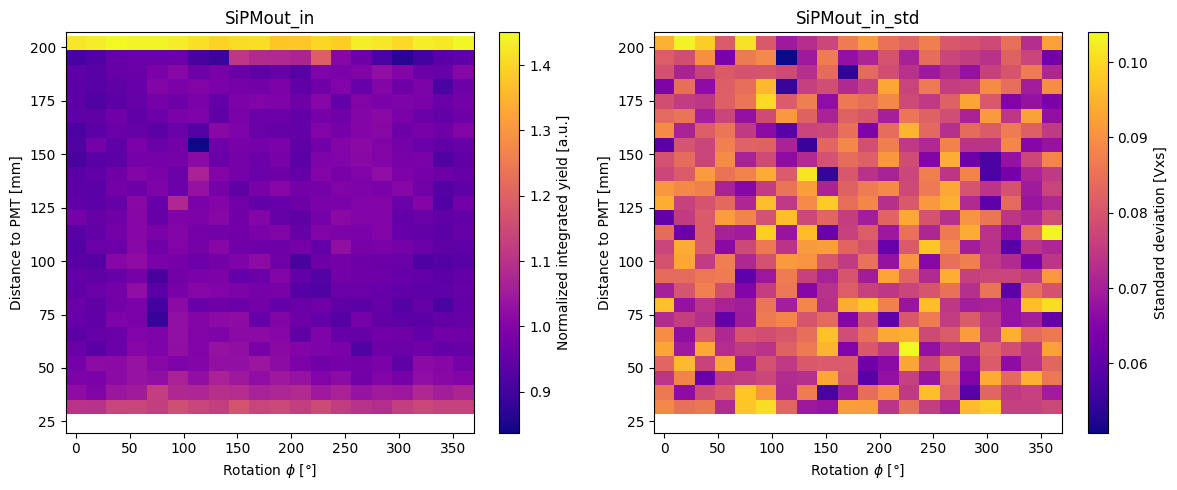

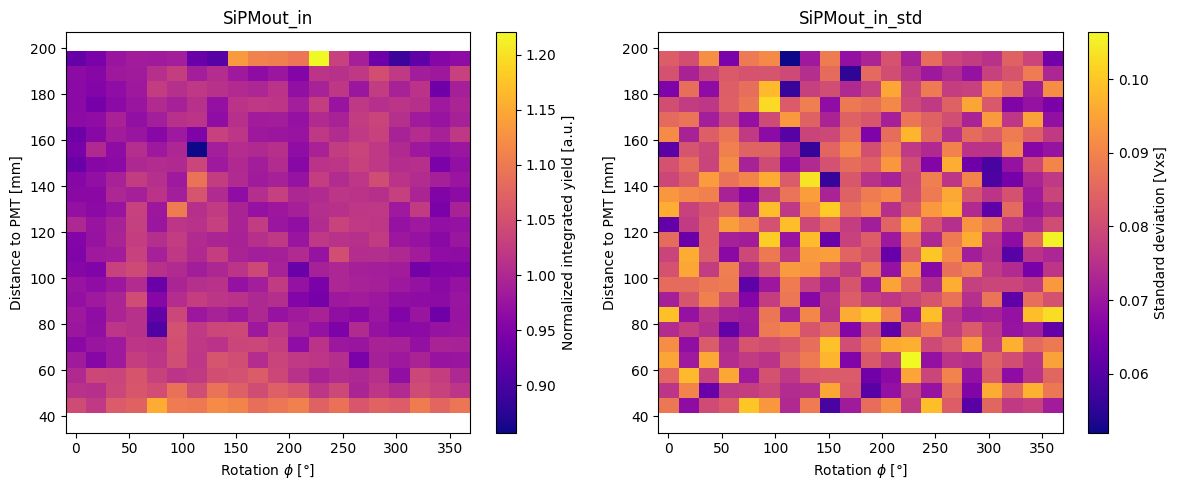

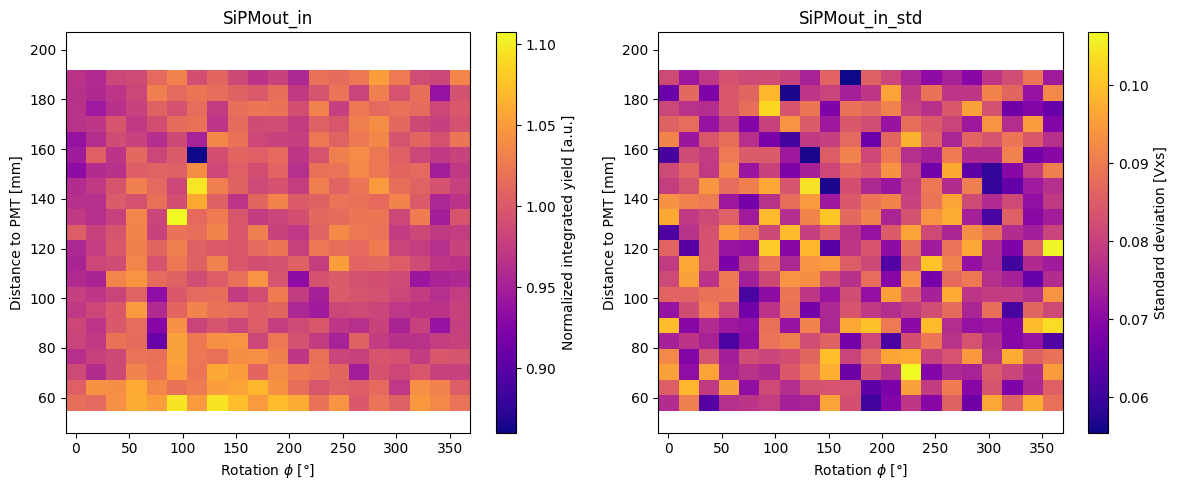

0

In [ ]:
#If you want to cut out rows - put remove_rows = [how many rows to cut in the beginning, how many rows to cut in the end]
qc11.heatmap_WOM(ch1="SiPMout_in", ch2="SiPMout_in_std", baseline_subtract = False, remove_rows = [0,0], normalize = True) #no rows removed
qc11.heatmap_WOM(ch1="SiPMout_in", ch2="SiPMout_in_std", baseline_subtract = False, remove_rows = [1,1], normalize = True) #first and last row removed
qc11.heatmap_WOM(ch1="SiPMout_in", ch2="SiPMout_in_std", baseline_subtract = False, remove_rows = [2,2], normalize = True) #first two and last two rows removed

### Thoughts on LED to PMT distance
- 6.55 mm ist die Innere LED weiter oben als die äusere
Die äußere is 7.1 + 4.3/2 = 9.25 mm von dem oberen Rand des PCBs entfernt
+ 6 mm Abstand zum PMT
Die äußere ist also 15.25mm vom PMT entfehrt in der untersten position und die innere 21.8
wir starten bei position 101 und enden bei 281 - 180 mm 
Start bei außen 195.25mm Abstand, innen 201.8 mm Abstand - sind wir so genau Nein
also 195mm und 202 mm abstand - 16 schritte - 16 cm 
wir enden bei 35mm und 42mm 
wir Könnten noch 2 cm tiefer - ni =19

In [20]:
qc.baseline_integrated_data_eventwise["PMT_in"]

array([[[1.29239766e-08],
        [1.31704256e-08],
        [1.34461153e-08],
        ...,
        [1.33959901e-08],
        [1.37092728e-08],
        [1.32205518e-08]],

       [[2.10944027e-08],
        [2.08395985e-08],
        [2.12197158e-08],
        ...,
        [2.11779447e-08],
        [2.11445279e-08],
        [2.10317452e-08]],

       [[2.15121130e-08],
        [2.11528821e-08],
        [2.13993321e-08],
        ...,
        [2.14578115e-08],
        [2.13366746e-08],
        [2.17752714e-08]],

       ...,

       [[2.38972433e-08],
        [2.47284877e-08],
        [2.43567246e-08],
        ...,
        [2.45405172e-08],
        [2.47034251e-08],
        [2.40267344e-08]],

       [[2.35881377e-08],
        [2.34920634e-08],
        [2.34753550e-08],
        ...,
        [2.33040929e-08],
        [2.39974938e-08],
        [2.35588971e-08]],

       [[2.15162910e-08],
        [2.13784457e-08],
        [2.17418545e-08],
        ...,
        [2.22472849e-08],
        [2.1837

### Looking at the correlation between the measurements in SiPMs and PMT for each event - shows that a swich to an eventwise analysis makes sense

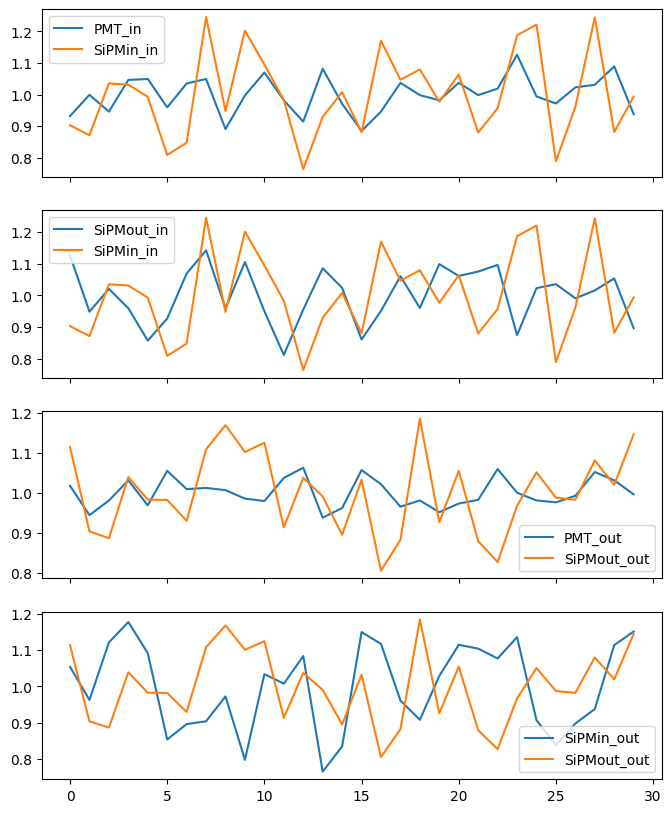

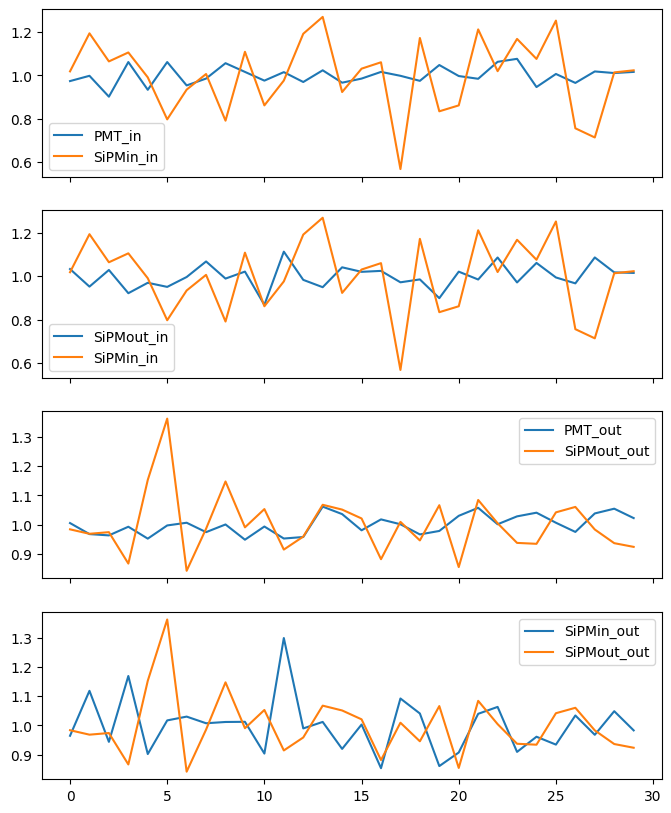

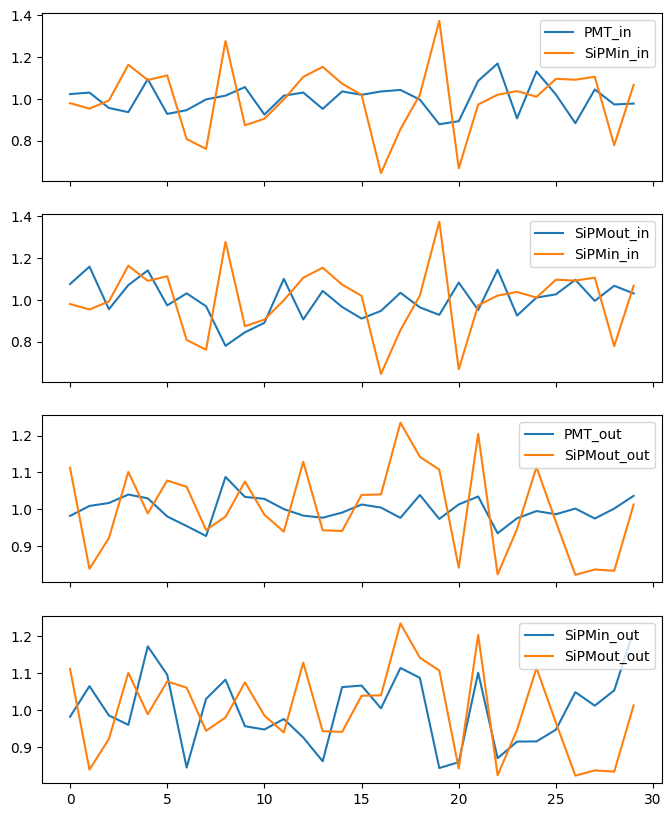

In [ ]:
qcs = [qc1, qc2, qc3] 
label = ["PMT_in",
        "SiPMout_in",
        "PMT_out",
        "SiPMin_out"]
label_ref = ["SiPMin_in",
        "SiPMin_in",
        "SiPMout_out",
        "SiPMout_out"]
#PM_int, REF_int 

for qc in qcs:
    fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(8, 10),
    sharex=True
    )
    for i in range(len(label)):
        pmt_int = qc.baseline_integrated_data_eventwise[label[i]][0]
        ref_int = qc.baseline_integrated_data_eventwise[label_ref[i]][0]
        axes[i].plot(pmt_int/np.mean(pmt_int), label = label[i])
        axes[i].plot(ref_int/np.mean(ref_int), label = label_ref[i])
        axes[i].legend()
    plt.show() 

#### Needed for the old positionwise Error calculation  - now eventwise calculation - only std relevant 
- Following functions were only interesting for the positionwise calculations


In [ ]:
def division_with_error(a, b, a_err, b_err):
    """
    Calculate the division of two arrays and propagate errors.
    Error propagation assumes independent uncertainties:
        sigma = |a/b| * sqrt((a_err/a)^2 + (b_err/b)^2)
    Takes:
        a : array-like, Numerator values
        b : array-like, Denominator values
        a_err : array-like, Errors of numerator values
        b_err : array-like, Errors of denominator values
    Returns:
        ratio : np.ndarray, Element-wise ratio (a / b)
        ratio_err : np.ndarray, Propagated element-wise error
    """
    a = np.array(a)
    b = np.array(b)
    a_err = np.array(a_err)
    b_err = np.array(b_err)
    ratio = a / b
    ratio_err = np.abs(ratio) * np.sqrt(
        (a_err / a)**2 +
        (b_err / b)**2
    )

    return ratio, ratio_err

def weighted_mean(values, errors):
    """
    Calculate weighted mean and its uncertainty.
    Uses inverse-variance weighting:
        w_i = 1 / sigma_i^2
    Takes:
        values : array-like
            Measured values
        errors : array-like
            Uncertainties of values
    Returns:
        mean_w : float
            Weighted mean

        mean_w_err : float
            Uncertainty of weighted mean
    """
    values = np.asarray(values)
    errors = np.asarray(errors)

    weights = 1 / errors**2
    mean_w = np.sum(weights * values) / np.sum(weights)
    mean_w_err = np.sqrt(1 / np.sum(weights))

    return mean_w, mean_w_err

def mean_with_error(values):
    values = np.asarray(values)

    mean = np.mean(values)
    err = np.std(values, ddof=1)#/ np.sqrt(len(values))

    return mean, err


In [ ]:
qcs = [qc1, qc2, qc3, qc11, qc16, qc7, qcthin] 
PM = ["PMT_in", "SiPMout_in", "PMT_out", "SiPMin_out"]
PM_err = ["PMT_in_std", "SiPMout_in_std", "PMT_out_std", "SiPMin_out_std"]
REF = ["SiPMin_in", "SiPMin_in", "SiPMout_out", "SiPMout_out"] 
REF_err = ["SiPMin_in_std", "SiPMin_in_std", "SiPMout_out_std", "SiPMout_out_std"]

for qc in qcs:
    for pm, pm_err, ref, ref_err in zip(PM, PM_err, REF, REF_err):    
        ratio, ratio_err = division_with_error(
            qc.integrated_data[pm],
            qc.integrated_data[ref],
            qc.integrated_data[pm_err]/np.sqrt(30),
            qc.integrated_data[ref_err]/np.sqrt(30)
        )
        ratio_mean, ratio_mean_err = mean_with_error(ratio)# weighted_mean(
        #    ratio,
        #    ratio_err
        #)
        ratio_norm = ratio / ratio_mean
        ratio_norm_err = np.abs(ratio_norm) * np.sqrt(
            (ratio_err / ratio)**2 +
            (ratio_mean_err / ratio_mean)**2
        )
        name = f"{pm}_ref"
        qc.integrated_data[name] = ratio
        qc.integrated_data[name + "_err"] = ratio_err
        qc.integrated_data[name+ "_norm"] = ratio_norm
        qc.integrated_data[name + "_norm_err"] = ratio_norm_err

### Comparing the old position wise with the new eventwise calulation

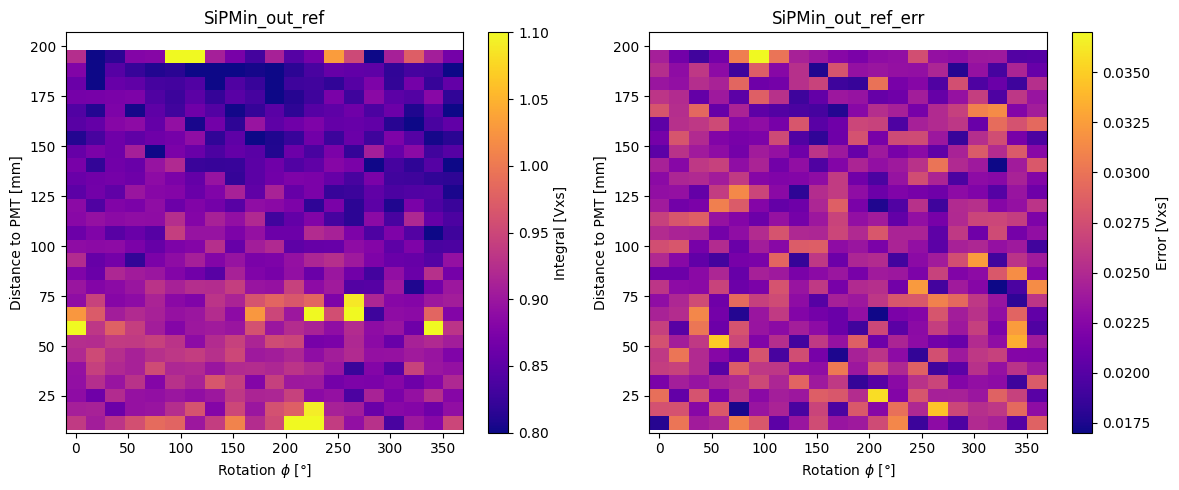

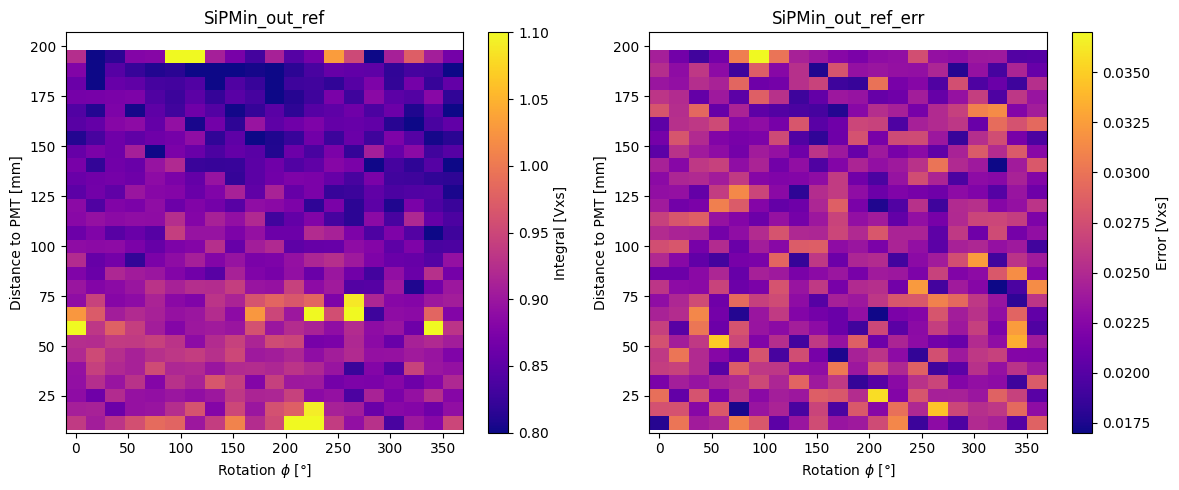

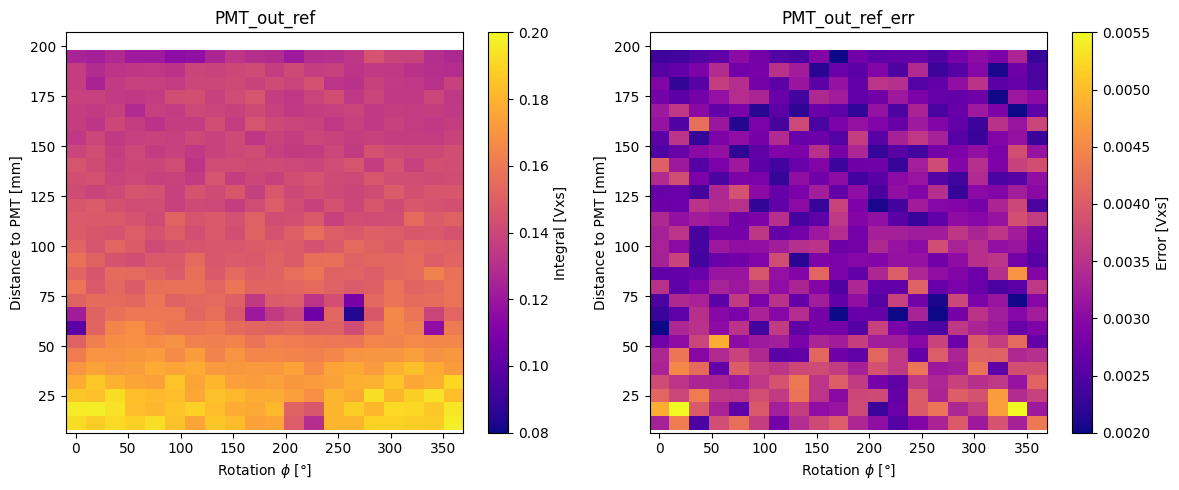

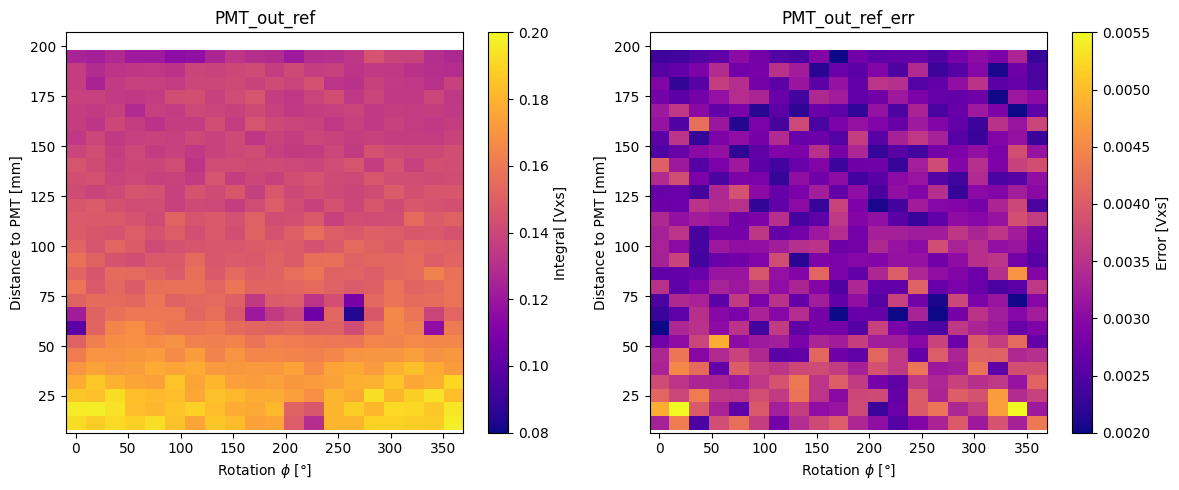

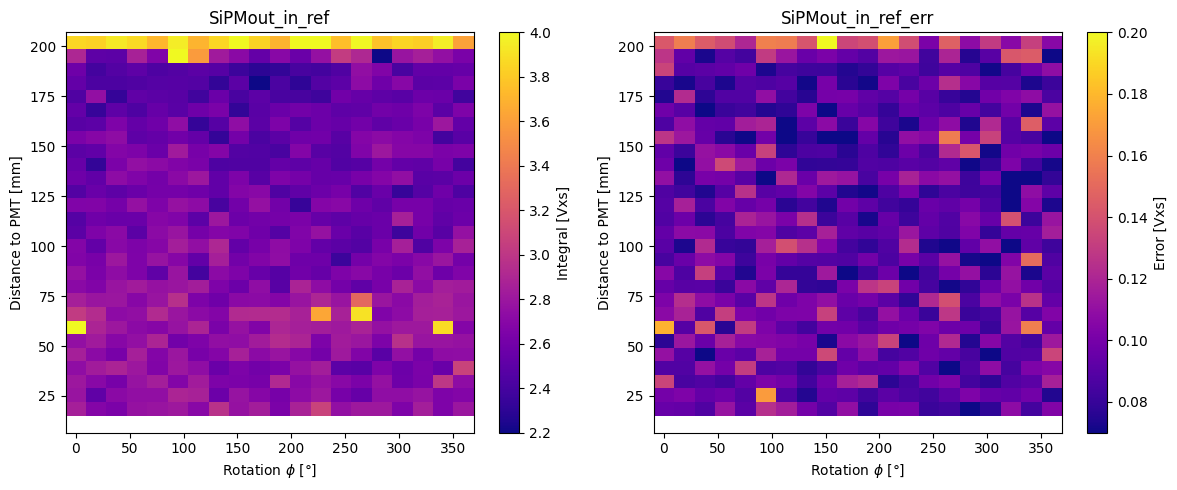

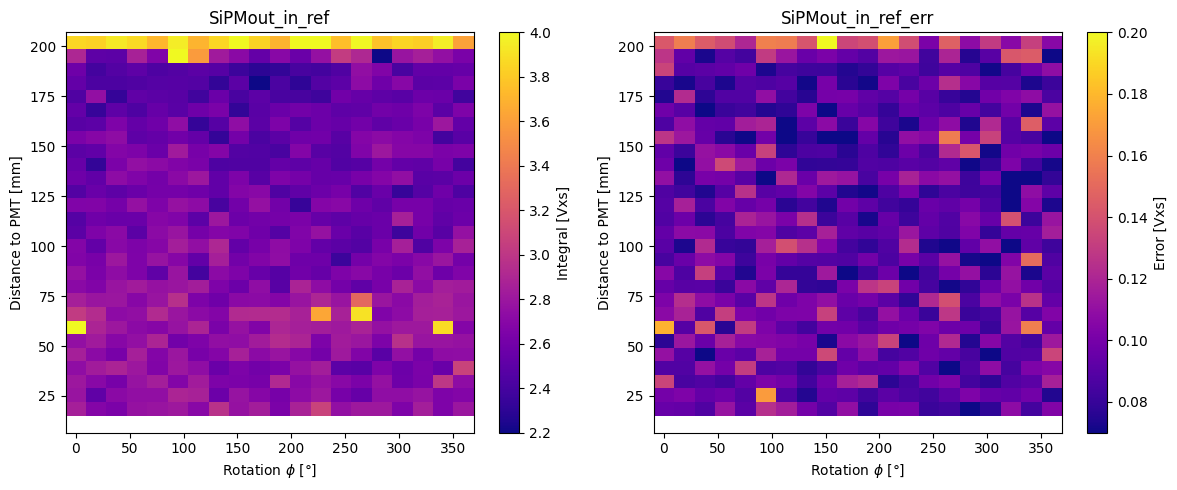

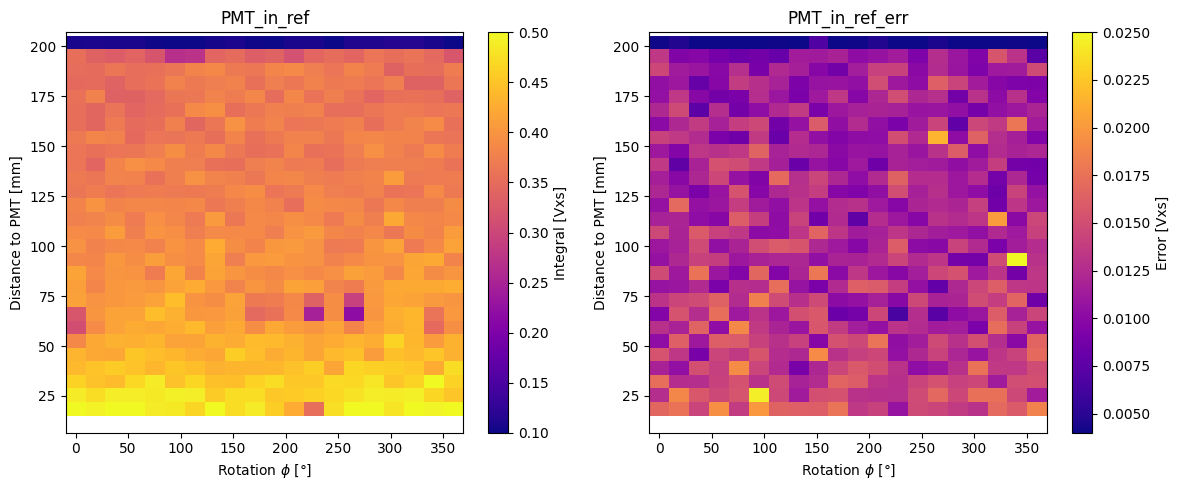

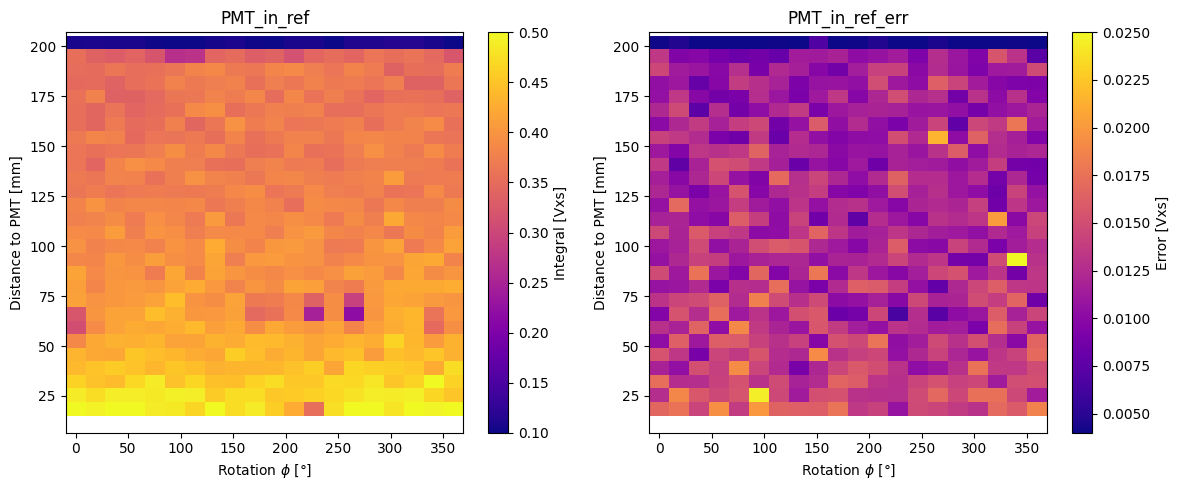

0

In [ ]:
qc2.baseline_integrated_data["SiPMin_out_ref_err"] = qc2.baseline_integrated_data["SiPMin_out_ref_std"]/np.sqrt(qc2.rep)
qc2.baseline_integrated_data["PMT_out_ref_err"] = qc2.baseline_integrated_data["PMT_out_ref_std"]/np.sqrt(qc2.rep)
qc2.baseline_integrated_data["SiPMout_in_ref_err"] = qc2.baseline_integrated_data["SiPMout_in_ref_std"]/np.sqrt(qc2.rep)
qc2.baseline_integrated_data["PMT_in_ref_err"] = qc2.baseline_integrated_data["PMT_in_ref_std"]/np.sqrt(qc2.rep)

qc2.heatmap_WOM(ch1="SiPMin_out_ref", ch2="SiPMin_out_ref_err", step_size = 6.55, vmin = [0.8, 0.017], vmax = [1.1, 0.037])
qc2.heatmap_WOM(ch1="SiPMin_out_ref", ch2="SiPMin_out_ref_err", step_size = 6.55, baseline_subtract = True, vmin = [0.8, 0.017], vmax = [1.1, 0.037])

qc2.heatmap_WOM(ch1="PMT_out_ref", ch2="PMT_out_ref_err", step_size = 6.55, vmin = [0.08, 0.002], vmax = [0.2, 0.0055])
qc2.heatmap_WOM(ch1="PMT_out_ref", ch2="PMT_out_ref_err", step_size = 6.55, baseline_subtract = True, vmin = [0.08, 0.002], vmax = [0.2, 0.0055])

qc2.heatmap_WOM(ch1="SiPMout_in_ref", ch2="SiPMout_in_ref_err", step_size = 6.55, vmin = [2.2, 0.07], vmax = [4, 0.2])
qc2.heatmap_WOM(ch1="SiPMout_in_ref", ch2="SiPMout_in_ref_err", step_size = 6.55, baseline_subtract = True, vmin = [2.2, 0.07], vmax = [4, 0.2])

qc2.heatmap_WOM(ch1="PMT_in_ref", ch2="PMT_in_ref_err", step_size = 6.55,  vmin = [0.1, 0.004], vmax = [0.5, 0.025])
qc2.heatmap_WOM(ch1="PMT_in_ref", ch2="PMT_in_ref_err", step_size = 6.55, baseline_subtract = True, vmin = [0.1, 0.004], vmax = [0.5, 0.025])

#, vmin = [0.85, 0.85], vmax = [1.2, 1.2], baseline_subtract = False)

### Calculating the overall light yield to get one number per WOM

In [ ]:
#WOM 7 shows the best performance. If we define the performance of WOM 7 as 100%
QC = [qc11, qc16, qc7, qcthin] 
labels = ["WOM 11", "WOM 16", "WOM 7", "WOM thin coating"]
PM_REF = [f"{pm}_ref" for pm in PM]
a = 0

for pm in PM_REF:
    norm = (np.mean(qc7.baseline_integrated_data[pm]) + np.mean(qc7.baseline_integrated_data[pm])) / 2
    for qc in QC:
        mean = (np.mean(qc.baseline_integrated_data[pm]) + np.mean(qc.baseline_integrated_data[pm])) / 2/norm
        std = 1/np.sqrt(2)*np.sqrt((np.std(qc.baseline_integrated_data[pm], ddof=1)/np.sqrt(len(qc.baseline_integrated_data[pm])))**2 + (np.std(qc.baseline_integrated_data[pm], ddof=1)/np.sqrt(len(qc.baseline_integrated_data[pm])))**2)/norm
        print(labels[QC.index(qc)], "", pm," ", mean*100, "% +- ", std*100, "%")
    print("\n")    

WOM 11  PMT_in_ref   106.71306 % +-  0.39715533023018285 %
WOM 16  PMT_in_ref   100.94731 % +-  0.34993701620599516 %
WOM 7  PMT_in_ref   100.0 % +-  0.31623518703525183 %
WOM thin coating  PMT_in_ref   59.25777 % +-  0.3482049534732931 %


WOM 11  SiPMout_in_ref   119.93497 % +-  0.3666699526900338 %
WOM 16  SiPMout_in_ref   103.66684 % +-  0.5044821476079766 %
WOM 7  SiPMout_in_ref   100.0 % +-  0.5576756928454568 %
WOM thin coating  SiPMout_in_ref   131.28523 % +-  0.4106856890550639 %


WOM 11  PMT_out_ref   103.16671 % +-  0.47001803471680137 %
WOM 16  PMT_out_ref   100.955986 % +-  0.2796123911628703 %
WOM 7  PMT_out_ref   100.0 % +-  0.39575856418175726 %
WOM thin coating  PMT_out_ref   64.40714 % +-  0.26360818885605175 %


WOM 11  SiPMin_out_ref   114.90044 % +-  0.3543210947890099 %
WOM 16  SiPMin_out_ref   101.65465 % +-  0.4725140539881203 %
WOM 7  SiPMin_out_ref   100.0 % +-  0.5843623522814066 %
WOM thin coating  SiPMin_out_ref   134.69246 % +-  0.24892688546122652 %




In [ ]:
#WOM 7 shows the best performance. If we define the performance of WOM 7 as 100%
QC = [qc11, qc11_2, qc11_3, qc16, qc16_2, qc7, qc7_2, qc7_3, qcthin] 
labels = ["WOM 11","WOM 11_2","WOM 11_3", "WOM 16","WOM 16_2", "WOM 7","WOM 7_2","WOM 7_3", "WOM thin coating"]
PM_in = ["PMT_in_ref", "SiPMout_in_ref"]
PM_out = ["PMT_out_ref", "SiPMin_out_ref"]


for pm_in, pm_out in zip(PM_in, PM_out):
    norm = (np.mean(qc7.baseline_integrated_data[pm_in]) + np.mean(qc7.baseline_integrated_data[pm_out])) / 2
    for qc in QC:
        mean = (np.mean(qc.baseline_integrated_data[pm_in]) + np.mean(qc.baseline_integrated_data[pm_out]))/ 2/norm
        std = 1/np.sqrt(2)*np.sqrt((np.std(qc.baseline_integrated_data[pm_in], ddof=1)/np.sqrt(len(qc.baseline_integrated_data[pm])))**2 + (np.std(qc.baseline_integrated_data[pm_in], ddof=1)/np.sqrt(len(qc.baseline_integrated_data[pm_out])))**2)/norm
        print(labels[QC.index(qc)], "", pm_in,"+", pm_out, " ", mean*100, "% +- ", std*100, "%")
    print("\n") 

WOM 11  PMT_in_ref + PMT_out_ref   105.05651 % +-  0.4232770271899372 %
WOM 11_2  PMT_in_ref + PMT_out_ref   98.505905 % +-  0.39902920486073234 %
WOM 11_3  PMT_in_ref + PMT_out_ref   101.57908 % +-  0.42437501158915814 %
WOM 16  PMT_in_ref + PMT_out_ref   100.95137 % +-  0.37295307062237615 %
WOM 16_2  PMT_in_ref + PMT_out_ref   102.35878 % +-  0.38365706136504546 %
WOM 7  PMT_in_ref + PMT_out_ref   100.0 % +-  0.3370346050336416 %
WOM 7_2  PMT_in_ref + PMT_out_ref   107.75178 % +-  0.33840333577821863 %
WOM 7_3  PMT_in_ref + PMT_out_ref   112.106895 % +-  0.35030105532056827 %
WOM thin coating  PMT_in_ref + PMT_out_ref   61.663116 % +-  0.37110708667453474 %


WOM 11  SiPMout_in_ref + SiPMin_out_ref   117.76123 % +-  0.4167071134999156 %
WOM 11_2  SiPMout_in_ref + SiPMin_out_ref   116.846016 % +-  0.4131643496931369 %
WOM 11_3  SiPMout_in_ref + SiPMin_out_ref   116.8489 % +-  0.4004672541651874 %
WOM 16  SiPMout_in_ref + SiPMin_out_ref   102.79804 % +-  0.5733256788555834 %
WOM 16_2 

### Comparing different WOMs in 2D plots with the distance to PMT or the angle on the x-axis

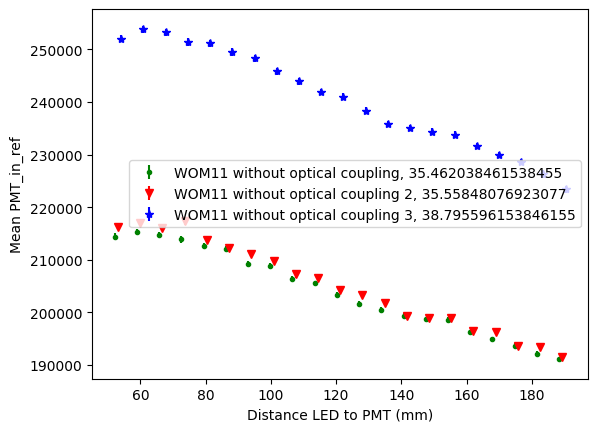

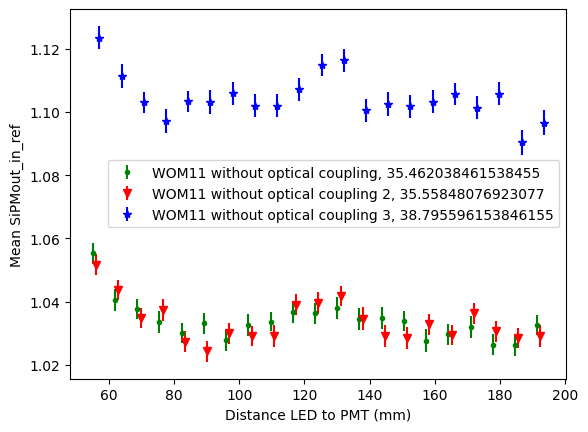

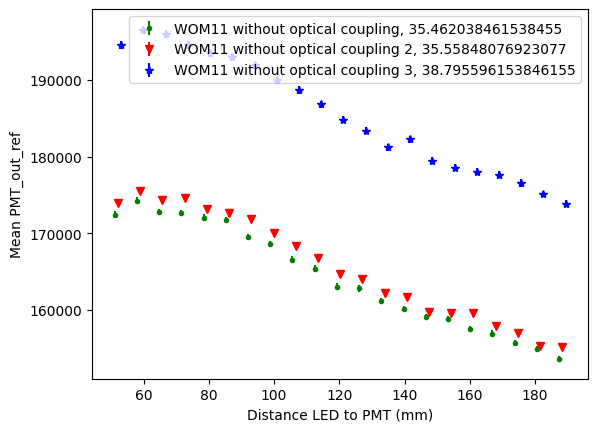

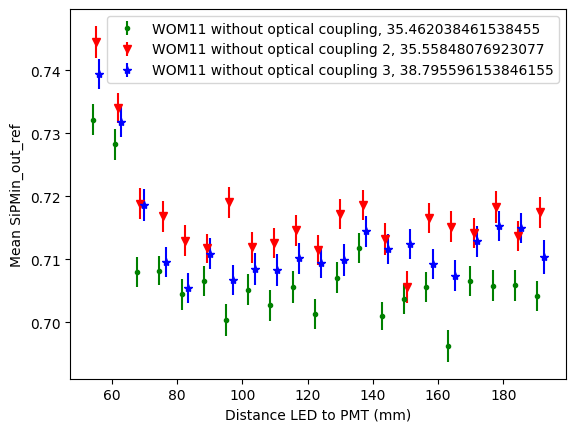

In [150]:
QC = [qc11_wo1, qc11_wo2, qc11_wo3]#[qc11, qc11_2, qc11_3, qc11_wo, qc6, qc16, qc16_2, qc7, qc7_2, qc7_3]#,qc0, qc90, qc180, qc270]# qcthin]#, qc1, qc2, qc3] qc11, qc11_2, WOM 11", "WOM 11 2", 
labels = ["WOM11 without optical coupling","WOM11 without optical coupling 2", "WOM11 without optical coupling 3"]#["WOM 11 0degrees", "WOM 11 90degrees", "WOM 11 180degrees","WOM 11 270degrees"]#["WOM11", "WOM11 2", "WOM11 3", "WOM11 wo optical coupling", "WOM 6", "WOM 16","WOM 16 2", "WOM 7" ,"WOM 7 2","WOM 7 3", "WOM thin coating", "Bleached WOM 1", "Bleached WOM 2", "Bleached WOM 3"]
PM_ref = ["PMT_in_ref", "SiPMout_in_ref", "PMT_out_ref", "SiPMin_out_ref"]#["PMT_in", "SiPMout_in", "SiPMin_in", "PMT_out", "SiPMin_out", "SiPMout_out"]#

colors = ["green", "red", "blue", "orange"]  #"darkgreen", "green", "pink",darkblue", "orange", "darkorange", "brown"]
marks = [".", "v", "*", ".", ".", ".", "v", ".", "v", "*"]

a = 0

group_col="i"

for pm in PM_ref:
    for qc in QC:
        x, groups, mean, std, err = qc.grouped_mean_std(
            value_col=pm,
            group_col=group_col,
        )
        plt.errorbar(x[2:-3]+a, mean[2:-3], yerr=err[2:-3], fmt= marks[QC.index(qc)], color = colors[QC.index(qc)],label=f"{labels[QC.index(qc)]}, {np.mean(qc.integrated_data["temp_out"])}")
        a += 1
    plt.legend() 
    if group_col == "i":
        plt.xlabel("Distance LED to PMT (mm)")
    else:        
        plt.xlabel(r"Rotation $\phi$ [°]")
    plt.ylabel(f"Mean {pm}")# normalized to reference [a.u.]
    plt.show()

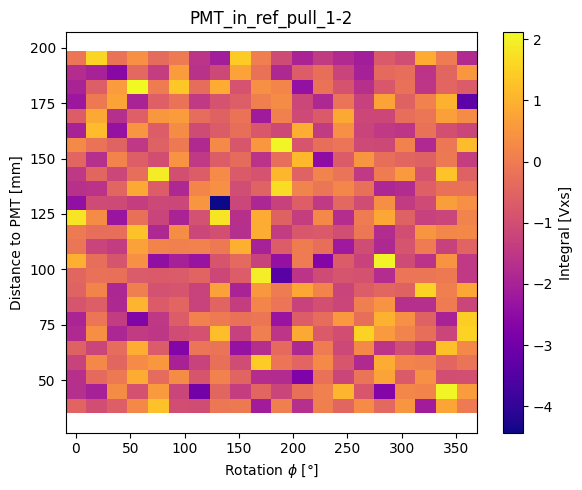

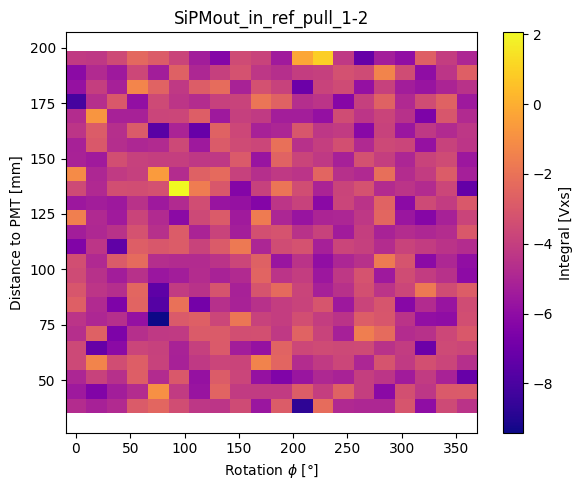

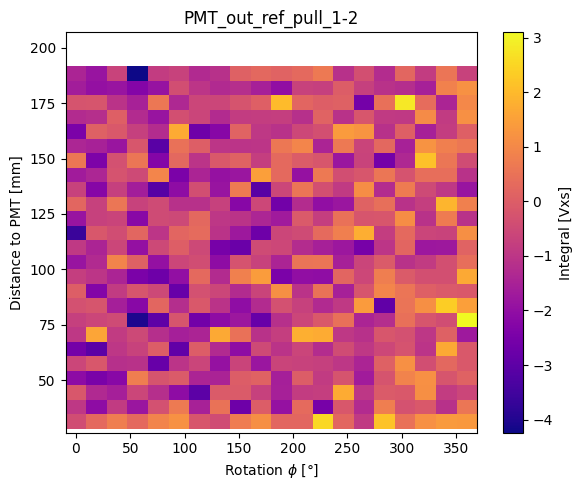

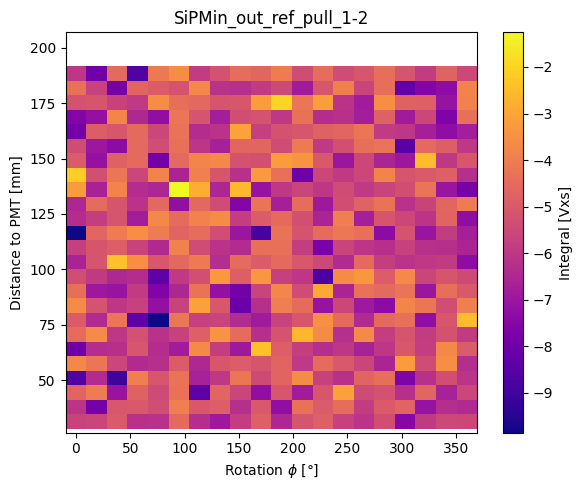

In [ ]:
for pm_pull in PM_PUll:
    qc11.heatmap_WOM(ch1= pm_pull , step_size = 6.55, remove_rows = [1,0])#, vmin = [-4], vmax = [4]) 

### Calculating the difference between measurements

In [ ]:
PM_REF = [f"{pm}_ref" for pm in PM]
PM_REF_ERR = [f"{pm}_ref_err" for pm in PM]
qcs1 = [qc1, qc1, qc2]
qcs2 = [qc2, qc3, qc3]
qcnames = ["1-2", "1-3", "2-3"]

for i in range(len(qcs1)):
    qc = qcs1[i]
    q = qcs2[i]
    for pm_ref, pm_ref_err in zip(PM_REF, PM_REF_ERR):
            qc1.baseline_integrated_data[pm_ref + "_" + qcnames[i]] = qc.baseline_integrated_data[pm_ref] - q.baseline_integrated_data[pm_ref]
            qc1.baseline_integrated_data[pm_ref_err + "_" + qcnames[i]] = np.sqrt((qc.baseline_integrated_data[pm_ref + "_std"]/np.sqrt(qc.rep))**2 + (q.baseline_integrated_data[pm_ref + "_std"]/np.sqrt(qc.rep))**2)

In [ ]:
PM_REF = [f"{pm}_ref" for pm in PM]
PM_REF_ERR = [f"{pm}_ref_err" for pm in PM]
qcs1 = [qc11, qc11, qc16]
qcs2 = [qc16, qc7, qc7]
qcnames = ["11-16", "11-7", "16-7"]

for i in range(len(qcs1)):
    qc = qcs1[i]
    q = qcs2[i]
    for pm_ref, pm_ref_err in zip(PM_REF, PM_REF_ERR):
            qc11.baseline_integrated_data[pm_ref + "_" + qcnames[i]] = qc.baseline_integrated_data[pm_ref] - q.baseline_integrated_data[pm_ref]
            qc11.baseline_integrated_data[pm_ref_err + "_" + qcnames[i]] = np.sqrt((qc.baseline_integrated_data[pm_ref + "_std"]/np.sqrt(qc.rep))**2 + (q.baseline_integrated_data[pm_ref + "_std"]/np.sqrt(qc.rep))**2)

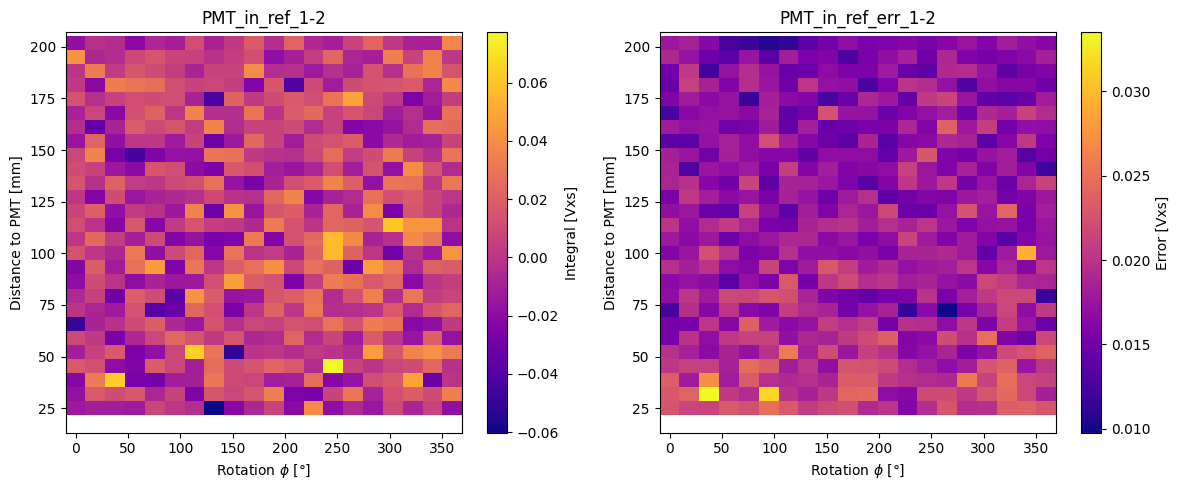

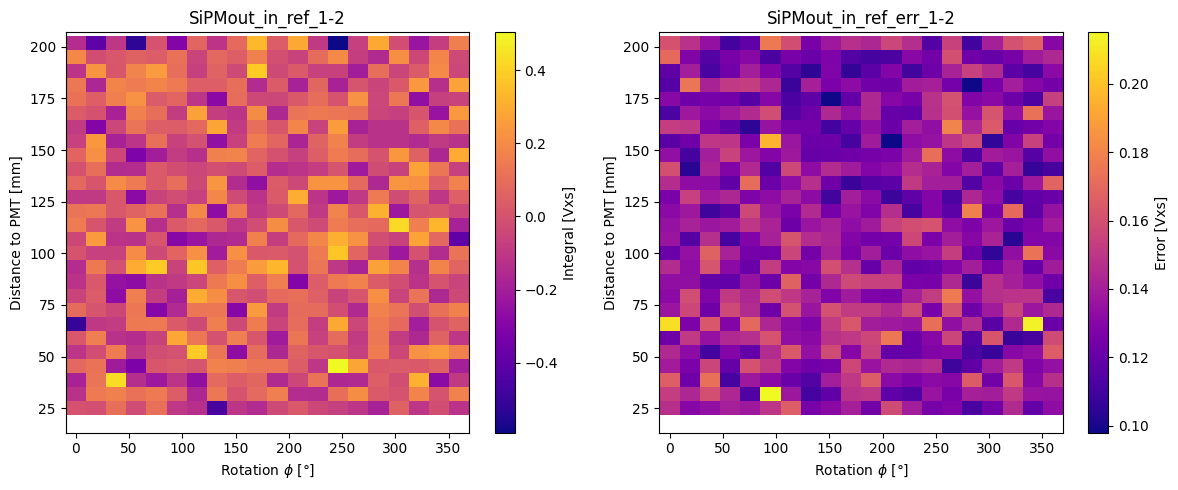

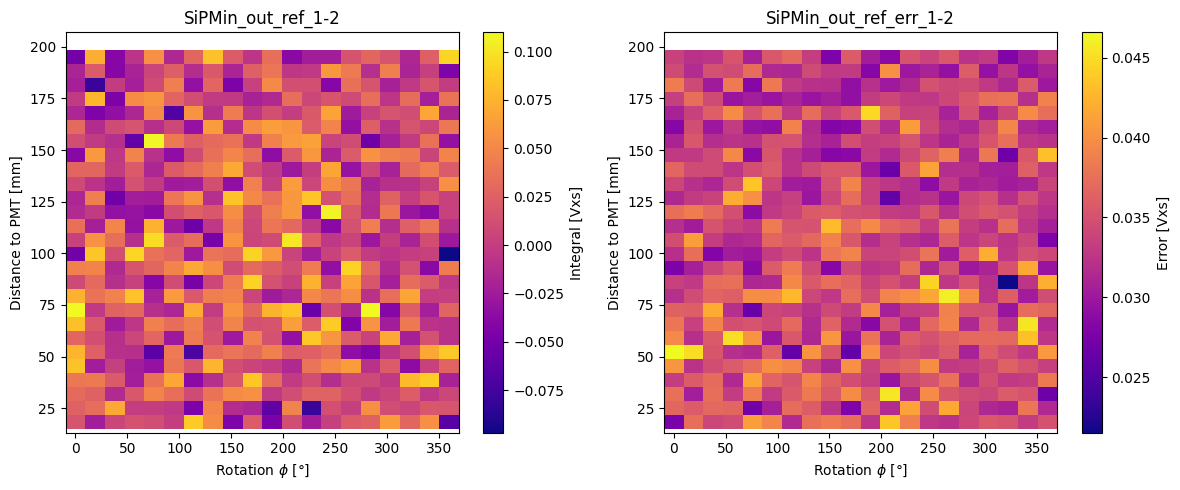

0

In [ ]:
qc1.heatmap_WOM(ch1= "PMT_in_ref_1-2", ch2= "PMT_in_ref_err_1-2" , step_size = 6.55, baseline_subtract=True, remove_rows = [1, 0])#, vmin = [-0.1, -0.1], vmax = [0.1, 0.    
qc1.heatmap_WOM(ch1= "SiPMout_in_ref_1-2", ch2= "SiPMout_in_ref_err_1-2" , step_size = 6.55, baseline_subtract=True, remove_rows = [1, 0])#, vmin = [-0.1, -0.1], vmax = [0.1, 0.    
qc1.heatmap_WOM(ch1= "SiPMin_out_ref_1-2", ch2= "SiPMin_out_ref_err_1-2" , step_size = 6.55, baseline_subtract=True, remove_rows = [1, 0])#, vmin = [-0.1, -0.1], vmax = [0.1, 0.    

### Calulating pull plots to compare the difference between the measurements with their statistical fluctuations

In [ ]:
PM = ["PMT_in", "SiPMout_in", "PMT_out", "SiPMin_out"]
PM_PUll = [f"{pm}_ref_pull_{qcname}" for pm in PM for qcname in qcnames]

for pm_ref in PM_REF:
    for qcname in qcnames:
        qc1.baseline_integrated_data[f"{pm_ref}_pull_{qcname}"] = qc1.baseline_integrated_data[pm_ref + "_1-2"] / qc1.baseline_integrated_data[pm_ref + "_err_1-2"]

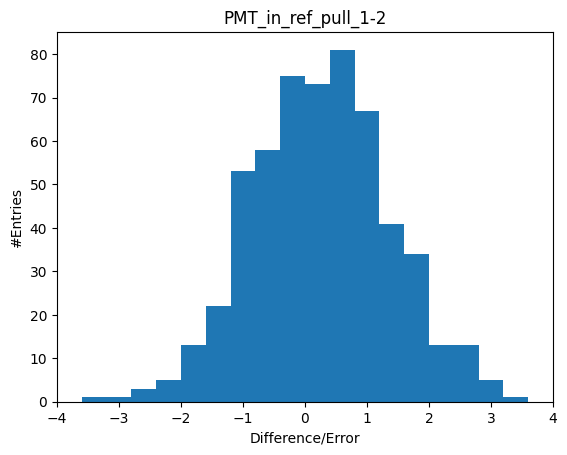

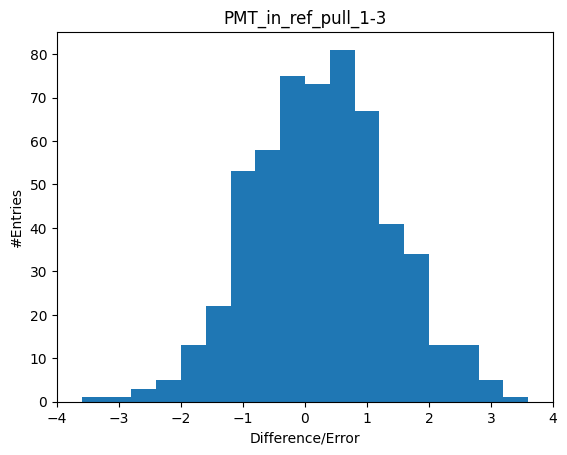

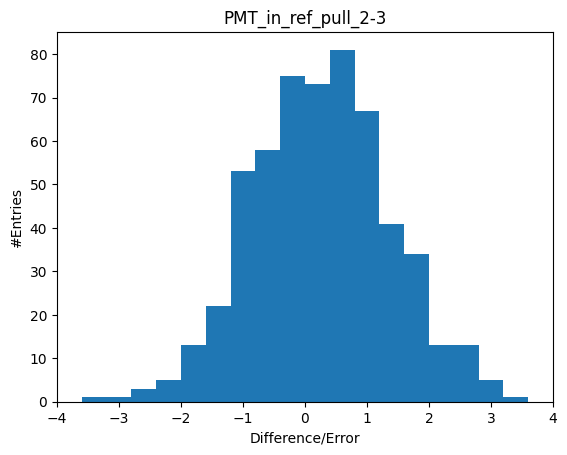

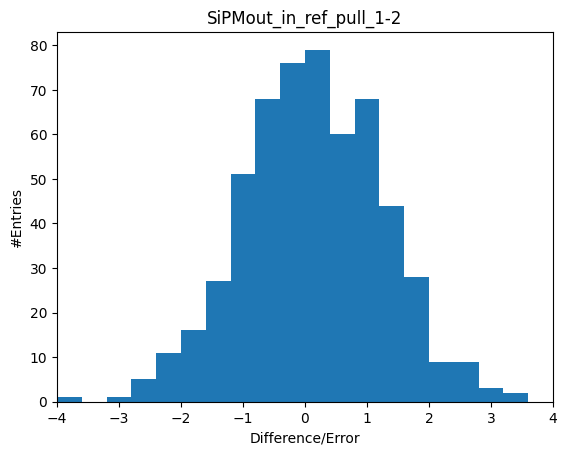

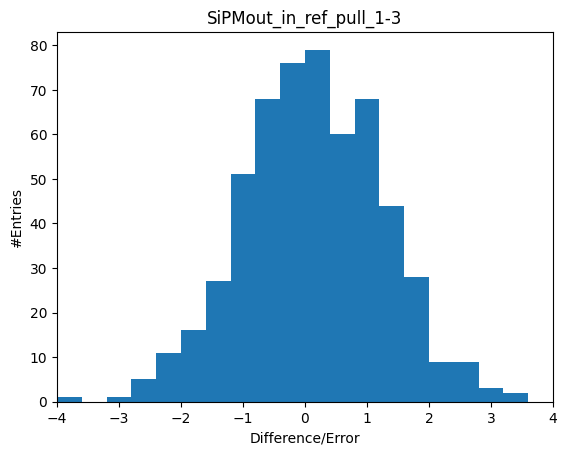

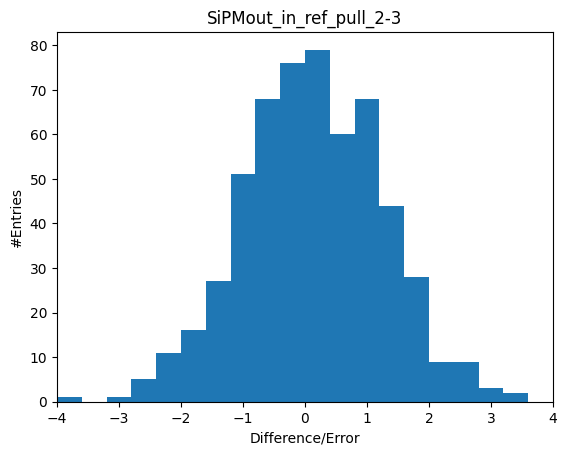

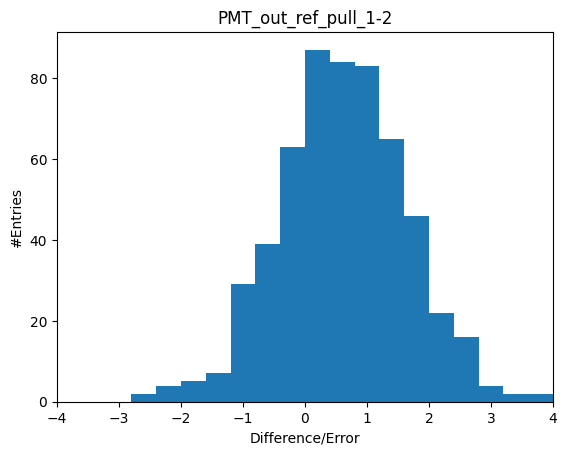

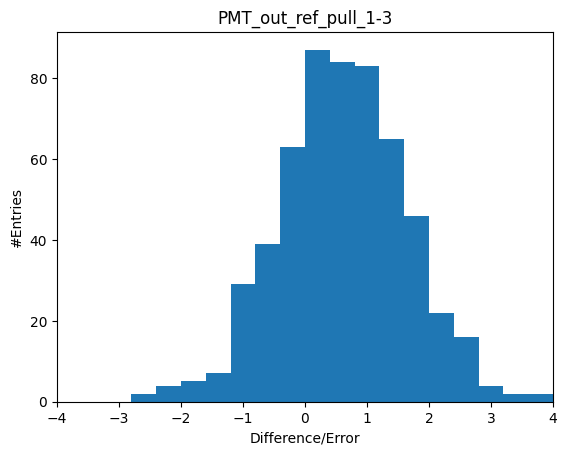

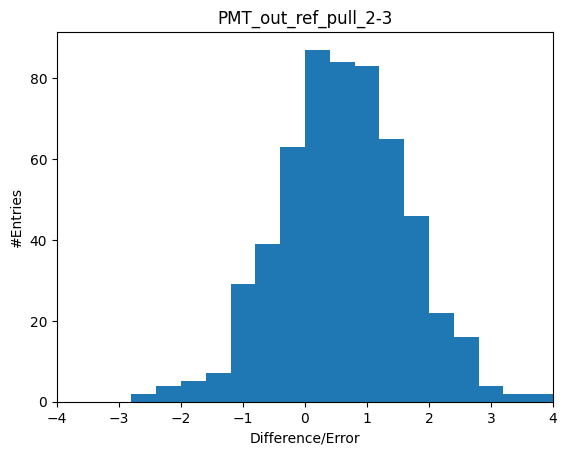

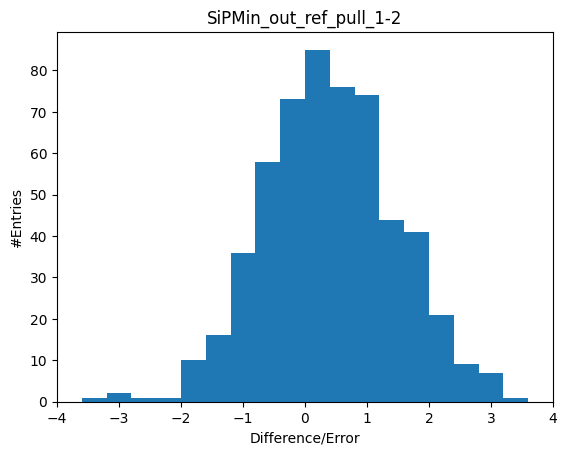

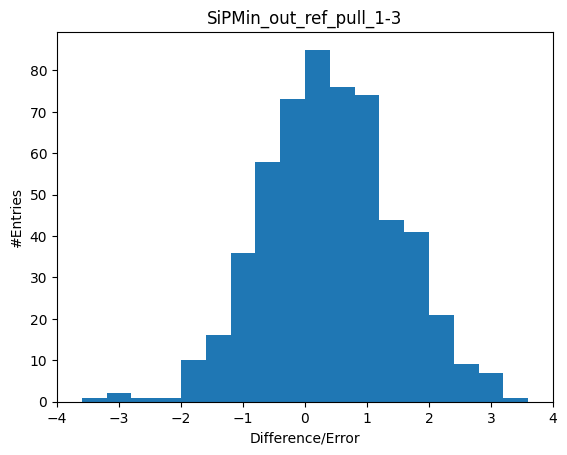

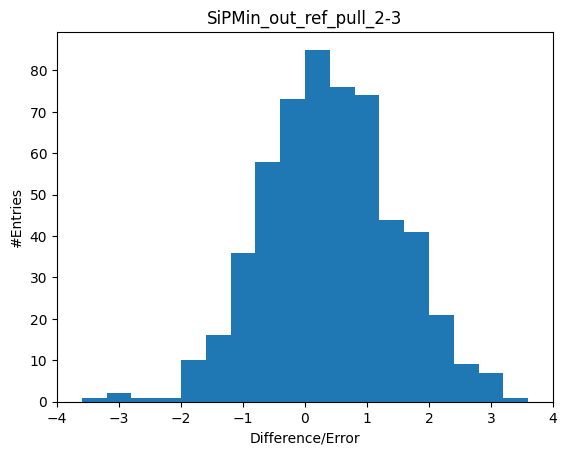

In [ ]:
for pm_pull in PM_PUll:
    #print(qc1.integrated_data[pm_pull])
    plt.hist(qc1.baseline_integrated_data[pm_pull], bins = 20, range=[-4,4])
    plt.title(pm_pull)
    plt.xlabel("Difference/Error")
    plt.xlim(-4,4)
    plt.ylabel("#Entries")
    plt.show()


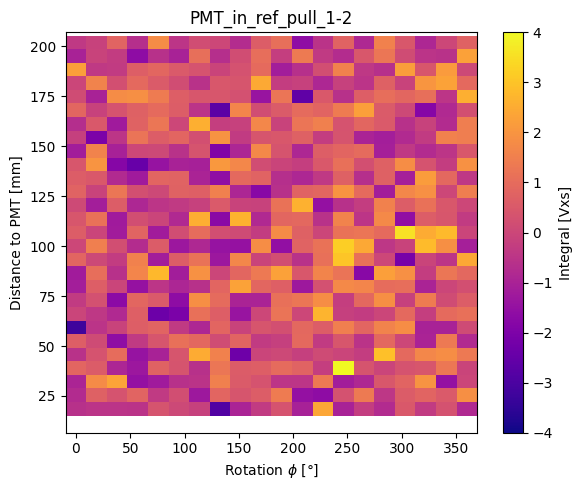

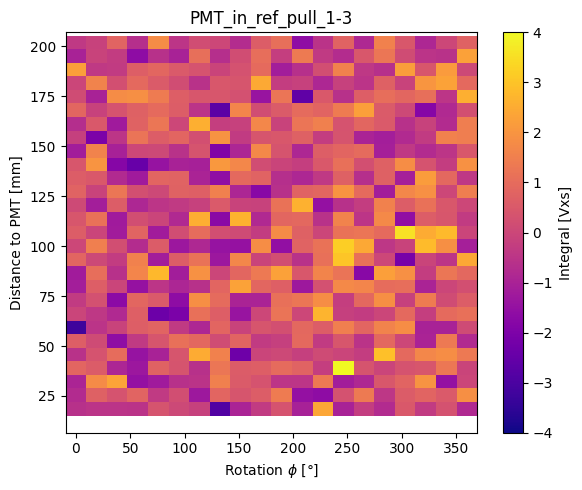

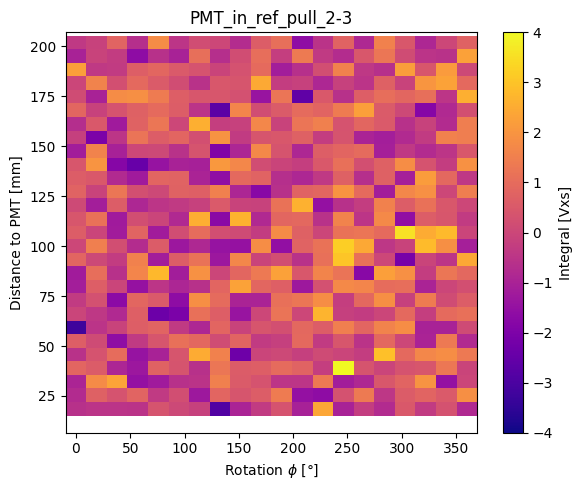

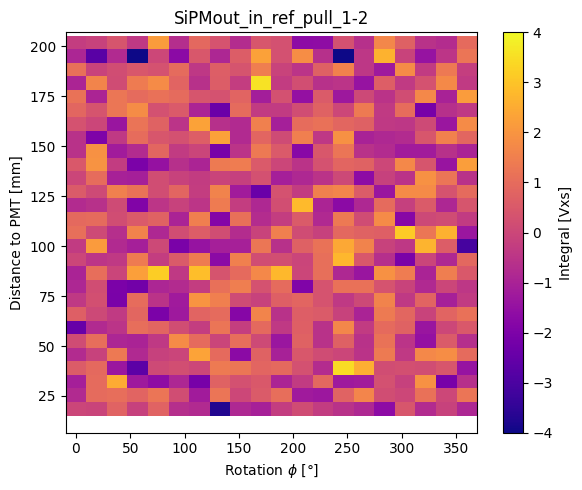

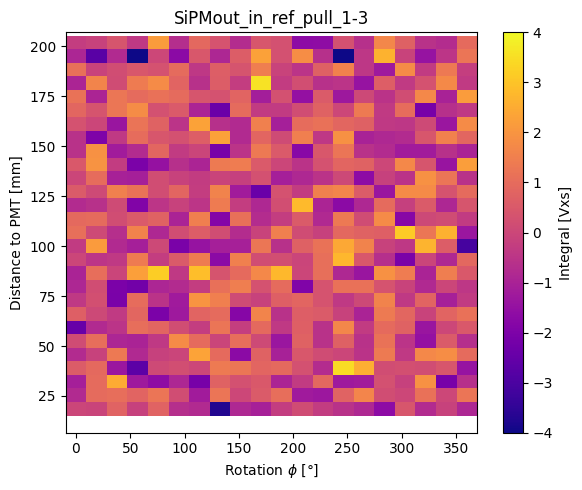

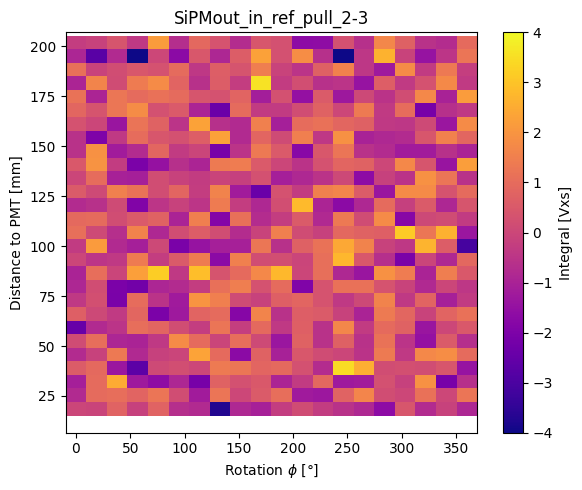

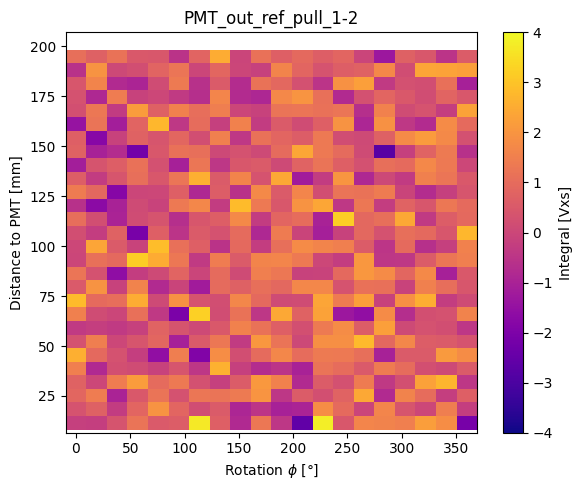

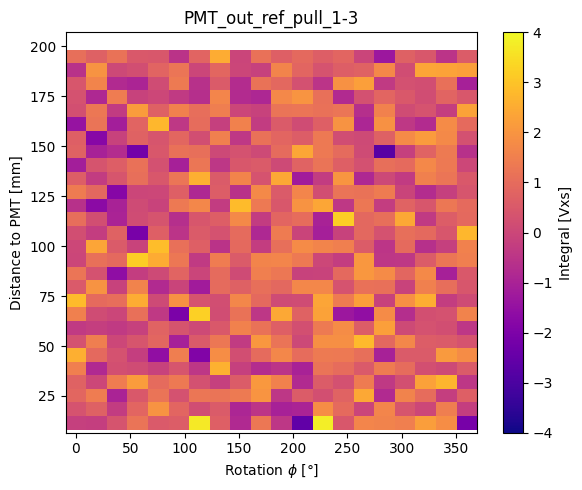

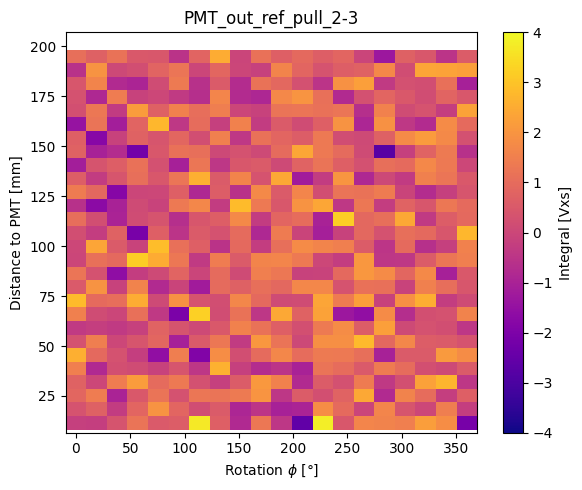

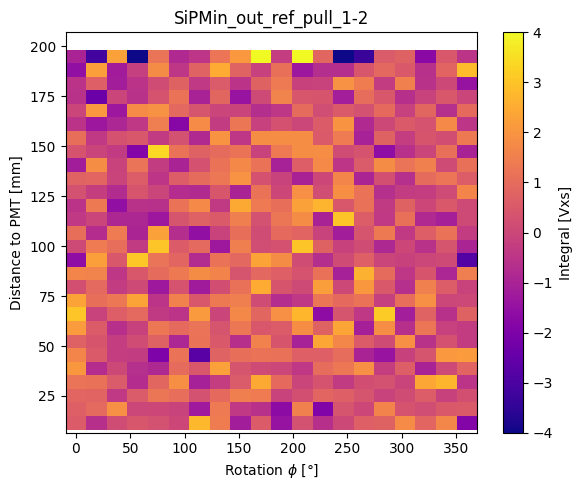

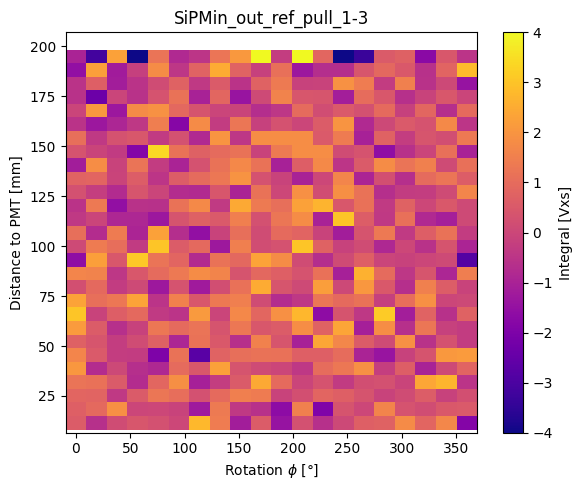

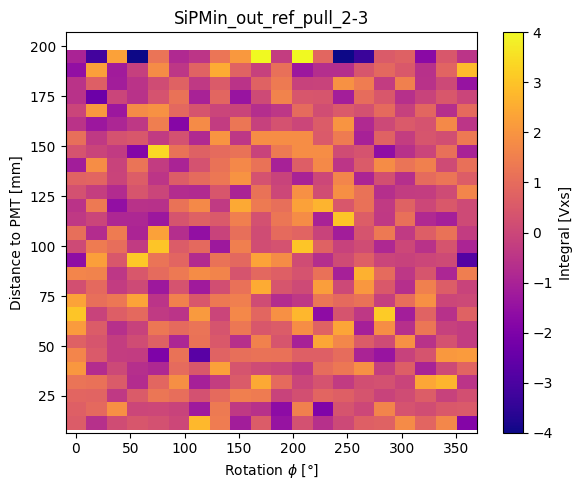

In [ ]:
for pm_pull in PM_PUll:
    qc1.heatmap_WOM(ch1= pm_pull , step_size = 6.55, vmin = [-4], vmax = [4])    
    

# Longterm and darkcount measurements - not yet optimized or pluged into the class. - Importent for the calibration

(399360,) (399360,) (399360,)


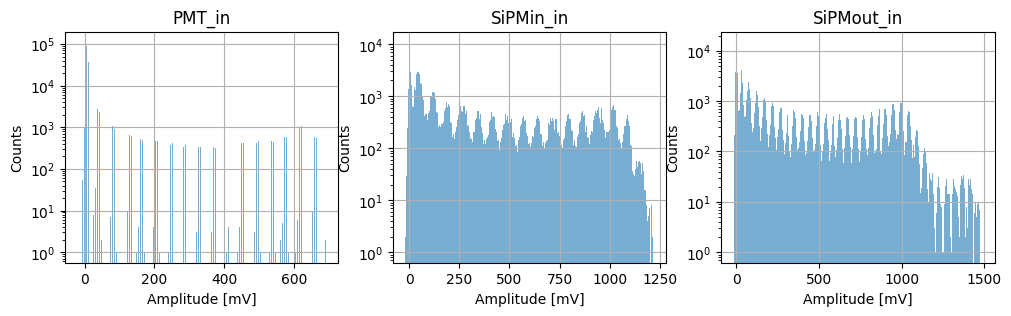

In [130]:
#plt.ylim(0.5,-2)
l = 0
u = qc.ni
window_min = 0
window_max = 512
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
if "SiPM" in pm:
    int_window_min, int_window_max = qc.int_window_min_SiPM, qc.int_window_max_SiPM
else:
    int_window_min, int_window_max = qc.int_window_min_PMT, qc.int_window_max_PMT
PM = ["PMT_in", "SiPMin_in", "SiPMout_in"]
wf_PMT = -np.array(qc.baseline_wf[PM[0]][l:u]).squeeze().flatten()
wf_SiPMin = np.array(qc.baseline_wf[PM[1]][l:u]).squeeze().flatten()
wf_SiPMout = np.array(qc.baseline_wf[PM[2]][l:u]).squeeze().flatten()
print(wf_PMT.shape, wf_SiPMin.shape, wf_SiPMout.shape)


axs[0].hist(wf_PMT*1e3, bins = 1000, alpha=0.6)
axs[1].hist(wf_SiPMin*1e3, bins = 1000, alpha=0.6)
axs[2].hist(wf_SiPMout*1e3, bins = 1000, alpha=0.6)
axs[0].set_yscale("log")
axs[1].set_yscale("log")
axs[2].set_yscale("log")
for i in range(3):
    axs[i].set_xlabel("Amplitude [mV]")
    axs[i].set_ylabel("Counts")
    axs[i].set_title(f"{PM[i]}")
    axs[i].grid(True)


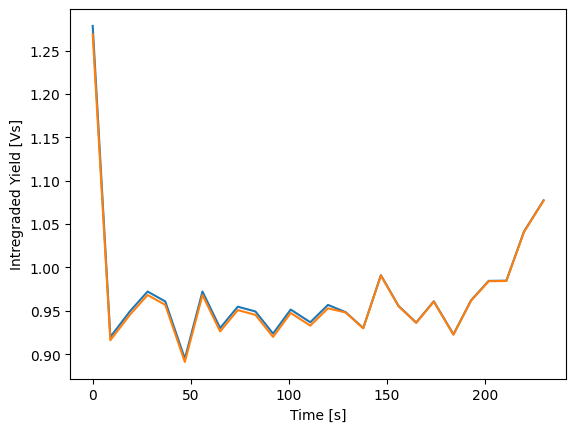

In [131]:
pm = "SiPMout_in"
wf = np.array(qc.baseline_wf[pm]).squeeze()   # shape → (1000, 512)
wf_integrals = [] 
temp_corrected_wfs = []
ref = []

plt.xlabel("Time [s]")
plt.ylabel("Intregraded Yield [Vs]")
#plt.ylim(0.5,-2)
l = 00000 
u = qc.ni#/10

if "SiPM" in pm:
    int_window_min, int_window_max = qc.int_window_min_SiPM, qc.int_window_max_SiPM
else:
    int_window_min, int_window_max = qc.int_window_min_PMT, qc.int_window_max_PMT

if "_in" in pm:
    temp = qc.integrated_data["temp_in"]
    ref = np.array(qc.baseline_wf["SiPMin_in"]).squeeze() 
    
else:
    temp = qc.integrated_data["temp_out"]
    ref = np.array(qc.baseline_wf["SiPMout_out"]).squeeze() 

time0 = datetime.strptime(qc.integrated_data["time"][l], "%H:%M:%S")
prev_t = time0

timearr = [] 
baseline_mean = 0 
wfs = []
refs = []
day = 0


for i, row in enumerate(wf[l:u]):
    i += l 
    # produce time axis
    t = datetime.strptime(qc.integrated_data["time"][i], "%H:%M:%S")

    # detect midnight wrap
    if t < prev_t:
        day += 1

    # compute delta from first timestamp
    delta = (t - time0).total_seconds() + day * 24 * 3600 
    # produce integral over basline corrected waveforms
    waveform = np.array(row)
    ref_waveform = np.array(ref[i])

    amp = np.max(np.abs(waveform))
    amp_ref = np.max(np.abs(ref_waveform))

    if amp > 5e-3 and amp_ref > 5e-3:
        norm_amp = amp / amp_ref
        wfs.append(amp)
        refs.append(amp_ref)
        wf_integrals.append(norm_amp)
        temp_corrected_wfs.append(norm_amp / temp[i] * np.mean(temp))
        timearr.append(delta)
        prev_t = t
plt.plot(timearr, wf_integrals)
plt.plot(timearr, temp_corrected_wfs)
#plt.grid(True)
#plt.legend()
#plt.yscale("log")
plt.show()

#qc.correct_baseline_min(PM= ["SiPMin_in"])

/var/folders/3v/hmh0d98n4s5490s3cjz094yw0000gn/T/ipykernel_91361/181849210.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


NameError: name 'mdates' is not defined

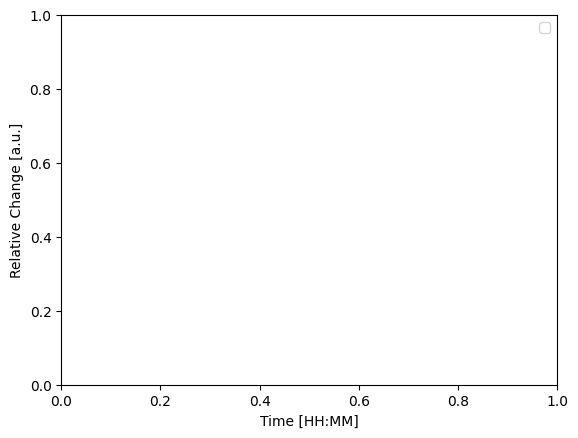

In [132]:
def rolling_mean(x, window=100):
    return np.convolve(x, np.ones(window)/window, mode='valid')


N = 1000
 
wf = np.array(wf_integrals)

temperatur = np.array(temp_corrected_wfs)
timearray = np.array(qc.integrated_data["time"][l:u]) #np.array(timearr)/3600 # Convert time from seconds to hours

l = 0
u = len(timearray) # use all data points


timearr = []
day = 0

time0 = datetime.strptime(qc.integrated_data["time"][0], "%H:%M:%S")
prev_t = time0

for i in range(len(qc.integrated_data["time"])):

    t = datetime.strptime(qc.integrated_data["time"][i], "%H:%M:%S")

    # detect midnight wrap
    if t < prev_t:
        day += 1

    # build full datetime (anchor to arbitrary date, e.g. Jan 1)
    t_full = datetime(2000, 1, 1) + timedelta(days=day,
                                              hours=t.hour,
                                              minutes=t.minute,
                                              seconds=t.second)

    timearr.append(t_full)

    prev_t = t


title = f"Long-term stability of {pm} 26 hours"#{round(timearray[-1])} over 1 hour" #


wf_smooth = rolling_mean(wfs, N)
ref_smooth = rolling_mean(refs, N)
temp_smooth = rolling_mean(temperatur, N)


# time axis must match shortened array
time_smooth = np.array(timearr)[l:u][:len(wf_smooth)]


ratio = np.array(wfs)/np.array(refs)

ratio_smooth = rolling_mean(np.array(wfs)/np.array(refs), N)




plt.xlabel("Time [HH:MM]")
plt.ylabel("Relative Change [a.u.]")
plt.legend()

# 👉 format x-axis to show only hours and minutes
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# optional: control tick density
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

plt.gcf().autofmt_xdate()
plt.plot(timearray[l:u], wfs[l:u], alpha=0.3, label="wf raw")
#plt.plot(timearray[l:u], ratio[l:u], alpha=0.3, label="ratio")
#plt.plot(timearray[l:u], refs[l:u], alpha=0.3, label="ref raw")
#plt.plot(timearray, temperatur, alpha=0.3, label="temperature raw")
#plt.ylim(0, 50)
plt.title(title)

plt.plot(time_smooth[l:u], wf_smooth[l:u]/np.mean(wf_smooth[l:u]), label=fr"wf smoothed ({N}) $\mu = {np.mean(wf_smooth[l:u])*1e3:.2f}mV , \sigma= {np.std(wf_smooth[l:u])/np.mean(wf_smooth[l:u])*100:.2f}$%")

#plt.plot(time_smooth[l:u], wf_smooth[l:u]/ref_smooth[l:u]/np.mean(wf_smooth[l:u]/ref_smooth[l:u]), label=fr"wf/ref smoothed ({N}) $\mu = {np.mean(wf_smooth[l:u]/ref_smooth[l:u]):.2f}, \sigma= {np.std(wf_smooth[l:u]/ref_smooth[l:u])/np.mean(wf_smooth[l:u]/ref_smooth[l:u])*100:.2f}$%")
plt.plot(np.array(timearr)[l+100000:u+100000], np.array(qc.integrated_data["temp_in"][l+100000:u+100000])/np.mean(np.array(qc.integrated_data["temp_in"][l+100000:u+100000])), label="temp_in")

#gain = np.array(m * (np.array(overVoltageChange) + 2.7) + b)
#plt.plot(np.array(timearr), gain/np.mean(gain), label="overVoltageChange")

plt.plot(np.array(timearr)[l+100000:u+100000], np.array(qc.integrated_data["temp_out"][l+100000:u+100000])/np.mean(np.array(qc.integrated_data["temp_out"][l+100000:u+100000])), label="temp_out")


#plt.plot(time_smooth[l:u], ratio_smooth[l:u], label=f"ratio smoothed ({N}) $\mu = {np.mean(ratio_smooth[l:u]):.2f}, \sigma= {np.std(ratio_smooth[l:u])/np.mean(ratio_smooth[l:u])*100:.2f}$%")

#plt.plot(time_smooth[l:u], temp_smooth[l:u], label=f"temperature corrected smoothed ({N}) $\mu = {np.mean(temp_smooth[l:u]):.2f}, \sigma= {np.std(temp_smooth[l:u])/np.mean(temp_smooth[l:u])*100:.2f}$%")
#plt.xlabel("Time [h]")
#plt.ylabel("Intregraded Yield [Vxns]")

plt.legend()
plt.show()


In [ ]:
qc = WOMqc.load("20260506_longterm_281_WOM_FreiburgXT2mm01_external_and_Moku_pulsgeneration_100000_power_strip", bin_file = False)

In [ ]:
qc = WOMqc.load("20260518_longterm_281_WOM_FreiburgXT2mm01_60000")

In [ ]:
pm = "SiPMin_out"
wf_integrals  = np.array(qc.integrated_data[pm])  # shape → (1000, 512)

ref = []

plt.xlabel("Time [s]")
plt.ylabel("Intregraded Yield [Vs]")
#plt.ylim(0.5,-2)
l = 00000 
u = qc.ni#/10

if "SiPM" in pm:
    int_window_min, int_window_max = qc.int_window_min_SiPM, qc.int_window_max_SiPM
else:
    int_window_min, int_window_max = qc.int_window_min_PMT, qc.int_window_max_PMT

if "int_in" in pm:
    temp = qc.integrated_data["temp_in"]
    ref = np.array(qc.integrated_data["SiPMin_in"])
    
else:
    temp = qc.integrated_data["temp_out"]
    ref = np.array(qc.integrated_data["SiPMout_out"])

temp_corrected_wfs = wf_integrals/temp
temp_corrected_refs = ref/temp

time0 = datetime.strptime(qc.integrated_data["time"][l], "%H:%M:%S")
prev_t = time0
timearr = [] 
day = 0
for i in range(len(wf_integrals)):
    i += l 
    # produce time axis
    t = datetime.strptime(qc.integrated_data["time"][i], "%H:%M:%S")

    # detect midnight wrap
    if t < prev_t:
        day += 1

    # compute delta from first timestamp
    delta = (t - time0).total_seconds() + day * 24 * 3600 
    # produce integral over basline corrected waveforms
    timearr.append(delta)
plt.plot(timearr, wf_integrals)
plt.plot(timearr, temp_corrected_wfs)
#plt.grid(True)
#plt.legend()
#plt.yscale("log")
plt.show()

In [ ]:
pm = "SiPMin_out"
wf_integrals  = np.array(qc.baseline_integrated_data[pm])  # shape → (1000, 512)

ref = []

plt.xlabel("Time [s]")
plt.ylabel("Intregraded Yield [Vs]")
#plt.ylim(0.5,-2)
l = 00000 
u = qc.ni#/10

if "SiPM" in pm:
    int_window_min, int_window_max = qc.int_window_min_SiPM, qc.int_window_max_SiPM
else:
    int_window_min, int_window_max = qc.int_window_min_PMT, qc.int_window_max_PMT

if "int_in" in pm:
    temp = qc.baseline_integrated_data["temp_in"]
    ref = np.array(qc.baseline_integrated_data["SiPMin_in"])
    
else:
    temp = qc.baseline_integrated_data["temp_out"]
    ref = np.array(qc.baseline_integrated_data["SiPMout_out"])

temp_corrected_wfs = wf_integrals/temp
temp_corrected_refs = ref/temp

time0 = datetime.strptime(qc.baseline_integrated_data["time"][l], "%H:%M:%S")
prev_t = time0
timearr = [] 
day = 0
for i in range(len(wf_integrals)):
    i += l 
    # produce time axis
    t = datetime.strptime(qc.baseline_integrated_data["time"][i], "%H:%M:%S")

    # detect midnight wrap
    if t < prev_t:
        day += 1

    # compute delta from first timestamp
    delta = (t - time0).total_seconds() + day * 24 * 3600 
    # produce integral over basline corrected waveforms
    timearr.append(delta)
plt.plot(timearr, wf_integrals)
plt.plot(timearr, temp_corrected_wfs)
#plt.grid(True)
#plt.legend()
#plt.yscale("log")
plt.show()


In [ ]:
def rolling_mean(x, window=100):
    return np.convolve(x, np.ones(window)/window, mode='valid')

N = 3000

wf = np.array(wf_integrals)

temperatur = np.array(temp_corrected_wfs)
timearray = np.array(qc.integrated_data["time"][l:u]) #np.array(timearr)/3600 # Convert time from seconds to hours

l = 0
u = qc.ni#20000#len(timearray) # use all data points

timearr = []
day = 0

time0 = datetime.strptime(qc.integrated_data["time"][0], "%H:%M:%S")
prev_t = time0

for i in range(len(qc.integrated_data["time"])):

    t = datetime.strptime(qc.integrated_data["time"][i], "%H:%M:%S")

    # detect midnight wrap
    if t < prev_t:
        day += 1

    # build full datetime (anchor to arbitrary date, e.g. Jan 1)
    t_full = datetime(2000, 1, 1) + timedelta(days=day,
                                              hours=t.hour,
                                              minutes=t.minute,
                                              seconds=t.second)

    timearr.append(t_full)

    prev_t = t


title = f"Long-term stability measured with {pm} 26 hours"#{round(timearray[-1])} over 1 hour" #{pm} 


wf_smooth = rolling_mean(wf, N)
ref_smooth = rolling_mean(ref, N)
temp_smooth = rolling_mean(temperatur, N)

temp_in = rolling_mean(np.array(qc.integrated_data["temp_in"]), N)
temp_out = rolling_mean(np.array(qc.integrated_data["temp_out"]), N)
# time axis must match shortened array
time_smooth = np.array(timearr)[l:u][:len(wf_smooth)]


ratio = np.array(wf)/np.array(ref)

ratio_smooth = rolling_mean(ratio, N)

plt.xlabel("Time [HH:MM]")


# 👉 format x-axis to show only hours and minutes
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# optional: control tick density
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

plt.gcf().autofmt_xdate()
#plt.plot(timearray[l:u], wfs[l:u], alpha=0.3, label="wf raw")
#plt.plot(timearray[l:u], ratio[l:u], alpha=0.3, label="ratio")
#plt.plot(timearray[l:u], refs[l:u], alpha=0.3, label="ref raw")
#plt.plot(timearray, temperatur, alpha=0.3, label="temperature raw")
#plt.ylim(0, 50)
plt.title(title)



#plt.plot(timearr, temperatur/np.mean(temperatur), alpha = 0.3, label = "integrated temp corrected individual wfs")

plt.plot(timearr[l:u], wf[l:u]/np.mean(wf[l:u]), alpha = 0)#, label = "Integrated Yield")
plt.plot(time_smooth[l:u], wf_smooth[l:u]/np.mean(wf_smooth[l:u]), label=fr"Integrated Yield smoothed over {N} events")# $\mu = {np.mean(wf_smooth[l:u])*1e9:.2f}Vxns , \sigma= {np.std(wf_smooth[l:u])/np.mean(wf_smooth[l:u])*100:.2f}$%")
#plt.plot(time_smooth[l:u], ref_smooth[l:u]/np.mean(ref_smooth[l:u]), label=fr"wf smoothed ({N}) $\mu = {np.mean(ref_smooth[l:u])*1e9:.2f}Vxns , \sigma= {np.std(ref_smooth[l:u])/np.mean(ref_smooth[l:u])*100:.2f}$%")

#plt.plot(timearr[l:u], ratio[l:u]/np.mean(ratio[l:u]), alpha = 0.3, label = "Integrated Yield (Trans/Ref)")
#plt.plot(time_smooth[l:u], ratio_smooth[l:u]/np.mean(ratio_smooth[l:u]), label=fr"Integrated Yield (Trans/Ref) smoothed over {N} events")#ratio smoothed ({N}) $\mu = {np.mean(ratio_smooth[l:u]):.2f}, \sigma= {np.std(ratio_smooth[l:u])/np.mean(ratio_smooth[l:u])*100:.2f}$%")


#plt.plot(time_smooth[l:u], wf_smooth[l:u]/np.mean(wf_smooth[l:u])/(np.array(qc.integrated_data["temp_out"][l:u])/np.mean(np.array(qc.integrated_data["temp_out"][l:u]))), label=fr"wf smoothed ({N}) $\mu = {np.mean(wf_smooth[l:u])*1e9:.2f}Vxns , \sigma= {np.std(wf_smooth[l:u])/np.mean(wf_smooth[l:u])*100:.2f}$%")

#plt.plot(time_smooth[l:u], temp_smooth[l:u]/np.mean(temp_smooth[l:u]), label=fr"temp corrected smoothed ({N}) $\mu = {np.mean(temp_smooth[l:u])*1e9:.2f}Vxns , \sigma= {np.std(temp_smooth[l:u])/np.mean(temp_smooth[l:u])*100:.2f}$%")
plt.plot(time_smooth[l:u], temp_in[l:u]/np.mean(temp_in[l:u]), label= "Smoothed temperature next to inner LED")
plt.plot(time_smooth[l:u], temp_out[l:u]/np.mean(temp_out[l:u]), label="Smoothed temperature next to outer LED")

#plt.plot(np.array(timearr)[l:u], np.array(qc.integrated_data["temp_in"][l:u])/np.mean(np.array(qc.integrated_data["temp_in"][l:u])), label="temp_in")
#plt.plot(np.array(timearr)[l:u], np.array(qc.integrated_data["temp_out"][l:u])/np.mean(np.array(qc.integrated_data["temp_out"][l:u])), label="temp_out")

#plt.plot(time_smooth[l:u], wf_smooth[l:u]/ref_smooth[l:u]/np.mean(wf_smooth[l:u]/ref_smooth[l:u]), label=fr"wf/ref smoothed ({N}) $\mu = {np.mean(wf_smooth[l:u]/ref_smooth[l:u]):.2f}, \sigma= {np.std(wf_smooth[l:u]/ref_smooth[l:u])/np.mean(wf_smooth[l:u]/ref_smooth[l:u])*100:.2f}$%")

#gain = np.array(m * (np.array(overVoltageChange) + 2.7) + b)
#plt.plot(np.array(timearr), gain/np.mean(gain), label="overVoltageChange")


#plt.plot(time_smooth[l:u], temp_smooth[l:u]/np.mean(temp_smooth[l:u]), label=f"temperature corrected (/T^2)smoothed ({N}) $\mu = {np.mean(temp_smooth[l:u]):.2f}, \sigma= {np.std(temp_smooth[l:u])/np.mean(temp_smooth[l:u])*100:.2f}$%")
#plt.xlabel("Time [h]")
#plt.ylabel("Intregraded Yield [Vxns]")
plt.ylim(0.95,1.05)
plt.ylabel("Relative Change [a.u.]")
plt.legend()
plt.show()

In [ ]:
pm = "SiPMout_in"
wf = np.array(qc.baseline_wf[pm]).squeeze()   # shape → (1000, 512)
wf_integrals = [] 
temp_corrected_wfs = []
temp_corrected_refs = []
ref = []

plt.xlabel("Time [s]")
plt.ylabel("Intregraded Yield [Vs]")
#plt.ylim(0.5,-2)
l = 00000 
u = 20000# qc.ni/10

if "SiPM" in pm:
    int_window_min, int_window_max = qc.int_window_min_SiPM, qc.int_window_max_SiPM
else:
    int_window_min, int_window_max = qc.int_window_min_PMT, qc.int_window_max_PMT

if "_in" in pm:
    temp = qc.integrated_data["temp_in"]
    ref = np.array(qc.baseline_wf["SiPMin_in"]).squeeze() 
    
else:
    temp = qc.integrated_data["temp_out"]
    ref = np.array(qc.baseline_wf["SiPMout_out"]).squeeze() 

time0 = datetime.strptime(qc.integrated_data["time"][l], "%H:%M:%S")
prev_t = time0

timearr = [] 
baseline_mean = 0 
wfs = []
refs = []
day = 0


for i, row in enumerate(wf[l:u]):
    i += l 
    # produce time axis
    t = datetime.strptime(qc.integrated_data["time"][i], "%H:%M:%S")

    # detect midnight wrap
    if t < prev_t:
        day += 1

    # compute delta from first timestamp
    delta = (t - time0).total_seconds() + day * 24 * 3600 
    # produce integral over basline corrected waveforms
    waveform = np.array(row)
    ref_waveform = np.array(ref[i])

    start, end, area = qc.riemann_sum_peak(waveform , int_window_min, int_window_max)
    start_ref, end_ref, area_ref = qc.riemann_sum_peak(ref_waveform, int_window_min, int_window_max)

    if abs(area) > 1e-11 and abs(area_ref) > 1e-11:  # Example threshold, adjust as needed
        norm_area = area/area_ref
        wfs.append(area)
        refs.append(area_ref)
        wf_integrals.append(norm_area)
        temp_corrected_wfs.append(area/temp[i])
        temp_corrected_refs.append(area_ref/temp[i])
        timearr.append(delta)
        prev_t = t
plt.plot(timearr, wf_integrals)
plt.plot(timearr, temp_corrected_wfs)
#plt.grid(True)
#plt.legend()
#plt.yscale("log")
plt.show()

#qc.correct_baseline_min(PM= ["SiPMin_in"])

In [ ]:
plt.plot(timearr, temp_corrected_wfs)

In [ ]:
def rolling_mean(x, window=100):
    return np.convolve(x, np.ones(window)/window, mode='valid')

N = 1000

wf = np.array(wf_integrals)

temperatur = np.array(temp_corrected_refs)
timearray = np.array(qc.integrated_data["time"][l:u]) #np.array(timearr)/3600 # Convert time from seconds to hours

l = 0
u = 20000#len(timearray) # use all data points


timearr = []
day = 0

time0 = datetime.strptime(qc.integrated_data["time"][0], "%H:%M:%S")
prev_t = time0

for i in range(len(qc.integrated_data["time"])):

    t = datetime.strptime(qc.integrated_data["time"][i], "%H:%M:%S")

    # detect midnight wrap
    if t < prev_t:
        day += 1

    # build full datetime (anchor to arbitrary date, e.g. Jan 1)
    t_full = datetime(2000, 1, 1) + timedelta(days=day,
                                              hours=t.hour,
                                              minutes=t.minute,
                                              seconds=t.second)

    timearr.append(t_full)

    prev_t = t


title = f"Long-term stability of LED out measured with inner SiPM 26 hours"#{round(timearray[-1])} over 1 hour" #


wf_smooth = rolling_mean(refs, N)
ref_smooth = rolling_mean(refs, N)
temp_smooth = rolling_mean(temperatur, N)


# time axis must match shortened array
time_smooth = np.array(timearr)[l:u][:len(wf_smooth)]


ratio = np.array(wfs)/np.array(refs)

ratio_smooth = rolling_mean(np.array(wfs)/np.array(refs), N)




plt.xlabel("Time [HH:MM]")


# 👉 format x-axis to show only hours and minutes
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# optional: control tick density
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

plt.gcf().autofmt_xdate()
#plt.plot(timearray[l:u], wfs[l:u], alpha=0.3, label="wf raw")
#plt.plot(timearray[l:u], ratio[l:u], alpha=0.3, label="ratio")
#plt.plot(timearray[l:u], refs[l:u], alpha=0.3, label="ref raw")
#plt.plot(timearray, temperatur, alpha=0.3, label="temperature raw")
#plt.ylim(0, 50)
plt.title(title)



#plt.plot(timearr, temperatur/np.mean(temperatur), alpha = 0.3, label = "integrated temp corrected individual wfs")

#plt.plot(timearr, wfs/np.mean(wfs), alpha = 0.3, label = "integrated individual wfs")
plt.plot(time_smooth[l:u], wf_smooth[l:u]/np.mean(wf_smooth[l:u]), label=fr"wf smoothed ({N}) $\mu = {np.mean(wf_smooth[l:u])*1e9:.2f}Vxns , \sigma= {np.std(wf_smooth[l:u])/np.mean(wf_smooth[l:u])*100:.2f}$%")

#plt.plot(time_smooth[l:u], wf_smooth[l:u]/np.mean(wf_smooth[l:u])/(np.array(qc.integrated_data["temp_out"][l:u])/np.mean(np.array(qc.integrated_data["temp_out"][l:u]))), label=fr"wf smoothed ({N}) $\mu = {np.mean(wf_smooth[l:u])*1e9:.2f}Vxns , \sigma= {np.std(wf_smooth[l:u])/np.mean(wf_smooth[l:u])*100:.2f}$%")


#plt.plot(time_smooth[l:u], temp_smooth[l:u]/np.mean(temp_smooth[l:u]), label=fr"temp corrected smoothed ({N}) $\mu = {np.mean(temp_smooth[l:u])*1e9:.2f}Vxns , \sigma= {np.std(temp_smooth[l:u])/np.mean(temp_smooth[l:u])*100:.2f}$%")


#plt.plot(np.array(timearr)[l:u], np.array(qc.integrated_data["temp_in"][l:u])/np.mean(np.array(qc.integrated_data["temp_in"][l:u])), label="temp_in")
plt.plot(np.array(timearr)[l:u], np.array(qc.integrated_data["temp_out"][l:u])/np.mean(np.array(qc.integrated_data["temp_out"][l:u])), label="temp_out")

#plt.plot(time_smooth[l:u], wf_smooth[l:u]/ref_smooth[l:u]/np.mean(wf_smooth[l:u]/ref_smooth[l:u]), label=fr"wf/ref smoothed ({N}) $\mu = {np.mean(wf_smooth[l:u]/ref_smooth[l:u]):.2f}, \sigma= {np.std(wf_smooth[l:u]/ref_smooth[l:u])/np.mean(wf_smooth[l:u]/ref_smooth[l:u])*100:.2f}$%")

#gain = np.array(m * (np.array(overVoltageChange) + 2.7) + b)
#plt.plot(np.array(timearr), gain/np.mean(gain), label="overVoltageChange")



#3plt.plot(time_smooth[l:u], ratio_smooth[l:u]/np.mean(ratio_smooth[l:u]), label=fr"ratio smoothed ({N}) $\mu = {np.mean(ratio_smooth[l:u]):.2f}, \sigma= {np.std(ratio_smooth[l:u])/np.mean(ratio_smooth[l:u])*100:.2f}$%")

#plt.plot(time_smooth[l:u], temp_smooth[l:u], label=f"temperature corrected smoothed ({N}) $\mu = {np.mean(temp_smooth[l:u]):.2f}, \sigma= {np.std(temp_smooth[l:u])/np.mean(temp_smooth[l:u])*100:.2f}$%")
#plt.xlabel("Time [h]")
#plt.ylabel("Intregraded Yield [Vxns]")
#plt.ylim(0.9,1.1)
plt.ylabel("Relative Change [a.u.]")
plt.legend()
plt.show()


In [ ]:
wf = qc.waveforms["PMT_in"].squeeze()   # shape → (1000, 512)
wf_sum = wf.sum(axis=0)   # shape → (512,)

plt.plot(wf_sum, label = "before baseline correction")
plt.xlabel("Sample")
plt.ylabel("Amplitude (summed)")
plt.title("Sum of 200000 darkcounts PMT_in")
#plt.ylim(0.5,-2)
n = 2*qc.ni
corrected_sum = np.zeros(512)
corrected_wf = []
for row in wf[:n]:
    waveform = np.array(row)
    #baseline = np.median(waveform, axis=-1, keepdims=True)
    #corrected = waveform - baseline

    corrected, baseline, idx = correct_baseline_min(
        waveform, window=(50, 0, 300), sigma=1, smooth_method=2
    )
    corrected_wf.append(corrected)
    corrected_sum += corrected 
plt.plot(corrected_sum, label = "after baseline correction")
plt.grid(True)
plt.legend()
#plt.yscale("log")
plt.show()

 'ni': 200000,
 'nj': 1,
 'rep': 1,
 'pulsewidth_ch1': 7.5e-08,
 'pulsewidth_ch2': 7.5e-08,
 'voltage_range_PMT': '400mVpp',
 'voltage_range_SiPM': '4Vpp',
 'rec_time_min': 0,
 'rec_time_max': 1e-06,
 'int_window_min_PMT': 2.5e-08,
 'int_window_max_PMT': 7.5e-08,
 'int_window_min_SiPM': 6e-08,
 'int_window_max_SiPM': 2.4e-07,
 'frame_length_max': 512,
 'plot_waveform': False,
 'plot_heatmap': False,
 'dry_run': False,
 'date': 20260312}

In [ ]:
wf = qc.waveforms["SiPMin_in"].squeeze()

time_axis = np.linspace(qc.rec_time_min, qc.rec_time_max, qc.frame_length_max) * 1e9  # ns
dt = (qc.rec_time_max - qc.rec_time_min) / qc.frame_length_max * 1e9  # ns

n_plots = 10

fig, axes = plt.subplots(n_plots, 1, figsize=(10, 12), sharex=True)
start = 4000
end = 6000
count = 0

for i, row in enumerate(wf[start:end]):
    if count >= n_plots:
        break
    # optional: keep your selection condition
    
    waveform = np.array(row)

    corrected, baseline, idx = correct_baseline_min(
            waveform, window=(200, 0, 512), sigma=4, smooth_method=2
    )
    if max(corrected) > 0.005:#min(corrected) < -0.0022:
        ax = axes[count]

        # --- plot original and corrected ---
        ax.plot(time_axis, waveform * 1000, label="Original")
        ax.plot(time_axis, corrected * 1000, label="Corrected")

        # --- baseline indicator ---
        ax.hlines(
            baseline * 1000,
            idx * dt + qc.rec_time_min * 1e9,
            (idx + 50) * dt + qc.rec_time_min * 1e9,
            color='r',
            linewidth=2,
            label="Baseline"
        )

        ax.set_ylabel("mV")
        ax.legend(loc="upper right", fontsize=8)

        count += 1

# shared x-label
axes[-1].set_xlabel("Time [ns]")

plt.tight_layout()
plt.show()

In [ ]:
 np.array(corrected_wf[:1000]).shape

In [ ]:
corrected_wf = np.expand_dims(corrected_wf, axis=1)
print_wf_projection(
    np.array(corrected_wf[:1000]),        # shape: (n_events, n_channels, n_samples)
    np.arange(512),        # array of time values (same length as n_samples)
    0, 60,
    -0.025, 0.025,
    50,
    active_channels=None
)

In [ ]:


def gaussian(x, mean, height, sigma):
        return height * np.exp(-0.5 * ((x - mean) / sigma)**2)

def print_wf_projection(
    waveforms,        # shape: (n_events, n_channels, n_samples)
    time_axis,        # array of time values (same length as n_samples)
    from_t, to_t,
    rangestart, rangeend,
    nbins,
    active_channels=None
):
    """
    Python equivalent of PrintWFProjection.
    """

    n_events, n_channels, n_samples = waveforms.shape

    if active_channels is None:
        active_channels = range(n_channels)

    # --- determine binning like in ROOT code ---
    default_rangestart = min(-10, rangestart)
    default_rangeend = max(20, rangeend)

    default_nbins = int(
        (default_rangeend - default_rangestart) * nbins / (rangeend - rangestart)
    )

    # --- convert time window to indices ---
    mask = (time_axis >= from_t) & (time_axis <= to_t)

    n_plots = len(active_channels)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))

    if n_plots == 1:
        axes = [axes]

    # --- loop over channels ---
    for ax, ch in zip(axes, active_channels):

        # extract data in time window
        data = waveforms[:, ch, :][:, mask].flatten()

        # histogram
        counts, bins, _ = ax.hist(
            data,
            bins=default_nbins,
            range=(default_rangestart, default_rangeend),
            alpha=0.6,
            label="Data"
        )

        # --- Gaussian fit ---
        mu, std = norm.fit(data)

        x = np.linspace(default_rangestart, default_rangeend, 500)
        p = norm.pdf(x, mu, std)

        # scale fit to histogram
        p_scaled = p * len(data) * (bins[1] - bins[0])

        ax.plot(x, p_scaled, 'r-', label=f"Fit μ={mu:.2f}, σ={std:.2f}")

        # labels
        ax.set_title(f"WF Projection Channel {ch}")
        ax.set_xlabel("Amplitude (mV)")
        ax.set_ylabel("Entries")
        ax.legend()

        # apply display range like ROOT
        ax.set_xlim(rangestart, rangeend)

    plt.tight_layout()
    plt.show()

In [ ]:
PM = ["PMT_in"]#, "SiPMin_in", "SiPMout_in"]
qc.plot_integral_over_time(PM)

In [ ]:
qc.plot_temperature_over_time()
    #qc.charge_spectrum("SiPMin_out", bins = 10)   
    
    #qc.charge_spectrum("SiPMout_out", bins = 10)  
    #qc.charge_spectrum("PMT_out", bins = 10)  
    #qc.light_yield_1dim()
    #qc.light_yield_1dim(ch1= "PMT_out", ch2 = "SiPMin_out", ch3="SiPMout_out")

In [ ]:
def histogram(var, bins, u, o):
    y, binEdges = np.histogram(var ,bins= bins, range = (u,o))
    bincenters = 0.5*(binEdges[1:] + binEdges[:-1])
    return y, bincenters

In [ ]:

# Imports a function for Gaussian smoothing.

def correct_baseline_min(waveform, window=(20, 10, 90), sigma=0, smooth_method=2):
    """
    Baseline correction using minimum-sum search over a moving window.
    """
    wf = np.array(waveform, dtype=float)
    # Converts the input waveform to a float numpy array.

    n = len(wf)
    # Gets the length of the waveform.

    # --- Optional smoothing ---
    if sigma > 0:
        if smooth_method == 0:
            # Simple running average (boxcar)
            kernel = np.ones(int(2 * sigma + 1)) / (2 * sigma + 1)
            # Creates a boxcar kernel of width 2*sigma+1.
            wf = np.convolve(wf, kernel, mode='same')
            # Applies running average smoothing.
        elif smooth_method == 2:
            wf = gaussian_filter1d(wf, sigma=sigma)
            # Applies Gaussian smoothing.

    # --- Extract window parameters ---
    length, start, end = window
    # Unpacks window parameters: averaging length, start, end.

    start = max(0, int(start))
    # Ensures start index is not negative.

    end = min(n - length, int(end))
    # Ensures end index does not exceed waveform length.

    # --- Search for the minimum average ---
    means = np.array([
        np.mean(wf[i:i + length])
        for i in range(start, end)
    ])
    # For each window position, computes the mean value.

    min_index_local = np.argmin(np.abs(means))
    # Finds the index of the minimum mean value.

    min_index = start + min_index_local
    # Converts local index to global index in waveform.

    # --- Determine baseline value ---
    baseline_value = means[min_index_local]
    # Gets the minimum mean value as the baseline.

    corrected = wf - baseline_value
    # Subtracts the baseline value from the waveform.

    return corrected, baseline_value, min_index
    # Returns the corrected waveform, baseline value, and baseline index.
led_out = qc.waveforms["PMT_in"]

In [ ]:

led_out = qc.waveforms["PMT_in"]
plt.figure(figsize=(10, 4.3))
windowlength = 50
plt.subplot(1,2,1)
sum = []
count = 0
n = 200000
for row in led_out[:n]:
    waveform = np.array(row[0])
    corrected, baseline, idx = correct_baseline_min(
        waveform, window=(200, 0, 512), sigma=2, smooth_method=2
    )
    #print(np.mean(row), count)
    if min(corrected) < -0.0022:
        sum.append(-corrected)
        #print(row)
        count += 1
        
plt.hist(np.concatenate(sum)*1000, bins=200, label = f"sigma: {np.std(np.concatenate(sum))*1000:.3f} mV")
print("sigma: ", np.std(np.concatenate(sum))*1000, "mV", "mean: ", np.mean(np.concatenate(sum))*1000, "mV")
plt.title(f"Histogram of {n} random triggered events")
plt.xlabel("Amplitude [mV]")
plt.ylabel("Counts")
#plt.xlim(-12, 3)
plt.yscale("log") #range = (-12, 3) ,
#plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
filename = qc.foldername / f"{qc.filename}_corrected_waveforms_PMT_in.csv"
savesum = pd.DataFrame(sum)
savesum.to_csv(filename, index=False)

In [ ]:
plt.hist(np.concatenate(sum)*1000, bins=150, label = f"sigma: {np.std(np.concatenate(sum))*1000:.3f} mV")
print("sigma: ", np.std(np.concatenate(sum))*1000, "mV", "mean: ", np.mean(np.concatenate(sum))*1000, "mV")
plt.title(f"Histogram of {n} random triggered events")
plt.xlabel("Amplitude [mV]")
plt.ylabel("Counts")
plt.xlim(-2.5, 7)
plt.yscale("log") #range = (-12, 3) ,
#plt.legend()
plt.tight_layout()
plt.show()

In [ ]:


# Create synthetic spectrum
y_data, x = histogram(np.concatenate(sum)*1000, 100, -2.0, 7.5)


# --- Fit ---
def ideal_pmt_fit(x, A, lambd, sigma, Q1):
    return ideal_pmt_fit_components(x, A, lambd, sigma, Q1)[0]

p0 = [1e7, 2, 0.5, 1.5]
popt, _ = curve_fit(ideal_pmt_fit, x, y_data, p0=p0, maxfev=10000)

# --- Compute fitted components ---
y_fit, comps_fit = ideal_pmt_fit_components(x, *popt)

# --- Plot ---
plt.figure(figsize=(9,6))
plt.plot(x, y_data, 'k.', ms=4, label='Data')
plt.plot(x, y_fit, 'r-', lw=2, label='Total fit')

# Plot individual Gaussians
colors = plt.cm.viridis(np.linspace(0, 1, len(comps_fit)))
for (k, c), col in zip(comps_fit.items(), colors):
    plt.plot(x, c, color=col, ls='--', label=f'{k} PE')

plt.xlabel("Charge (a.u.)")
plt.ylabel("Amplitude (a.u.)")
plt.title("Ideal PMT Fit with Individual Photoelectron Peaks")
#plt.legend(ncol=2, fontsize=9)
plt.grid(alpha=0.3)
plt.ylim(1, 2e7)
plt.yscale("log")
plt.tight_layout()
plt.show()

print(f"Fitted parameters:")
print(f"A = {popt[0]:.3f}, λ = {popt[1]:.3f}, σ = {popt[2]:.3f}, Q₁ = {popt[3]:.3f}")



In [ ]:
led_out = qc.waveforms["SiPMin_in"]
plt.figure(figsize=(10, 4.3))
windowlength = 50
plt.subplot(1,2,1)
sum = []
count = 0
n = 20000
for row in led_out[:n]:
    waveform = np.array(row[0])
    corrected, baseline, idx = correct_baseline_min(
        waveform, window=(200, 0, 512), sigma=2, smooth_method=2
    )
    if max(corrected) > 0.005:
    #print(np.mean(row), count)
        sum.append(corrected)
        #print(row)
        count += 1
plt.hist(np.concatenate(sum)*1000, bins=200, label = f"sigma: {np.std(np.concatenate(sum))*1000:.3f} mV")
print("sigma: ", np.std(np.concatenate(sum))*1000, "mV", "mean: ", np.mean(np.concatenate(sum))*1000, "mV")
plt.title(f"Histogram of {n} random triggered events")
plt.xlabel("Amplitude [mV]")
plt.ylabel("Counts")
#plt.xlim(-12, 3)
plt.yscale("log") #range = (-12, 3) ,
#plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
count

In [ ]:
led_out = qc.waveforms["SiPMout_in"]
plt.figure(figsize=(10, 4.3))
windowlength = 50
plt.subplot(1,2,1)
sum = []
count = 0
n = 20000
for row in led_out[:n]:
    waveform = np.array(row[0])
    corrected, baseline, idx = correct_baseline_min(
        waveform, window=(windowlength, 0, 250), sigma=2, smooth_method=2
    )
    #print(np.mean(row), count)
    if max(corrected) > 0.005:
        sum.append(corrected)
        #print(row)
        count += 1
plt.hist(np.concatenate(sum)*1000, bins=200, label = f"sigma: {np.std(np.concatenate(sum))*1000:.3f} mV")
print("sigma: ", np.std(np.concatenate(sum))*1000, "mV", "mean: ", np.mean(np.concatenate(sum))*1000, "mV")
plt.title(f"Histogram of {n} random triggered events")
plt.xlabel("Amplitude [mV]")
plt.ylabel("Counts")
#plt.xlim(-12, 3)
plt.yscale("log") #range = (-12, 3) ,
#plt.legend()
plt.tight_layout()
plt.show()

In [ ]:



def fitf(x, A, mu, lam, sigma0, sigma1, G, B):
    """
    Python equivalent of your C++ Fitf class.

    Parameters
    ----------
    x : float or array
        Input value(s)
    p : array-like
        Parameters:
        p[0] : normalization (A)
        p[1] : mu
        p[2] : lambda
        p[3] : sigma0
        p[4] : sigma1
        p[5] : G (gain)
        p[6] : B (baseline)

    Returns
    -------
    float or array
    """

    x = np.asarray(x)
    

    kmax = int(np.ceil(mu)) * 10
    result = np.zeros_like(x, dtype=float)

    for k in range(kmax + 1):
        sigma_k = np.sqrt(sigma0**2 + k * sigma1**2)

        # generalized Poisson
        gp = (
            mu
            * (mu + k * lam) ** (k - 1)
            * np.exp(-(mu + k * lam))
            / factorial(k)
        )

        # Gaussian
        gauss = (
            1.0 / (np.sqrt(2 * np.pi) * sigma_k)
            * np.exp(-((x - (k * G + B)) ** 2) / (2 * sigma_k**2))
        )

        result += A * gp * gauss

    return result

In [ ]:
data = np.concatenate(sum) * 1000  # mV

counts, bin_edges = np.histogram(data, bins=200)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])


# --- initial parameters (VERY important!) ---
p0 = [
    counts.max(),  # A
    1,           # mu
    0.1,           # lambda
    4,           # sigma0
    4,           # sigma1
    10,           # G (peak spacing in mV!)
    0.0            # B
]

# --- fit ---
popt, pcov = curve_fit(
    fitf,
    bin_centers,
    counts,
    p0=p0,
    maxfev=10000
)


x_fit = np.linspace(bin_centers.min(), bin_centers.max(), 1000)
y_fit = fitf(x_fit, *popt)

plt.figure(figsize=(10, 4.3))

plt.hist(data, bins=200, alpha=0.6, label="Data", log=True)
plt.plot(x_fit, y_fit, 'r-', label="Fit")

plt.xlabel("Amplitude [mV]")
plt.ylabel("Counts")
plt.title("SiPM Spectrum Fit")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
def pmt_fit_with_pedestal(x, A, w, alpha, sigma0, Q0, lambd, sigma1, Q1, beta, kmax=None):
    """
    Full PMT charge model including pedestal and exponential tail.

    Parameters
    ----------
    x : array-like
        Charge axis
    A : float
        Overall normalization
    w : float
        Fraction of exponential tail
    alpha : float
        Exponential slope parameter
    sigma0 : float
        Pedestal width
    Q0 : float
        Pedestal mean (offset)
    lambd : float
        Poisson mean (photoelectrons)
    sigma1 : float
        SPE width
    Q1 : float
        Charge per photoelectron
    beta : float
        Pedestal scaling factor (for k=0 Gaussian normalization)
    kmax : int, optional
        Maximum k

    Returns
    -------
    total : ndarray
    components : dict
    """

    x = np.asarray(x)

    if kmax is None:
        kmax = int(np.ceil(lambd) * 10)

    total = np.zeros_like(x, dtype=float)
    components = {}

    for k in range(0, kmax + 1):
        # --- Poisson weight ---
        poiss = (lambd**k) * np.exp(-lambd) / factorial(k)

        # --- Mean and width ---
        Qn = Q0 + k * Q1
        sigman = np.sqrt(sigma0**2 + k * sigma1**2)

        # --- Gaussian term ---
        if k == 0:
            norm = beta / (sigma0 * np.sqrt(2 * np.pi))
            gauss = np.exp(-((x - Q0) ** 2) / (2 * sigma0**2))
        else:
            norm = 1.0 / (sigma1 * np.sqrt(2 * np.pi * k))
            gauss = np.exp(-((x - Qn) ** 2) / (2 * k * sigma1**2))

        gn_term = (1 - w) * norm * gauss

        # --- Exponential tail term ---
        ignxe_exp = (alpha / 2.0) * np.exp(
            -alpha * (x - Qn - alpha * sigman**2)
        )

        sgn_arg = x - Qn - sigman**2 * alpha
        arg_sgn = np.sign(sgn_arg)
        arg_sgn[arg_sgn == 0] = 1

        ignxe_erf = (
            erf(np.abs(Q0 - Qn - sigman**2 * alpha) / (sigman * np.sqrt(2)))
            + arg_sgn * erf(np.abs(sgn_arg) / (sigman * np.sqrt(2)))
        )

        tail_term = w * ignxe_exp * ignxe_erf

        comp = A * poiss * (gn_term + tail_term)

        components[k] = comp
        total += comp

    total[total < 0] = 0  # match C++ safeguard

    return total, components

In [ ]:
import numpy as np
from scipy.special import factorial

def ideal_pmt_fit_components(x, A, lambd, sigma, Q1, kmax=None):
    """
    Ideal PMT charge distribution model (Anelli et al. 1995)
    Returns both total spectrum and individual Gaussian components.
    
    Parameters
    ----------
    x : array-like
        Charge axis (e.g. ADC or integrated charge).
    A : float
        Overall normalization.
    lambd : float
        Mean number of photoelectrons (Poisson mean).
    sigma : float
        Width of single-photoelectron response.
    Q1 : float
        Mean charge per photoelectron.
    kmax : int, optional
        Max number of photoelectron terms to sum (default = ceil(lambd) * 10)
    
    Returns
    -------
    total : ndarray
        Total model spectrum.
    components : dict
        Dictionary {k: gaussian_component_array} for each k.
    """
    x = np.asarray(x)
    if kmax is None:
        kmax = int(np.ceil(lambd) * 10)
    
    total = np.zeros_like(x, dtype=float)
    components = {}

    for k in range(1, kmax + 1):
        poiss = (lambd**k) * np.exp(-lambd) / factorial(k)
        norm = 1.0 / (sigma * np.sqrt(2 * np.pi * k))
        gauss = np.exp(-((x - k * Q1) ** 2) / (2 * k * sigma**2))
        comp = A * poiss * norm * gauss
        components[k] = comp
        total += comp

    return total, components

In [ ]:
print(7.83860e5 * 

In [ ]:
Vset = 40.7
T = 33
Gain_1 = 7.83861591e5 * Vset - 30696019.903559998 - 26384.78115306 * T + 9.80997541e5

Vset = 40.7
T = 36
Gain_2 = 7.83861591e5 * Vset - 30696019.903559998 - 26384.78115306 * T + 9.80997541e5
print(Gain_1/Gain_2)


1.063922181701773


In [ ]:
def gain(T, Vset, dVset, dT):
    """
    Calculate the gain of the SiPM based on the applied voltage and temperature.
    Slope:     m = (7.838615914826629 ± 0.001483241521232523) e5 1/V
    Intercept: b = (9.809975406709395 ± 0.004662604806026203) e5

    #Gain(Overvoltage) = (7.83861591 ± 0.00148324)*1e5/V * Overvoltage + (9.80997541 ± 0.00466260)*1e5 -  at 25 degrees C - 0.12 V geringere overvoltage - 12% weniger Gain pro 4 Grad Temperaturerhöhung
    #Breakdownvoltage(T) = (39.16+-0.01)V + (33.66e-3+-0.30e-3) V/K * T
    #If the Voltage is set to Vset than the 
    # Overvoltage is Vset-Breakdownvoltage(T) 
    # = (Vset+-0.1)V - (39.16+-0.01)V - (33.66e-3+-0.30e-3) V/K * T 
    
    # Gain over Temperature: 
    # Gain(T) = (7.83861591 ± 0.00148324)*1e5/V * ((Vset+-0.1)V - (39.16+-0.01)V - (33.66e-3+-0.30e-3) V/K * T) + (9.80997541 ± 0.00466260)*1e5 
        
    # Gain(T) = A * (Vset - B - C * T) + D
    # A = 7.83861591e5 #
    # dA = 0.00148324e5
    # B = 39.16
    # dB = 0.01
    # C = 33.66e-3
    # dC = 0.30e-3
    # D = 9.80997541e5
    # dD = 0.00466260e5
    # dT = 0.1
    # dVset = 0.1
    # dGain(T) = \sqrt((dA * (Vset + B + C*T))^2 + (A * dVset)^2 + (dB*A)^2 + (dC * T*A)^2 + (dT*C*A)+ (dD)^2) 
    # SiPM output should proportional to Gain(T) and therefore the SiPM output should decrease with increasing temperature.

    Parameters
    ----------
    T : float/array of floats
        Temperature of the PCB in degrees Celsius.

    Returns
    -------
    Gain : float
        Calculated gain.
    dGain: float    
        Calculated uncertainty of the gain.
    """
    Gain_per_volt = 7.83861591e5 #Gain change per Volt [V^-1] Fit parameter determined from Gain_overvoltage.csv
    dGain_per_volt = 0.00148324e5 
    Breakdown_voltage = 39.16 #Breakdown voltage [V] constant Fit parameter determined from breackdownvoltage_temperature.csv
    dBreakdown_voltage = 0.01
    Breakdown_per_K = 33.66e-3 #Breakdown voltage change per Kelvin [V/K] Fit parameter determined from breackdownvoltage_temperature.csv
    dBreakdown_per_K = 0.30e-3
    Gain_const = 9.80997541e5 #Gain constant [V] Fit parameter determined from Gain_overvoltage.csv
    dGain_const = 0.00466260e5

    Gain = Gain_per_volt * (Vset - Breakdown_voltage - Breakdown_per_K * T) + Gain_const
    dGain = np.sqrt((dGain_per_volt * (Vset - Breakdown_voltage - Breakdown_per_K * T))**2 + (Gain_per_volt * dVset)**2 + (dBreakdown_voltage * Gain_per_volt)**2 + (dBreakdown_per_K * T* Gain_per_volt)**2 + (dT * Breakdown_per_K * Gain_per_volt)**2 + (dGain_const)**2)
    return Gain, dGain

<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
/var/folders/3v/hmh0d98n4s5490s3cjz094yw0000gn/T/ipykernel_91361/240487665.py:27: SyntaxWarning: invalid escape sequence '\s'
  # dGain(T) = \sqrt((dA * (Vset + B + C*T))^2 + (A * dVset)^2 + (dB*A)^2 + (dC * T*A)^2 + (dT*C*A)+ (dD)^2)


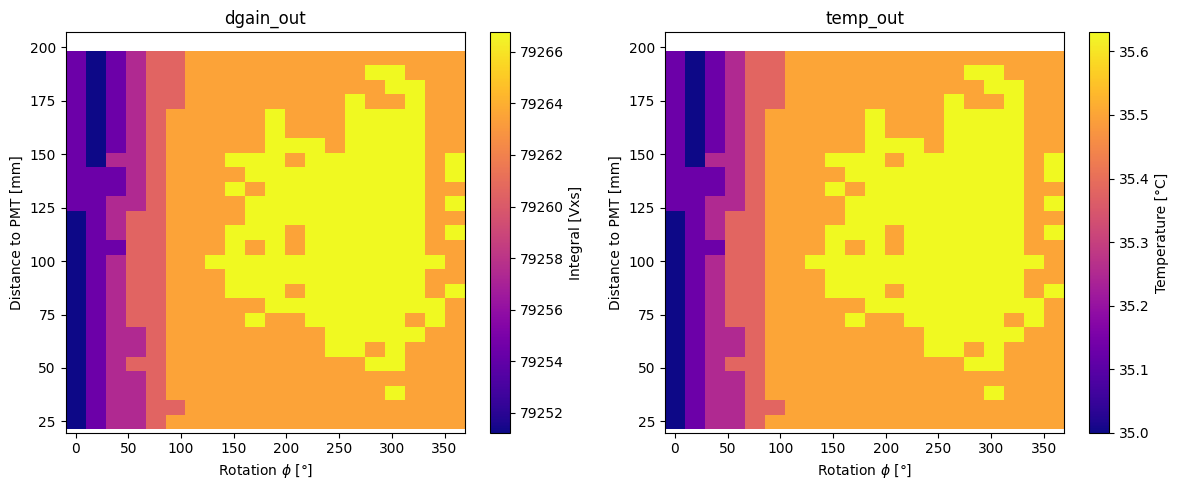

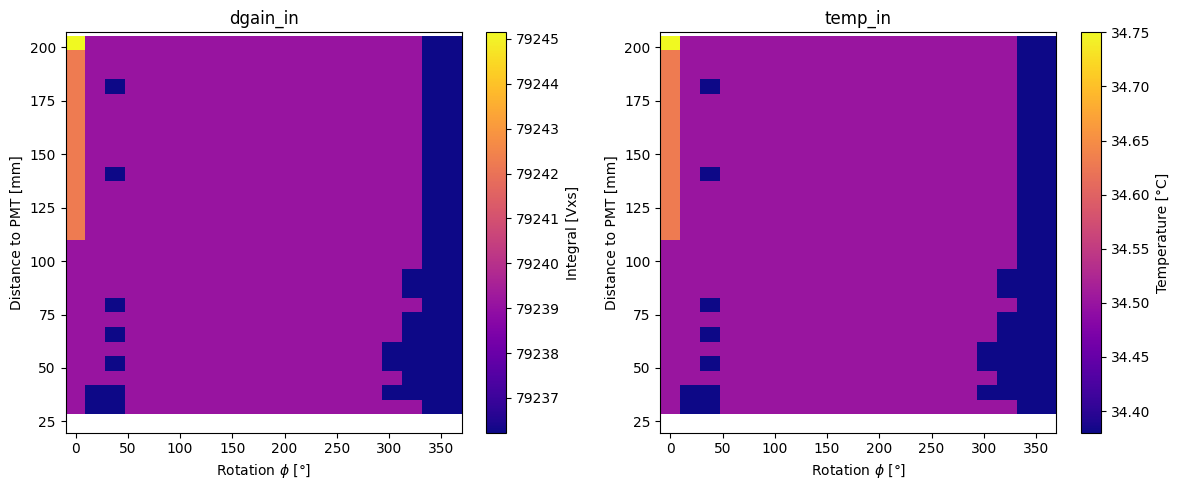

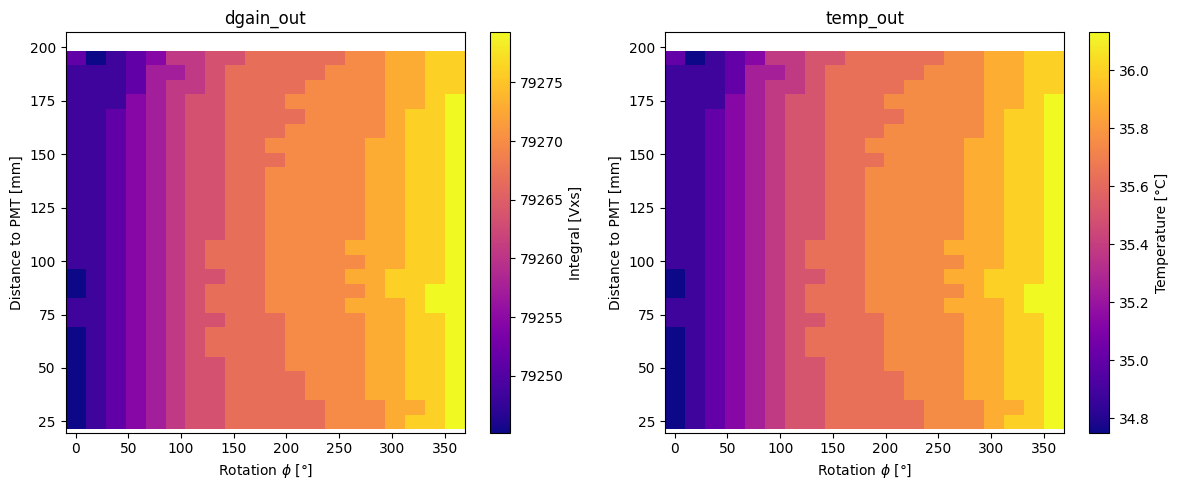

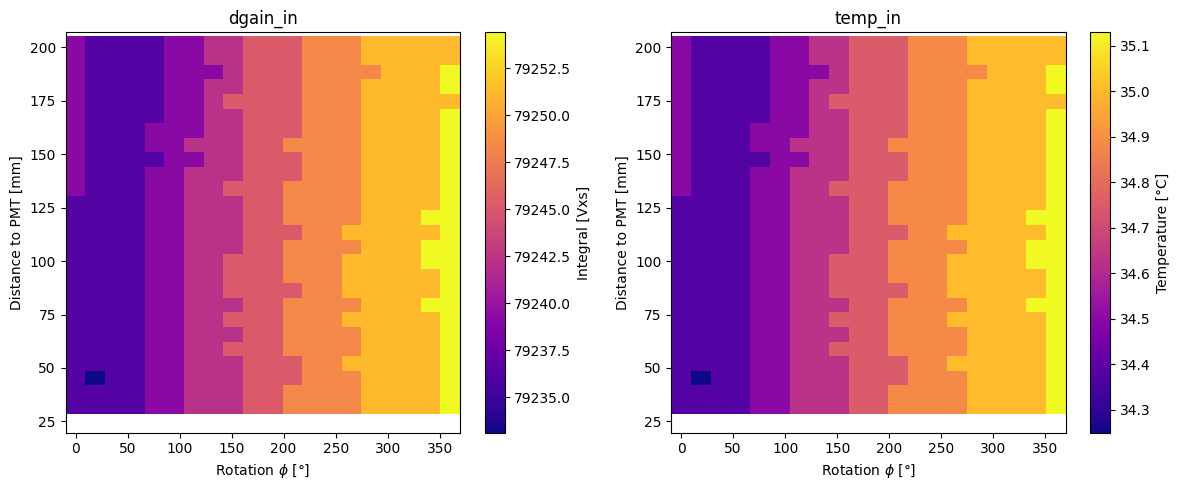

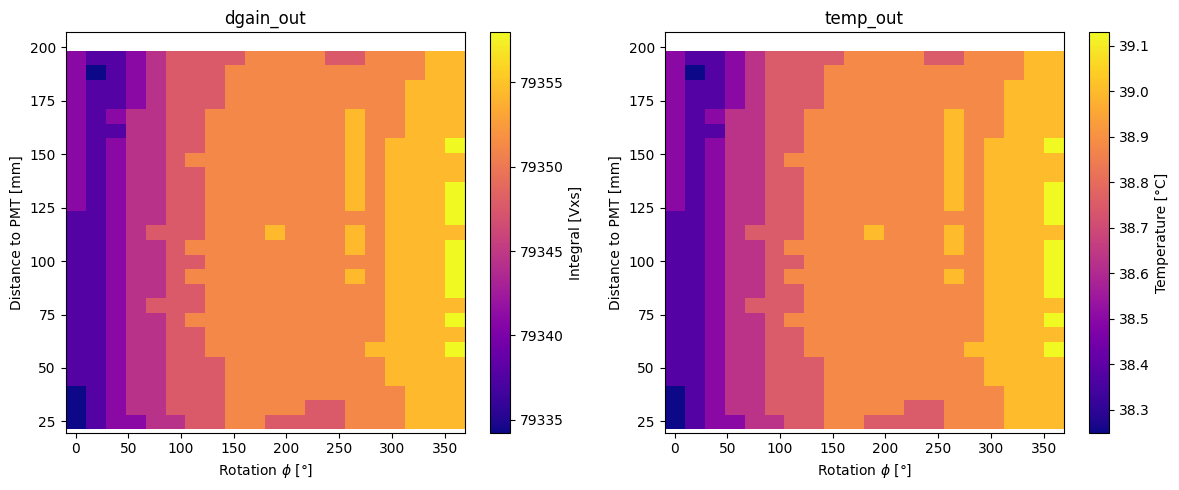

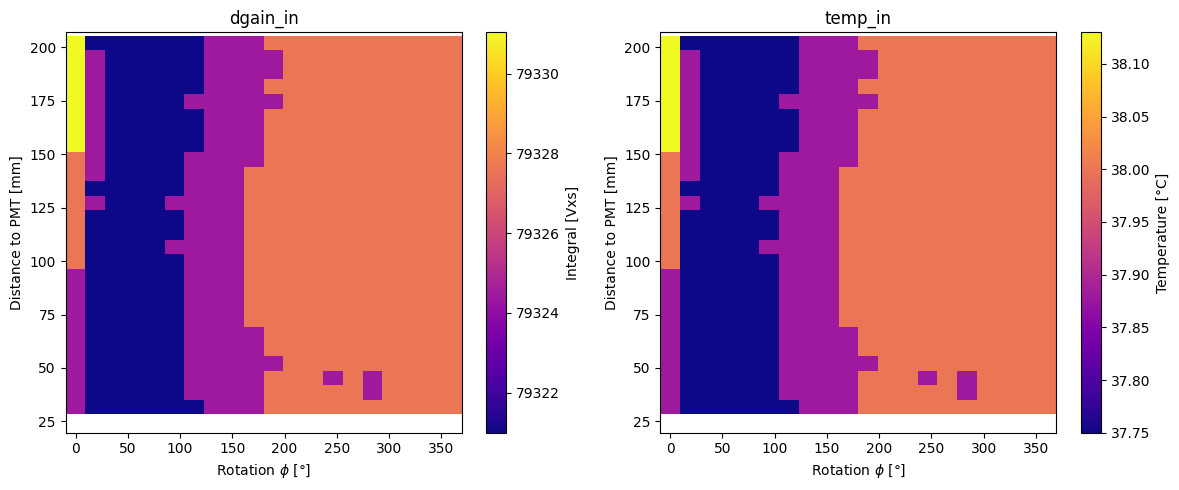

In [ ]:
for qc in QC:
    qc.heatmap_WOM(ch1="dgain_out", ch2="temp_out", baseline_subtract = True, normalize = False)#, remove_rows = [1,2], vmin = [0.6], vmax = [0.78])#, normalize = False, title = [f"WOM 11 response {pm}"], colorlabel = ["Signal integrated yield/ Reference integrated yield"]) #no rows removed
    qc.heatmap_WOM(ch1="dgain_in", ch2="temp_in", baseline_subtract = True, normalize = False)#, remove_rows = [1,2], vmin = [0.6], vmax = [0.78])#, normalize = False, title = [f"WOM 11 response {pm}"], colorlabel = ["Signal integrated yield/ Reference integrated yield"]) #no rows removed

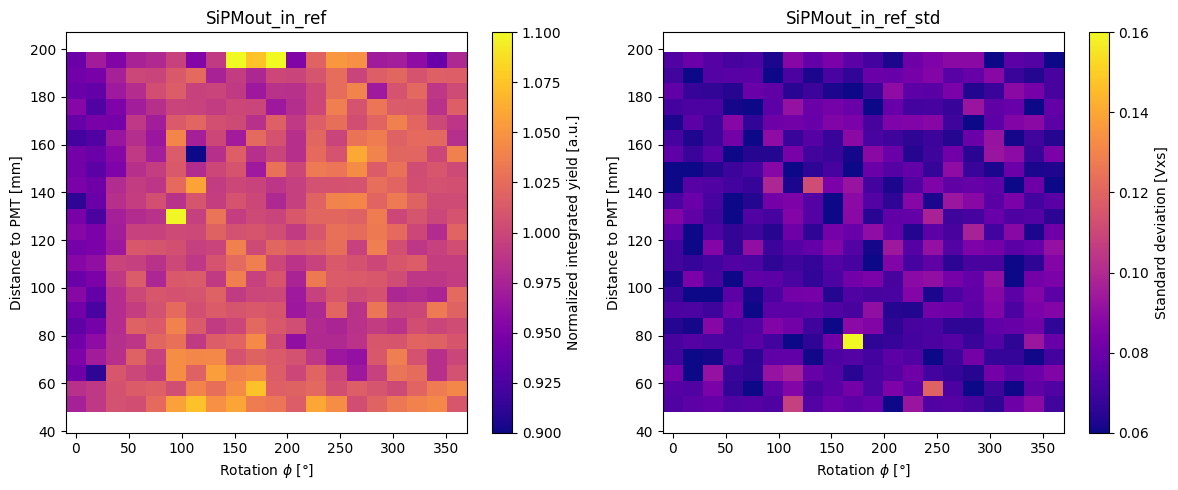

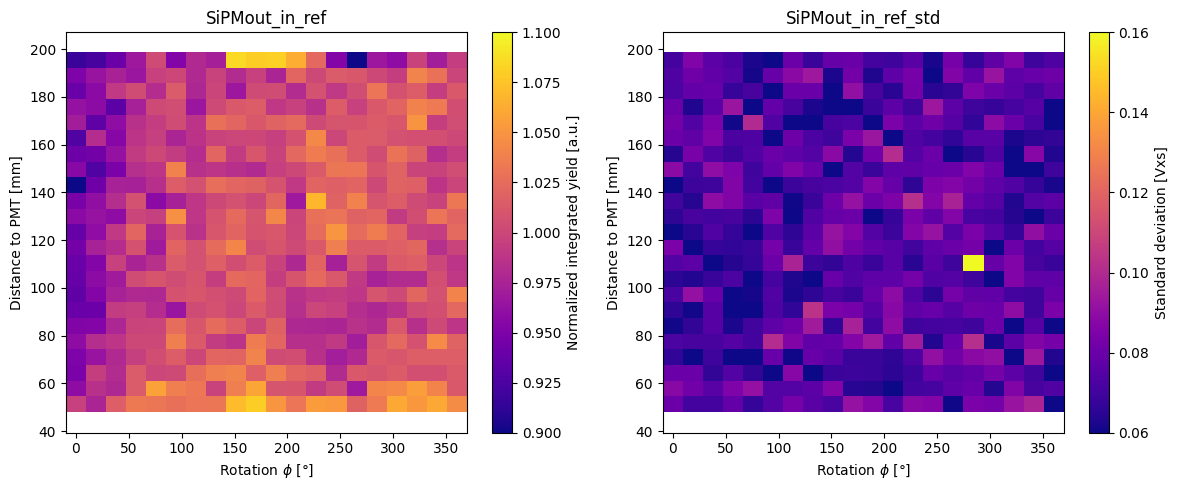

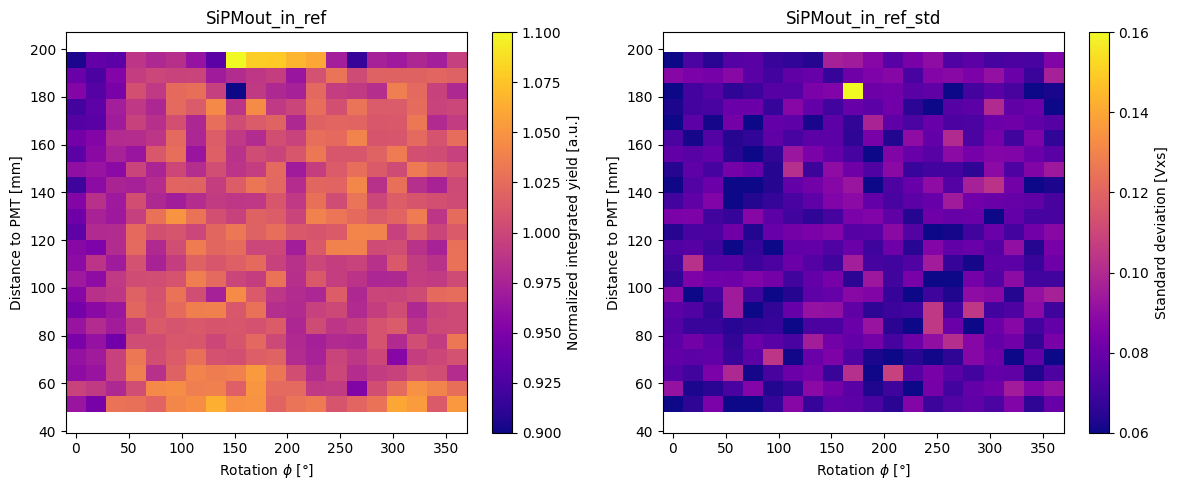

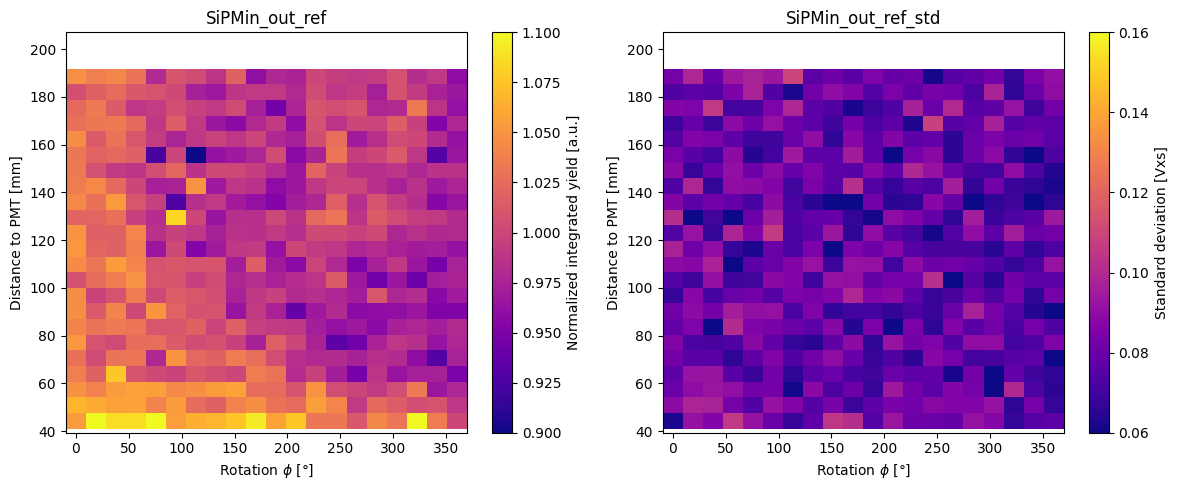

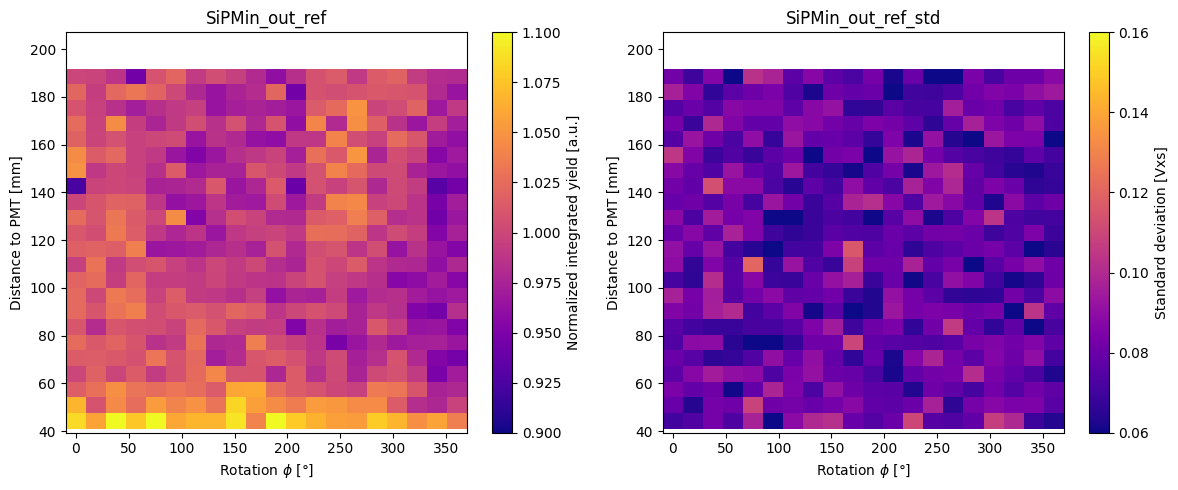

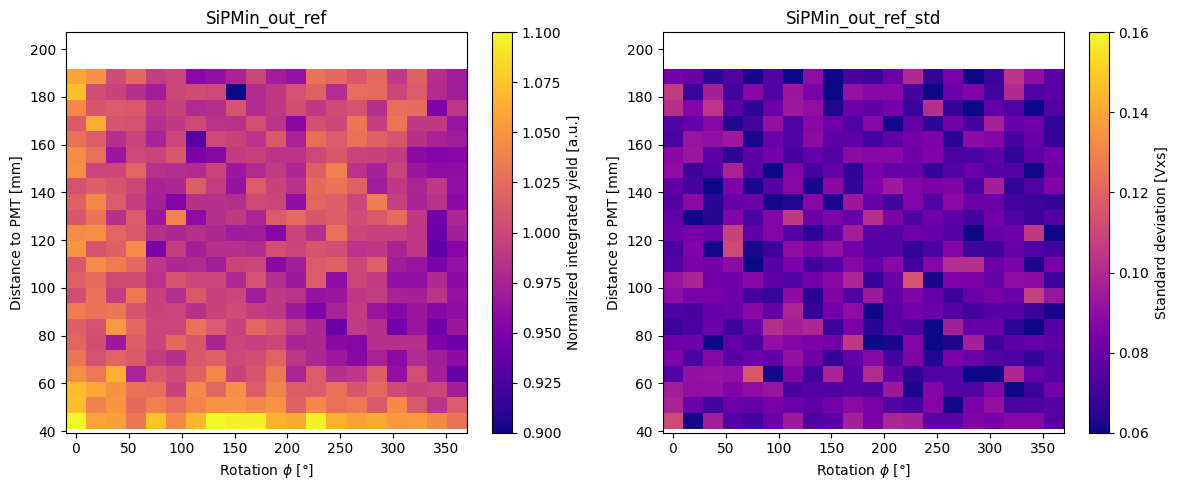

In [148]:
for pm, ref in zip(PM, REF):
    count = 0
    for qc in QC:
        #print(count, pm, ref, np.mean(np.array(qc.baseline_integrated_data[f"{pm}"]/qc.baseline_integrated_data[f"{ref}"])))
        qc.heatmap_WOM(ch1=f"{pm}_ref", ch2=f"{pm}_ref_std", baseline_subtract = True, normalize = True, remove_rows = [1,2], vmin = [0.9, 0.06], vmax = [1.1, 0.16])
        count += 1
      

In [156]:

PM = ["SiPMout_in",  "SiPMin_out"]
REF = ["SiPMin_in", "SiPMout_out"]


qc11_wo1 = WOMqc.load("20260610_testbeam_WOM_11_6_55mm_3_new_cover_wo_coupling_new")
qc11_wo2 = WOMqc.load("20260625_testbeam_WOM_11_6_55mm_new_cover_wo_coupling")
qc11_wo3 = WOMqc.load("20260629_testbeam_WOM_11_6_55mm_new_cover_wo_coupling_2")
QC = [qc11_wo1, qc11_wo2, qc11_wo3]
for pm, ref in zip(PM, REF):
    count = 0
    for qc in QC:
        print(count, pm, ref, np.mean(np.array(qc.baseline_integrated_data_eventwise[f"{pm}"]/qc.baseline_integrated_data_eventwise[f"{ref}"])))
        count += 1
        #qc.heatmap_WOM(ch1=f"{pm}_ref", ch2=f"{pm}_ref_std", baseline_subtract = True, normalize = True, remove_rows = [1,2])#, vmin = [0.6], vmax = [0.78])#, normalize = False, title = [f"WOM 11 response {pm}"], colorlabel = ["Signal integrated yield/ Reference integrated yield"]) #no rows removed
for qc in QC:
    apply_sipm_corrections(qc)
    #qc.calculate_eventwise_ratios()
for pm, ref in zip(PM, REF):
    count = 0
    for qc in QC:
        print(count, pm, ref, np.mean(np.array(qc.baseline_integrated_data_eventwise[f"{pm}"]/qc.baseline_integrated_data_eventwise[f"{ref}"])))
        #qc.heatmap_WOM(ch1=f"{pm}_ref", ch2=f"{pm}_ref_std", baseline_subtract = True, normalize = True, remove_rows = [1,2])
        count += 1
      

0 SiPMout_in SiPMin_in 1.0319521
1 SiPMout_in SiPMin_in 1.0352126
2 SiPMout_in SiPMin_in 1.1024098
0 SiPMin_out SiPMout_out 0.7361882
1 SiPMin_out SiPMout_out 0.74411184
2 SiPMin_out SiPMout_out 0.74165976
0 SiPMout_in SiPMin_in 1.0531955194782572
1 SiPMout_in SiPMin_in 1.0534590922678944
2 SiPMout_in SiPMin_in 1.124448159838291
0 SiPMin_out SiPMout_out 0.7214159922691583
1 SiPMin_out SiPMout_out 0.7312771784448419
2 SiPMin_out SiPMout_out 0.7271860931366365


In [335]:
def apply_sipm_corrections(qc, Vset = 40.7, dVset = 0.1, dT = 0.1):
    '''
    - calculate gain
    - first correct all SiPM values with the gain 
    - Normalize SiPM values to the 999 measurement if it exists
    '''
    #name == "integrated_data":   
    #    integrated_data = self.integrated_data
    #elif name == "baseline_integrated_data":    
    #    integrated_data = self.baseline_integrated_data

    qc.baseline_integrated_data["gain_out"], qc.baseline_integrated_data["dgain_out"] = gain(qc.baseline_integrated_data["temp_out"], Vset = Vset, dVset = dVset, dT = dT)
    qc.baseline_integrated_data["gain_in"], qc.baseline_integrated_data["dgain_in"] = gain(qc.baseline_integrated_data["temp_in"], Vset = Vset, dVset = dVset, dT = dT)

    PM = ["SiPMout_in", "SiPMin_in", "SiPMout_out", "SiPMin_out"]
    Gain = ["gain_out", "gain_in", "gain_out", "gain_in"]
    for pm, g in zip(PM, Gain):  
        gain_matrix = np.stack(qc.baseline_integrated_data[g].values)[:, None , None]
        #print(np.shape(gain_matrix), gain_matrix)
        dgain_matrix = np.stack(qc.baseline_integrated_data[f"d{g}"].values)[:, None , None]
        ratio = qc.baseline_integrated_data_eventwise[pm] / gain_matrix
        #for i in range(3):
            #print("temp_out", qc.baseline_integrated_data["temp_out"][i], pm, "qc.baseline_integrated_data_eventwise", qc.baseline_integrated_data_eventwise[pm][i], "gain_matrix", gain_matrix[i], "ratio", ratio[i])
        ratio_err = np.abs(ratio) * np.sqrt(
                (dgain_matrix/ gain_matrix)**2
            )
            
        qc.baseline_integrated_data_eventwise[f"{pm}_gain"] =  ratio
        qc.baseline_integrated_data_eventwise[f"{pm}_gain_err"] = ratio_err
                

    if qc.integrated_data["j"][0] == 999:
        for pm in PM:
            ref = qc.baseline_integrated_data_eventwise[f"{pm}_gain"][0][qc.baseline_integrated_data_eventwise[pm][0]!= 0].mean()
            if ref != 0:
                ratio = qc.baseline_integrated_data_eventwise[f"{pm}_gain"][1:]/ref
            #ratio_err = np.abs(ratio) * np.sqrt(1/30*
            #                (qc.baseline_integrated_data_eventwise[f"{pm}_std"][1:]/qc.baseline_integrated_data_eventwise[pm][1:])**2 +
            #                (qc.baseline_integrated_data_eventwise[f"{pm}_std"][0]/qc.baseline_integrated_data_eventwise[pm][0])**2
            #            )
                qc.baseline_integrated_data_eventwise[f"{pm}_gain"][1:] = ratio
            else:
                print(pm, "ref = 0", ref)
            #qc.baseline_integrated_data_eventwise[f"{pm}_err"] = ratio_err


In [ ]:
qc_wo_WOM.integrated_data["gain_out"], qc_wo_WOM.integrated_data["dgain_out"] = gain(qc_wo_WOM.integrated_data["temp_out"])


Slope:     m = 7.838615914826629 ± 0.001483241521232523 e5 1/V
Intercept: b = 9.809975406709395 ± 0.004662604806026203 e5


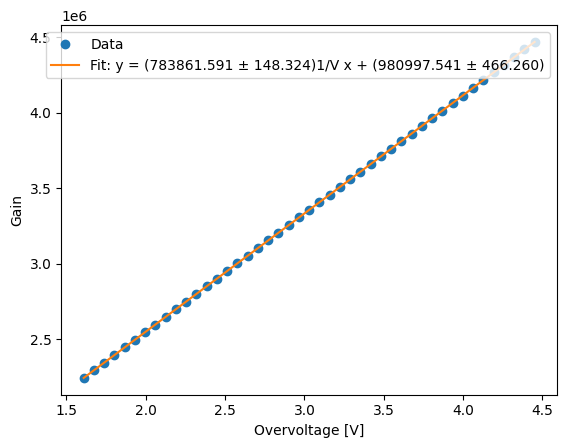

In [ ]:
### Thoughts and the Gain on Temperature dependency of the SiPMs #Breakdownvoltage over Temperature dependency of the SiPMs in https://gitlab.cern.ch/ship/ship-sbt/36th-ship-cm/-/blob/master/DPG2026/DPG_Erlangen_2026_Talk_Tilman_Rock.pdf?ref_type=heads
df = pd.read_csv("../sipms/Gain_overvoltage.csv", sep=",", header=None, names=["overvoltage", "gain"])

overVPerDegree = 33.66e-3 #taken from Tilmans DPG talk in V/K - 0.03V pro grad - 0.12 V pro 4 grad
doverVPerDegree = 0.30e-3 #taken from Tilmans DPG talk in V/K - 0.003V pro grad - 0.012 V pro 4 grad


#Gain(Overvoltage) = (7.83861591 ± 0.00148324)*1e5/V * Overvoltage + (9.80997541 ± 0.00466260)*1e5 -  at 25 degrees C - 0.12 V geringere overvoltage - 12% weniger Gain pro 4 Grad Temperaturerhöhung
#Breakdownvoltage(T) = (39.16+-0.01)V + (33.66e-3+-0.30e-3) V/K * T
#If the Voltage is set to Vset than the 
# Overvoltage is Vset-Breakdownvoltage(T) 
# = (Vset+-0.1)V - (39.16+-0.01)V + (33.66e-3+-0.30e-3) V/K * T 

# Gain over Temperature: 
# Gain(T) = (7.83861591 ± 0.00148324)*1e5/V * ((Vset+-0.1)V - (39.16+-0.01)V + (33.66e-3+-0.30e-3) V/K * T) + (9.80997541 ± 0.00466260)*1e5 

# Gain(T) = 7.83861591e5 * Vset - 7.83861591e5/V*39.16V - 7.83861591e5*33.66e-3/K * T + 9.80997541e5 

# Gain(T) = 7.83861591e5 * Vset - 30696019.903559998 - 26384.78115306/K * T + 9.80997541e5 

# Gain(T) = A * Vset - A * B - A * C * T + D
# A = 7.83861591e5 #
# dA = 0.00148324e5
# B = 39.16
# dB = 0.01
# C = 33.66e-3
# dC = 0.30e-3
# D = 9.80997541e5
# dD = 0.00466260e5
# dT = 0.1
# dVset = 0.1
# dGain(T) = \sqrt((dA * (Vset + B + C*T))^2 + (A * dVset)^2 + (dB*A)^2 + (dC * T*A)^2 + (dT*C*A)+ (dD)^2) 
# SiPM output should proportional to Gain(T) and therefore the SiPM output should decrease with increasing temperature.


x = np.array(df["overvoltage"])
y = np.array(df["gain"])

# Linear fit: y = m*x + b
(p, cov) = np.polyfit(x, y, 1, cov=True)

m, b = p

# Parameter uncertainties
m_err = np.sqrt(cov[0, 0])
b_err = np.sqrt(cov[1, 1])

# Fitted line
y_fit = m * x + b

print(f"Slope:     m = {m/1e5} ± {m_err/1e5} e5 1/V")
print(f"Intercept: b = {b/1e5} ± {b_err/1e5} e5")

# Plot
plt.plot(x, y, 'o', label="Data")
plt.plot(
    x,
    y_fit,
    '-',
    label=f"Fit: y = ({m:.3f} ± {m_err:.3f})1/V x + ({b:.3f} ± {b_err:.3f})"
)

plt.xlabel("Overvoltage [V]")
plt.ylabel("Gain")
plt.legend()
plt.show()

